# Credit Risk Prediction & Model Validation

## Phase 0 — Project Setup

This notebook initializes the project environment, connects Google Drive,
creates the project directory structure, installs required dependencies,
and verifies the Home Credit dataset.

### Project Goal

Build an end-to-end credit risk modeling and model validation pipeline
covering:

- Data quality assessment
- Exploratory data analysis
- Feature engineering
- Class imbalance handling
- Multiple ML models
- Cross-validation
- Model evaluation
- Threshold optimization
- Probability calibration
- SHAP explainability
- Model validation
- Stability analysis

```
# This is formatted as code
```



In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/credit-risk-prediction")

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"
SRC_DIR = PROJECT_DIR / "src"
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"
FIGURES_DIR = PROJECT_DIR / "figures"

print(f"Project directory: {PROJECT_DIR}")

Project directory: /content/drive/MyDrive/credit-risk-prediction


In [ ]:
directories = [
    RAW_DIR,
    PROCESSED_DIR,
    NOTEBOOKS_DIR,
    SRC_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("✅ Project structure created.")

✅ Project structure created.


In [ ]:
for path in sorted(PROJECT_DIR.rglob("*")):
    if path.is_dir():
        print(f"📁 {path.relative_to(PROJECT_DIR)}/")

📁 data/
📁 data/processed/
📁 data/raw/
📁 figures/
📁 models/
📁 notebooks/
📁 reports/
📁 src/


In [ ]:
!pip install -q -U pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import xgboost
import imblearn
import shap

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
print("Python environment")
print("-" * 40)

print(f"Pandas:            {pd.__version__}")
print(f"NumPy:             {np.__version__}")
print(f"Scikit-learn:      {sklearn.__version__}")
print(f"XGBoost:            {xgboost.__version__}")
print(f"Imbalanced-learn:  {imblearn.__version__}")
print(f"SHAP:              {shap.__version__}")

Python environment
----------------------------------------
Pandas:            2.2.3
NumPy:             2.1.3
Scikit-learn:      1.6.1
XGBoost:            3.4.1
Imbalanced-learn:  0.14.2
SHAP:              0.52.0


In [ ]:
expected_files = [
    "HomeCredit_columns_description.csv",
    "POS_CASH_balance.csv",
    "application_test.csv",
    "application_train.csv",
    "bureau.csv",
    "bureau_balance.csv",
    "credit_card_balance.csv",
    "installments_payments.csv",
    "previous_application.csv",
    "sample_submission.csv",
]

print("Dataset verification")
print("=" * 70)

missing_files = []

for filename in expected_files:
    file_path = RAW_DIR / filename

    if file_path.exists():
        size_mb = file_path.stat().st_size / (1024 ** 2)
        print(f"✅ {filename:<40} {size_mb:>10,.2f} MB")
    else:
        print(f"❌ {filename:<40} MISSING")
        missing_files.append(filename)

print("=" * 70)

if not missing_files:
    print("✅ All expected dataset files are present.")
else:
    print(f"⚠️ Missing {len(missing_files)} file(s).")

Dataset verification
✅ HomeCredit_columns_description.csv             0.04 MB
✅ POS_CASH_balance.csv                         374.51 MB
✅ application_test.csv                          25.34 MB
✅ application_train.csv                        158.44 MB
✅ bureau.csv                                   162.14 MB
✅ bureau_balance.csv                           358.19 MB
✅ credit_card_balance.csv                      404.91 MB
✅ installments_payments.csv                    689.62 MB
✅ previous_application.csv                     386.21 MB
✅ sample_submission.csv                          0.51 MB
✅ All expected dataset files are present.


In [ ]:
import shutil

total, used, free = shutil.disk_usage(PROJECT_DIR)

print(f"Total storage: {total / (1024**3):.2f} GB")
print(f"Used storage:  {used / (1024**3):.2f} GB")
print(f"Free storage:  {free / (1024**3):.2f} GB")

Total storage: 15.00 GB
Used storage:  3.14 GB
Free storage:  11.86 GB


In [ ]:
train_path = RAW_DIR / "application_train.csv"

train_sample = pd.read_csv(
    train_path,
    nrows=5
)

print(f"File: {train_path.name}")
print(f"Sample shape: {train_sample.shape}")

display(train_sample.head())

File: application_train.csv
Sample shape: (5, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print("""
============================================================
PHASE 0 — PROJECT SETUP
============================================================

✅ Google Drive connected
✅ Project directories created
✅ Required libraries installed
✅ Dataset files verified
✅ Main training file accessible

STATUS: PHASE 0 COMPLETE
============================================================
""")


PHASE 0 — PROJECT SETUP

✅ Google Drive connected
✅ Project directories created
✅ Required libraries installed
✅ Dataset files verified
✅ Main training file accessible

STATUS: PHASE 0 COMPLETE



In [ ]:
# Credit Risk Prediction & Model Validation

## Phase 1 — Dataset Understanding & Data Quality Audit

### Objective

# Understand the Home Credit dataset before performing any machine learning.

# This phase focuses on:

# - Dataset structure
# - Target variable
# - Data types
# - Missing values
# - Duplicate records
# - Unique values
# - Target distribution
# - Numerical variables
# - Categorical variables
# - Suspicious and invalid values

# No machine learning models will be trained in this phase.

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path("/content/drive/MyDrive/credit-risk-prediction")
RAW_DIR = PROJECT_DIR / "data" / "raw"

TRAIN_PATH = RAW_DIR / "application_train.csv"
TEST_PATH = RAW_DIR / "application_test.csv"

In [ ]:
print("Training file:", TRAIN_PATH)
print("Test file:", TEST_PATH)

print("\nTraining file exists:", TRAIN_PATH.exists())
print("Test file exists:", TEST_PATH.exists())

Training file: /content/drive/MyDrive/credit-risk-prediction/data/raw/application_train.csv
Test file: /content/drive/MyDrive/credit-risk-prediction/data/raw/application_test.csv

Training file exists: True
Test file exists: True


In [ ]:
train_df = pd.read_csv(TRAIN_PATH)

print("Training dataset loaded successfully.")

Training dataset loaded successfully.


In [ ]:
train_df = pd.read_csv(TRAIN_PATH)

print("Training dataset loaded successfully.")

Training dataset loaded successfully.


In [ ]:
train_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
train_df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [ ]:
test_df = pd.read_csv(TEST_PATH)

print(f"Test rows:    {test_df.shape[0]:,}")
print(f"Test columns: {test_df.shape[1]:,}")

Test rows:    48,744
Test columns: 121


In [ ]:
print(
    "Columns only in training:",
    set(train_df.columns) - set(test_df.columns)
)

print(
    "Columns only in test:",
    set(test_df.columns) - set(train_df.columns)
)

Columns only in training: {'TARGET'}
Columns only in test: set()


In [ ]:
train_df["TARGET"].value_counts()

,count
TARGET,
0,282686
1,24825


In [ ]:
target_distribution = (
    train_df["TARGET"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_distribution

,proportion
TARGET,
0,91.93
1,8.07


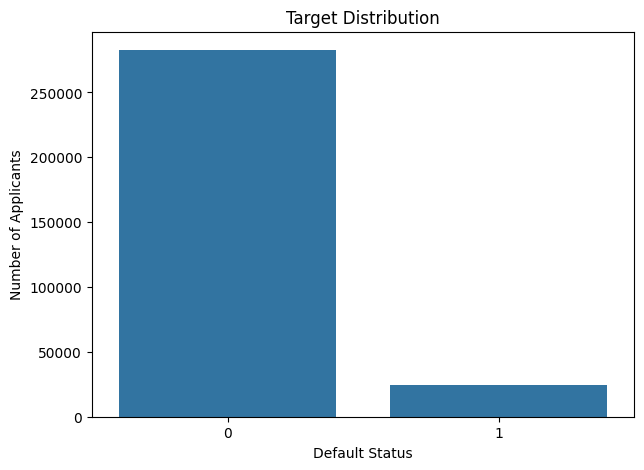

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=train_df,
    x="TARGET"
)

plt.title("Target Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Applicants")

plt.show()

In [ ]:
target_summary = pd.DataFrame({
    "Count": train_df["TARGET"].value_counts(),
    "Percentage": train_df["TARGET"].value_counts(normalize=True) * 100
})

target_summary.index = ["Non-Default (0)", "Default (1)"]

target_summary

,Count,Percentage
Non-Default (0),282686,91.927118
Default (1),24825,8.072882


In [ ]:
dtype_summary = (
    train_df.dtypes
    .value_counts()
    .rename_axis("Data Type")
    .reset_index(name="Count")
)

dtype_summary

,Data Type,Count
0,float64,65
1,int64,41
2,object,16


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [ ]:
numerical_features = train_df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = train_df.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numerical features:   {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numerical features:   106
Categorical features: 16


In [ ]:
numerical_features.remove("TARGET")

In [ ]:
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MO

In [ ]:
missing_summary = pd.DataFrame({
    "Missing_Count": train_df.isnull().sum(),
    "Missing_Percentage": train_df.isnull().mean() * 100
})

missing_summary = (
    missing_summary
    .sort_values("Missing_Percentage", ascending=False)
)

missing_summary.head(20)

,Missing_Count,Missing_Percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [ ]:
columns_with_missing = (
    missing_summary["Missing_Count"] > 0
).sum()

print(
    f"Columns containing missing values: "
    f"{columns_with_missing} / {train_df.shape[1]}"
)

Columns containing missing values: 67 / 122


In [ ]:
print(
    f"Columns without missing values: "
    f"{(missing_summary['Missing_Count'] == 0).sum()}"
)

Columns without missing values: 55


In [ ]:
def missing_severity(pct):
    if pct == 0:
        return "None"
    elif pct < 5:
        return "Low"
    elif pct < 20:
        return "Moderate"
    elif pct < 50:
        return "High"
    else:
        return "Very High"


missing_summary["Severity"] = (
    missing_summary["Missing_Percentage"]
    .apply(missing_severity)
)

missing_summary.head(20)

,Missing_Count,Missing_Percentage,Severity
COMMONAREA_AVG,214865,69.872297,Very High
COMMONAREA_MODE,214865,69.872297,Very High
COMMONAREA_MEDI,214865,69.872297,Very High
NONLIVINGAPARTMENTS_MEDI,213514,69.432963,Very High
NONLIVINGAPARTMENTS_MODE,213514,69.432963,Very High
NONLIVINGAPARTMENTS_AVG,213514,69.432963,Very High
FONDKAPREMONT_MODE,210295,68.386172,Very High
LIVINGAPARTMENTS_AVG,210199,68.354953,Very High
LIVINGAPARTMENTS_MEDI,210199,68.354953,Very High
LIVINGAPARTMENTS_MODE,210199,68.354953,Very High


In [ ]:
duplicate_count = train_df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


In [ ]:
duplicate_percentage = (
    duplicate_count / len(train_df) * 100
)

print(f"Duplicate percentage: {duplicate_percentage:.4f}%")

Duplicate percentage: 0.0000%


In [ ]:
print(
    "Unique SK_ID_CURR:",
    train_df["SK_ID_CURR"].nunique()
)

print(
    "Total rows:",
    len(train_df)
)

Unique SK_ID_CURR: 307511
Total rows: 307511


In [ ]:
unique_summary = pd.DataFrame({
    "Unique_Values": train_df.nunique(),
    "Data_Type": train_df.dtypes.astype(str)
})

unique_summary = (
    unique_summary
    .sort_values("Unique_Values")
)

unique_summary.head(30)

,Unique_Values,Data_Type
TARGET,2,int64
NAME_CONTRACT_TYPE,2,object
FLAG_OWN_REALTY,2,object
FLAG_OWN_CAR,2,object
FLAG_WORK_PHONE,2,int64
FLAG_CONT_MOBILE,2,int64
FLAG_EMP_PHONE,2,int64
FLAG_MOBIL,2,int64
FLAG_PHONE,2,int64
FLAG_EMAIL,2,int64


In [ ]:
numerical_summary = train_df[numerical_features].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [ ]:
categorical_summary = train_df[categorical_features].describe().T

categorical_summary

,count,unique,top,freq
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232
CODE_GENDER,307511,3,F,202448
FLAG_OWN_CAR,307511,2,N,202924
FLAG_OWN_REALTY,307511,2,Y,213312
NAME_TYPE_SUITE,306219,7,Unaccompanied,248526
NAME_INCOME_TYPE,307511,8,Working,158774
NAME_EDUCATION_TYPE,307511,5,Secondary / secondary special,218391
NAME_FAMILY_STATUS,307511,6,Married,196432
NAME_HOUSING_TYPE,307511,6,House / apartment,272868
OCCUPATION_TYPE,211120,18,Laborers,55186


In [ ]:
binary_features = [
    col
    for col in train_df.columns
    if col != "TARGET"
    and train_df[col].nunique(dropna=True) == 2
]

print(f"Binary predictor features: {len(binary_features)}")
print(binary_features)

Binary predictor features: 36
['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EMERGENCYSTATE_MODE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']


In [ ]:
negative_counts = (
    (train_df[numerical_features] < 0)
    .sum()
    .sort_values(ascending=False)
)

negative_counts[negative_counts > 0].head(30)

,0
DAYS_BIRTH,307511
DAYS_ID_PUBLISH,307495
DAYS_REGISTRATION,307431
DAYS_LAST_PHONE_CHANGE,269838
DAYS_EMPLOYED,252135


In [ ]:
DESCRIPTION_PATH = RAW_DIR / "HomeCredit_columns_description.csv"

description_df = pd.read_csv(
    DESCRIPTION_PATH,
    encoding="latin1"
)

description_df.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [ ]:
description_df.shape

(219, 5)

In [ ]:
description_df.columns

Index(['Unnamed: 0', 'Table', 'Row', 'Description', 'Special'], dtype='object')

In [ ]:
description_df.head(20)

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


In [ ]:
historical_files = {
    "bureau": "bureau.csv",
    "bureau_balance": "bureau_balance.csv",
    "previous_application": "previous_application.csv",
    "POS_CASH_balance": "POS_CASH_balance.csv",
    "credit_card_balance": "credit_card_balance.csv",
    "installments_payments": "installments_payments.csv"
}

In [ ]:
historical_samples = {}

for name, filename in historical_files.items():

    file_path = RAW_DIR / filename

    sample = pd.read_csv(
        file_path,
        nrows=5
    )

    historical_samples[name] = sample

    print(f"\n{name}")
    print("-" * 60)
    print(f"Columns: {sample.shape[1]}")
    print(sample.columns.tolist())


bureau
------------------------------------------------------------
Columns: 17
['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']

bureau_balance
------------------------------------------------------------
Columns: 3
['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']

previous_application
------------------------------------------------------------
Columns: 37
['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 

In [ ]:
def count_csv_rows(file_path):
    with open(file_path, "rb") as f:
        return sum(1 for _ in f) - 1


historical_sizes = []

for name, filename in historical_files.items():

    file_path = RAW_DIR / filename

    rows = count_csv_rows(file_path)

    historical_sizes.append({
        "Dataset": name,
        "Rows": rows,
        "Columns": len(historical_samples[name].columns)
    })

historical_size_df = pd.DataFrame(historical_sizes)

historical_size_df

,Dataset,Rows,Columns
0,bureau,1716428,17
1,bureau_balance,27299925,3
2,previous_application,1670214,37
3,POS_CASH_balance,10001358,8
4,credit_card_balance,3840312,23
5,installments_payments,13605401,8


In [ ]:
data_quality_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Numerical Features",
        "Categorical Features",
        "Binary Features",
        "Columns With Missing Values",
        "Duplicate Rows",
        "Unique Applicants"
    ],
    "Value": [
        len(train_df),
        train_df.shape[1],
        len(numerical_features),
        len(categorical_features),
        len(binary_features),
        columns_with_missing,
        duplicate_count,
        train_df["SK_ID_CURR"].nunique()
    ]
})

data_quality_summary

,Metric,Value
0,Rows,307511
1,Columns,122
2,Numerical Features,105
3,Categorical Features,16
4,Binary Features,36
5,Columns With Missing Values,67
6,Duplicate Rows,0
7,Unique Applicants,307511


In [ ]:
data_quality_summary.to_csv(
    PROCESSED_DIR / "data_quality_summary.csv",
    index=False
)

missing_summary.to_csv(
    PROCESSED_DIR / "missing_value_summary.csv"
)

numerical_summary.to_csv(
    PROCESSED_DIR / "numerical_summary.csv"
)

categorical_summary.to_csv(
    PROCESSED_DIR / "categorical_summary.csv"
)

historical_size_df.to_csv(
    PROCESSED_DIR / "historical_dataset_summary.csv",
    index=False
)

print("✅ Phase 1 audit summaries saved.")

✅ Phase 1 audit summaries saved.


In [ ]:
target_counts = train_df["TARGET"].value_counts().sort_index()

target_percentages = (
    train_df["TARGET"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary.index = [
    "Non-default (0)",
    "Default (1)"
]

target_summary

,Count,Percentage
Non-default (0),282686,91.93
Default (1),24825,8.07


In [ ]:
missing_summary.head(30)

,Missing_Count,Missing_Percentage,Severity
COMMONAREA_AVG,214865,69.872297,Very High
COMMONAREA_MODE,214865,69.872297,Very High
COMMONAREA_MEDI,214865,69.872297,Very High
NONLIVINGAPARTMENTS_MEDI,213514,69.432963,Very High
NONLIVINGAPARTMENTS_MODE,213514,69.432963,Very High
NONLIVINGAPARTMENTS_AVG,213514,69.432963,Very High
FONDKAPREMONT_MODE,210295,68.386172,Very High
LIVINGAPARTMENTS_AVG,210199,68.354953,Very High
LIVINGAPARTMENTS_MEDI,210199,68.354953,Very High
LIVINGAPARTMENTS_MODE,210199,68.354953,Very High


In [ ]:
missing_summary[missing_summary["Missing_Count"] > 0].shape

(67, 3)

In [ ]:
missing_summary[
    missing_summary["Missing_Count"] > 0
].head(20)

,Missing_Count,Missing_Percentage,Severity
COMMONAREA_AVG,214865,69.872297,Very High
COMMONAREA_MODE,214865,69.872297,Very High
COMMONAREA_MEDI,214865,69.872297,Very High
NONLIVINGAPARTMENTS_MEDI,213514,69.432963,Very High
NONLIVINGAPARTMENTS_MODE,213514,69.432963,Very High
NONLIVINGAPARTMENTS_AVG,213514,69.432963,Very High
FONDKAPREMONT_MODE,210295,68.386172,Very High
LIVINGAPARTMENTS_AVG,210199,68.354953,Very High
LIVINGAPARTMENTS_MEDI,210199,68.354953,Very High
LIVINGAPARTMENTS_MODE,210199,68.354953,Very High


In [ ]:
missing_by_type = pd.DataFrame({
    "Missing_Count": train_df.isnull().sum(),
    "Missing_Percentage": train_df.isnull().mean() * 100,
    "Data_Type": train_df.dtypes.astype(str)
})

missing_by_type = missing_by_type[
    missing_by_type["Missing_Count"] > 0
].sort_values(
    "Missing_Percentage",
    ascending=False
)

missing_by_type

,Missing_Count,Missing_Percentage,Data_Type
COMMONAREA_MEDI,214865,69.872297,float64
COMMONAREA_MODE,214865,69.872297,float64
COMMONAREA_AVG,214865,69.872297,float64
NONLIVINGAPARTMENTS_MODE,213514,69.432963,float64
NONLIVINGAPARTMENTS_MEDI,213514,69.432963,float64
...,...,...,...
EXT_SOURCE_2,660,0.214626,float64
AMT_GOODS_PRICE,278,0.090403,float64
AMT_ANNUITY,12,0.003902,float64
CNT_FAM_MEMBERS,2,0.000650,float64


In [ ]:
print("Missing numerical columns:")
display(
    missing_by_type[
        missing_by_type["Data_Type"] != "object"
    ].head(20)
)

Missing numerical columns:


,Missing_Count,Missing_Percentage,Data_Type
COMMONAREA_MEDI,214865,69.872297,float64
COMMONAREA_MODE,214865,69.872297,float64
COMMONAREA_AVG,214865,69.872297,float64
NONLIVINGAPARTMENTS_MODE,213514,69.432963,float64
NONLIVINGAPARTMENTS_MEDI,213514,69.432963,float64
NONLIVINGAPARTMENTS_AVG,213514,69.432963,float64
LIVINGAPARTMENTS_AVG,210199,68.354953,float64
LIVINGAPARTMENTS_MEDI,210199,68.354953,float64
LIVINGAPARTMENTS_MODE,210199,68.354953,float64
FLOORSMIN_MEDI,208642,67.848630,float64


In [ ]:
print("Missing categorical columns:")
display(
    missing_by_type[
        missing_by_type["Data_Type"] == "object"
    ]
)

Missing categorical columns:


,Missing_Count,Missing_Percentage,Data_Type
FONDKAPREMONT_MODE,210295,68.386172,object
WALLSMATERIAL_MODE,156341,50.840783,object
HOUSETYPE_MODE,154297,50.176091,object
EMERGENCYSTATE_MODE,145755,47.398304,object
OCCUPATION_TYPE,96391,31.345545,object
NAME_TYPE_SUITE,1292,0.420148,object


In [ ]:
important_numeric = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN"
]

percentiles = train_df[important_numeric].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]
)

percentiles

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_CHILDREN
0.010,45000.0,76410.0,6182.91,67500.0,0.0
0.050,67500.0,135000.0,9000.00,135000.0,0.0
0.250,112500.0,270000.0,16524.00,238500.0,0.0
0.500,147150.0,513531.0,24903.00,450000.0,0.0
0.750,202500.0,808650.0,34596.00,679500.0,1.0
0.950,337500.0,1350000.0,53325.00,1305000.0,2.0
0.990,472500.0,1854000.0,70006.50,1800000.0,3.0
0.999,900000.0,2517300.0,110047.50,2250000.0,4.0


In [ ]:
for col in important_numeric:
    print(f"\n{'=' * 70}")
    print(col)
    print(train_df[col].describe())


AMT_INCOME_TOTAL
count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

AMT_CREDIT
count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

AMT_ANNUITY
count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

AMT_GOODS_PRICE
count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

CNT_CHILDREN
count    307511.000000
mean          0.417052
std           0.722121
m

In [ ]:
days_columns = [
    col for col in train_df.columns
    if col.startswith("DAYS_")
]

train_df[days_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
DAYS_REGISTRATION,307511.0,-4986.120328,3522.886321,-24672.0,-7479.5,-4504.0,-2010.0,0.0
DAYS_ID_PUBLISH,307511.0,-2994.202373,1509.450419,-7197.0,-4299.0,-3254.0,-1720.0,0.0
DAYS_LAST_PHONE_CHANGE,307510.0,-962.858788,826.808487,-4292.0,-1570.0,-757.0,-274.0,0.0


In [ ]:
train_df[days_columns].head()

,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,DAYS_LAST_PHONE_CHANGE
0,-9461,-637,-3648.0,-2120,-1134.0
1,-16765,-1188,-1186.0,-291,-828.0
2,-19046,-225,-4260.0,-2531,-815.0
3,-19005,-3039,-9833.0,-2437,-617.0
4,-19932,-3038,-4311.0,-3458,-1106.0


In [ ]:
# Investigate suspicious/extreme values

print("DAYS_EMPLOYED > 0:")
print((train_df["DAYS_EMPLOYED"] > 0).sum())

print("\nDAYS_EMPLOYED == 365243:")
print((train_df["DAYS_EMPLOYED"] == 365243).sum())

print("\nCNT_CHILDREN >= 10:")
print((train_df["CNT_CHILDREN"] >= 10).sum())

print("\nAMT_INCOME_TOTAL > 1,000,000:")
print((train_df["AMT_INCOME_TOTAL"] > 1_000_000).sum())

print("\nAMT_INCOME_TOTAL > 10,000,000:")
print((train_df["AMT_INCOME_TOTAL"] > 10_000_000).sum())

DAYS_EMPLOYED > 0:
55374

DAYS_EMPLOYED == 365243:
55374

CNT_CHILDREN >= 10:
10

AMT_INCOME_TOTAL > 1,000,000:
250

AMT_INCOME_TOTAL > 10,000,000:
3


In [ ]:
categorical_columns = train_df.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    print(f"\n{'=' * 60}")
    print(col)
    print(train_df[col].value_counts(dropna=False).head(15))


NAME_CONTRACT_TYPE
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

CODE_GENDER
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

FLAG_OWN_CAR
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

FLAG_OWN_REALTY
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

NAME_TYPE_SUITE
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
NaN                  1292
Other_A               866
Group of people       271
Name: count, dtype: int64

NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / s

In [ ]:
# ============================================
# PHASE 2 — EDA
# 01_data_exploration.ipynb
# ============================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = "/content/drive/MyDrive/credit-risk-prediction"
RAW_DIR = os.path.join(PROJECT_DIR, "data", "raw")

TRAIN_PATH = os.path.join(RAW_DIR, "application_train.csv")
TEST_PATH = os.path.join(RAW_DIR, "application_test.csv")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

Training shape: (307511, 122)
Test shape: (48744, 121)


In [ ]:
# ============================================
# 1. TARGET DISTRIBUTION
# ============================================

target_counts = train_df["TARGET"].value_counts().sort_index()

target_percentages = (
    train_df["TARGET"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_summary.index = [
    "Non-default (0)",
    "Default (1)"
]

display(target_summary)

,Count,Percentage
Non-default (0),282686,91.927118
Default (1),24825,8.072882


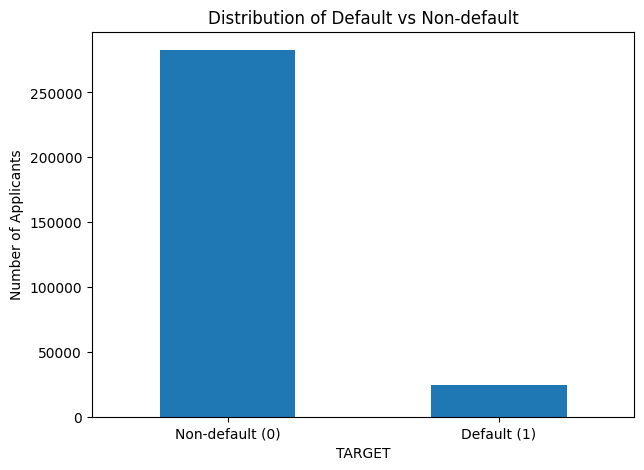

In [ ]:
plt.figure(figsize=(7, 5))

target_counts.plot(
    kind="bar"
)

plt.title("Distribution of Default vs Non-default")
plt.xlabel("TARGET")
plt.ylabel("Number of Applicants")
plt.xticks(
    [0, 1],
    ["Non-default (0)", "Default (1)"],
    rotation=0
)

plt.show()

In [ ]:
default_rate = train_df["TARGET"].mean()

print(f"Overall default rate: {default_rate:.2%}")

Overall default rate: 8.07%


In [ ]:
train_df["AGE_YEARS"] = (
    -train_df["DAYS_BIRTH"] / 365.25
)

In [ ]:
train_df["AGE_YEARS"].describe()

,AGE_YEARS
count,307511.000000
mean,43.906900
std,11.947950
min,20.503765
25%,33.984942
50%,43.121150
75%,53.886379
max,69.073238


In [ ]:
train_df["AGE_GROUP"] = pd.cut(
    train_df["AGE_YEARS"],
    bins=[18, 25, 30, 35, 40, 50, 60, 100],
    labels=[
        "18-25",
        "26-30",
        "31-35",
        "36-40",
        "41-50",
        "51-60",
        "61+"
    ],
    include_lowest=True
)

In [ ]:
age_risk = (
    train_df
    .groupby("AGE_GROUP", observed=False)["TARGET"]
    .agg(
        applicants="count",
        defaults="sum",
        default_rate="mean"
    )
)

age_risk["default_rate"] *= 100

age_risk

,applicants,defaults,default_rate
AGE_GROUP,,,
18-25,12233,1504,12.294613
26-30,32953,3667,11.127970
31-35,39476,4054,10.269531
36-40,42873,3843,8.963683
41-50,76581,5853,7.642888
51-60,68109,4168,6.119602
61+,35286,1736,4.919798


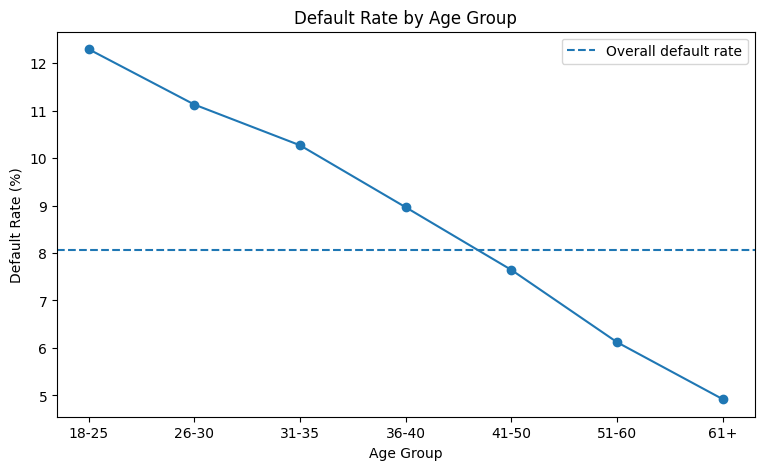

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    age_risk.index.astype(str),
    age_risk["default_rate"],
    marker="o"
)

plt.axhline(
    default_rate * 100,
    linestyle="--",
    label="Overall default rate"
)

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")
plt.legend()

plt.show()

In [ ]:
# ============================================
# 3. INCOME VS DEFAULT
# ============================================

income_bins = [
    0,
    100000,
    150000,
    200000,
    300000,
    500000,
    float("inf")
]

income_labels = [
    "<100K",
    "100K-150K",
    "150K-200K",
    "200K-300K",
    "300K-500K",
    "500K+"
]

train_df["INCOME_GROUP"] = pd.cut(
    train_df["AMT_INCOME_TOTAL"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

In [ ]:
income_risk = (
    train_df
    .groupby("INCOME_GROUP", observed=False)["TARGET"]
    .agg(
        applicants="count",
        defaults="sum",
        default_rate="mean"
    )
)

income_risk["default_rate"] *= 100

display(income_risk)

,applicants,defaults,default_rate
INCOME_GROUP,,,
<100K,63698,5225,8.202769
100K-150K,91591,7894,8.618751
150K-200K,64307,5432,8.446981
200K-300K,65176,4921,7.550325
300K-500K,20037,1207,6.023856
500K+,2702,146,5.403405


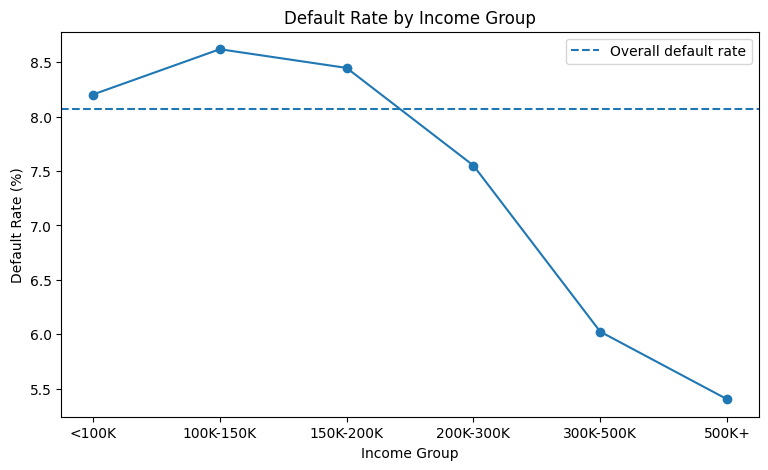

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    income_risk.index.astype(str),
    income_risk["default_rate"],
    marker="o"
)

plt.axhline(
    default_rate * 100,
    linestyle="--",
    label="Overall default rate"
)

plt.title("Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate (%)")
plt.legend()

plt.show()

In [ ]:
# ============================================
# 4. CREDIT AMOUNT VS DEFAULT
# ============================================

credit_bins = [
    0,
    200000,
    400000,
    600000,
    1000000,
    1500000,
    2500000,
    float("inf")
]

credit_labels = [
    "<200K",
    "200K-400K",
    "400K-600K",
    "600K-1M",
    "1M-1.5M",
    "1.5M-2.5M",
    "2.5M+"
]

train_df["CREDIT_GROUP"] = pd.cut(
    train_df["AMT_CREDIT"],
    bins=credit_bins,
    labels=credit_labels,
    include_lowest=True
)

In [ ]:
credit_risk = (
    train_df
    .groupby("CREDIT_GROUP", observed=False)["TARGET"]
    .agg(
        applicants="count",
        defaults="sum",
        default_rate="mean"
    )
)

credit_risk["default_rate"] *= 100

display(credit_risk)

,applicants,defaults,default_rate
CREDIT_GROUP,,,
<200K,36144,2490,6.889110
200K-400K,81151,6944,8.556888
400K-600K,66270,6694,10.101102
600K-1M,73961,5765,7.794649
1M-1.5M,39229,2456,6.260675
1.5M-2.5M,10395,462,4.444444
2.5M+,361,14,3.878116


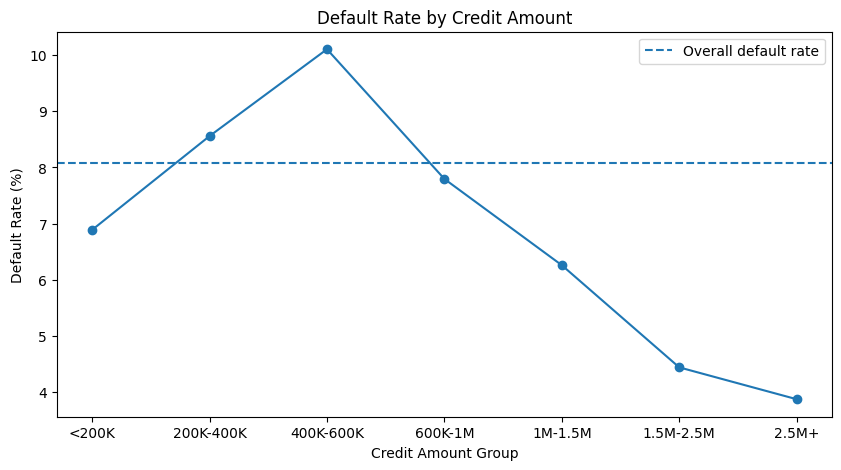

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    credit_risk.index.astype(str),
    credit_risk["default_rate"],
    marker="o"
)

plt.axhline(
    default_rate * 100,
    linestyle="--",
    label="Overall default rate"
)

plt.title("Default Rate by Credit Amount")
plt.xlabel("Credit Amount Group")
plt.ylabel("Default Rate (%)")
plt.legend()

plt.show()

In [ ]:
# ============================================
# 5. EXTERNAL CREDIT SCORES
# ============================================

ext_sources = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

train_df[ext_sources].describe()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,134133.000000,3.068510e+05,246546.000000
mean,0.502130,5.143927e-01,0.510853
std,0.211062,1.910602e-01,0.194844
min,0.014568,8.173617e-08,0.000527
25%,0.334007,3.924574e-01,0.370650
50%,0.505998,5.659614e-01,0.535276
75%,0.675053,6.636171e-01,0.669057
max,0.962693,8.549997e-01,0.896010


In [ ]:
ext_missing = (
    train_df[ext_sources]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(ext_missing)

,0
EXT_SOURCE_1,56.381073
EXT_SOURCE_3,19.825307
EXT_SOURCE_2,0.214626


In [ ]:
for col in ext_sources:

    train_df[f"{col}_DECILE"] = pd.qcut(
        train_df[col],
        q=10,
        labels=False,
        duplicates="drop"
    ) + 1

In [ ]:
ext_risk = {}

for col in ext_sources:

    result = (
        train_df
        .groupby(f"{col}_DECILE", observed=True)["TARGET"]
        .agg(
            applicants="count",
            defaults="sum",
            default_rate="mean"
        )
    )

    result["default_rate"] *= 100

    ext_risk[col] = result

    print("=" * 60)
    print(col)
    display(result)

EXT_SOURCE_1


,applicants,defaults,default_rate
EXT_SOURCE_1_DECILE,,,
1.0,13414,2356,17.563739
2.0,13413,1555,11.593230
3.0,13414,1220,9.094975
4.0,13412,1124,8.380555
5.0,13415,898,6.693999
6.0,13412,808,6.024456
7.0,13413,689,5.136808
8.0,13413,588,4.383807
9.0,13413,471,3.511519


EXT_SOURCE_2


,applicants,defaults,default_rate
EXT_SOURCE_2_DECILE,,,
1.0,30686,5631,18.350388
2.0,30685,3706,12.077562
3.0,30687,3056,9.958614
4.0,30684,2566,8.362665
5.0,30684,2278,7.424065
6.0,30687,2042,6.654284
7.0,30683,1794,5.846886
8.0,30694,1499,4.883691
9.0,30676,1289,4.201982


EXT_SOURCE_3


,applicants,defaults,default_rate
EXT_SOURCE_3_DECILE,,,
1.0,24701,4941,20.003239
2.0,24744,3156,12.754607
3.0,25057,2383,9.510316
4.0,24689,1970,7.979262
5.0,24186,1494,6.177127
6.0,25392,1357,5.344203
7.0,24725,1173,4.744186
8.0,24745,1043,4.214993
9.0,23675,836,3.531151


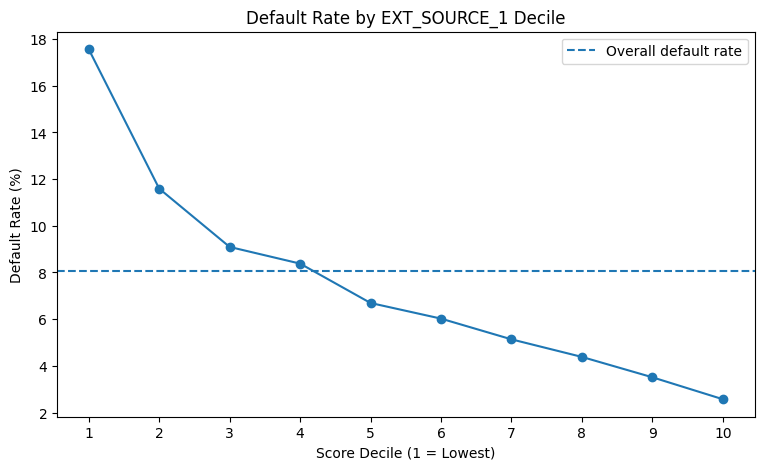

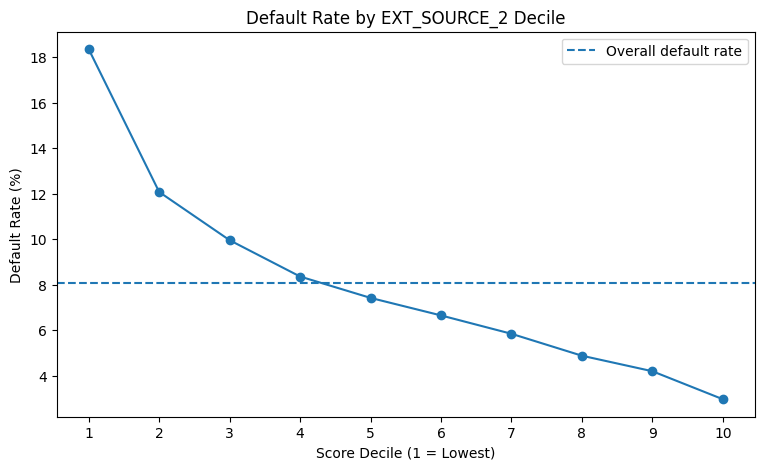

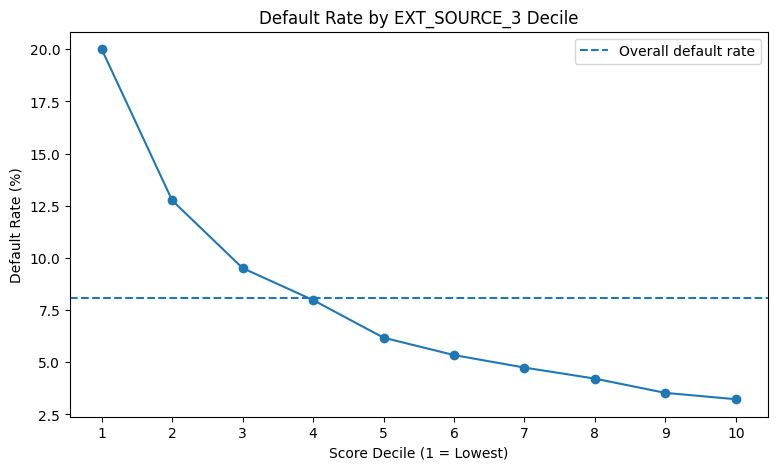

In [ ]:
for col in ext_sources:

    result = ext_risk[col]

    plt.figure(figsize=(9, 5))

    plt.plot(
        result.index,
        result["default_rate"],
        marker="o"
    )

    plt.axhline(
        default_rate * 100,
        linestyle="--",
        label="Overall default rate"
    )

    plt.title(f"Default Rate by {col} Decile")
    plt.xlabel("Score Decile (1 = Lowest)")
    plt.ylabel("Default Rate (%)")
    plt.xticks(range(1, 11))
    plt.legend()

    plt.show()

In [ ]:
income_type_risk = (
    train_df.groupby('NAME_INCOME_TYPE')['TARGET']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'applicants',
        'sum': 'defaults',
        'mean': 'default_rate'
    })
    .sort_values('default_rate', ascending=False)
)

income_type_risk['default_rate'] *= 100

income_type_risk

,applicants,defaults,default_rate
NAME_INCOME_TYPE,,,
Maternity leave,5,2,40.000000
Unemployed,22,8,36.363636
Working,158774,15224,9.588472
Commercial associate,71617,5360,7.484257
State servant,21703,1249,5.754965
Pensioner,55362,2982,5.386366
Businessman,10,0,0.000000
Student,18,0,0.000000


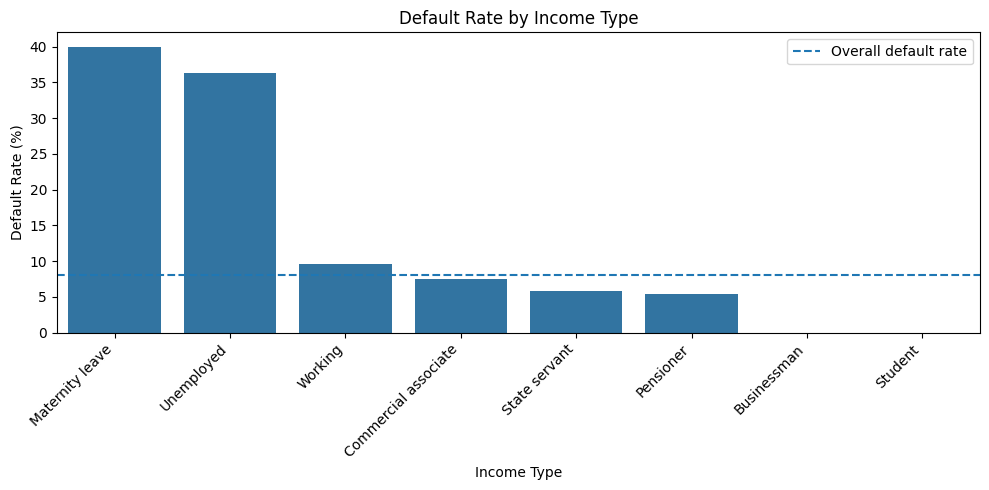

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=income_type_risk.reset_index(),
    x='NAME_INCOME_TYPE',
    y='default_rate'
)

plt.axhline(
    train_df['TARGET'].mean() * 100,
    linestyle='--',
    label='Overall default rate'
)

plt.title('Default Rate by Income Type')
plt.xlabel('Income Type')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# DAYS_EMPLOYED — SENTINEL VALUE ANALYSIS
# ============================================

sentinel_count = train_df["DAYS_EMPLOYED"].eq(365243).sum()
sentinel_percentage = (
    train_df["DAYS_EMPLOYED"].eq(365243).mean() * 100
)

print(f"Sentinel value count: {sentinel_count:,}")
print(f"Sentinel value percentage: {sentinel_percentage:.2f}%")

Sentinel value count: 55,374
Sentinel value percentage: 18.01%


In [ ]:
employment_status = np.where(
    train_df["DAYS_EMPLOYED"] == 365243,
    "Unknown / Sentinel",
    "Recorded"
)

employment_status_risk = (
    train_df.assign(
        EMPLOYMENT_STATUS=employment_status
    )
    .groupby("EMPLOYMENT_STATUS")["TARGET"]
    .agg(
        applicants="count",
        defaults="sum",
        default_rate="mean"
    )
)

employment_status_risk["default_rate"] *= 100

display(employment_status_risk)

,applicants,defaults,default_rate
EMPLOYMENT_STATUS,,,
Recorded,252137,21835,8.659975
Unknown / Sentinel,55374,2990,5.399646


In [ ]:
train_df["EMPLOYMENT_YEARS"] = np.where(
    train_df["DAYS_EMPLOYED"] == 365243,
    np.nan,
    -train_df["DAYS_EMPLOYED"] / 365.25
)

employment_groups = pd.cut(
    train_df["EMPLOYMENT_YEARS"],
    bins=[-np.inf, 1, 3, 5, 10, 20, np.inf],
    labels=["<1 year", "1–3 years", "3–5 years", "5–10 years", "10–20 years", "20+ years"]
)

employment_risk = (
    train_df.assign(EMPLOYMENT_GROUP=employment_groups)
    .groupby("EMPLOYMENT_GROUP", observed=False)["TARGET"]
    .agg(
        applicants="count",
        defaults="sum",
        default_rate="mean"
    )
)

employment_risk["default_rate"] *= 100

display(employment_risk)

,applicants,defaults,default_rate
EMPLOYMENT_GROUP,,,
<1 year,27982,3070,10.971339
1–3 years,61472,6807,11.073334
3–5 years,46902,4536,9.671229
5–10 years,64871,4782,7.371553
10–20 years,38381,2116,5.513145
20+ years,12529,524,4.182297


In [ ]:
organization_risk = (
    train_df.groupby("ORGANIZATION_TYPE")["TARGET"]
    .agg(
        applicants="count",
        defaults="sum",
        default_rate="mean"
    )
)

organization_risk["default_rate"] *= 100

# Keep categories with at least 1,000 applicants
organization_risk_filtered = (
    organization_risk[
        organization_risk["applicants"] >= 1000
    ]
    .sort_values("default_rate", ascending=False)
)

display(organization_risk_filtered)

,applicants,defaults,default_rate
ORGANIZATION_TYPE,,,
Transport: type 3,1187,187,15.754002
Restaurant,1811,212,11.706240
Construction,6721,785,11.679810
Industry: type 1,1039,115,11.068335
Industry: type 3,3278,348,10.616229
Agriculture,2454,257,10.472698
Trade: type 3,3492,361,10.337915
Self-employed,38412,3908,10.173904
Security,3247,324,9.978442


In [ ]:
train_df["CREDIT_TO_INCOME"] = (
    train_df["AMT_CREDIT"] / train_df["AMT_INCOME_TOTAL"]
)

train_df["ANNUITY_TO_INCOME"] = (
    train_df["AMT_ANNUITY"] / train_df["AMT_INCOME_TOTAL"]
)

print("CREDIT_TO_INCOME summary:")
display(train_df["CREDIT_TO_INCOME"].describe())

print("\nANNUITY_TO_INCOME summary:")
display(train_df["ANNUITY_TO_INCOME"].describe())

CREDIT_TO_INCOME summary:


,CREDIT_TO_INCOME
count,307511.000000
mean,3.957570
std,2.689728
min,0.004808
25%,2.018667
50%,3.265067
75%,5.159880
max,84.736842



ANNUITY_TO_INCOME summary:


,ANNUITY_TO_INCOME
count,307499.000000
mean,0.180930
std,0.094574
min,0.000224
25%,0.114782
50%,0.162833
75%,0.229067
max,1.875965


In [ ]:
credit_income_groups = pd.cut(
    train_df["CREDIT_TO_INCOME"],
    bins=[-np.inf, 2, 3, 4, 5, 7, 10, np.inf],
    labels=[
        "<2x",
        "2–3x",
        "3–4x",
        "4–5x",
        "5–7x",
        "7–10x",
        "10x+"
    ]
)

credit_income_risk = (
    train_df.assign(CREDIT_INCOME_GROUP=credit_income_groups)
    .groupby("CREDIT_INCOME_GROUP", observed=False)["TARGET"]
    .agg(
        applicants="count",
        defaults="sum",
        default_rate="mean"
    )
)

credit_income_risk["default_rate"] *= 100

display(credit_income_risk)

,applicants,defaults,default_rate
CREDIT_INCOME_GROUP,,,
<2x,76338,5671,7.428803
2–3x,64858,5636,8.689753
3–4x,48703,4437,9.110322
4–5x,36805,3118,8.471675
5–7x,43785,3330,7.605344
7–10x,27178,1960,7.211715
10x+,9844,673,6.836652


In [ ]:
annuity_income_groups = pd.cut(
    train_df["ANNUITY_TO_INCOME"],
    bins=[-np.inf, 0.10, 0.15, 0.20, 0.25, 0.35, 0.50, np.inf],
    labels=[
        "<10%",
        "10–15%",
        "15–20%",
        "20–25%",
        "25–35%",
        "35–50%",
        "50%+"
    ]
)

annuity_income_risk = (
    train_df.assign(ANNUITY_INCOME_GROUP=annuity_income_groups)
    .groupby("ANNUITY_INCOME_GROUP", observed=False)["TARGET"]
    .agg(
        applicants="count",
        defaults="sum",
        default_rate="mean"
    )
)

annuity_income_risk["default_rate"] *= 100

display(annuity_income_risk)

,applicants,defaults,default_rate
ANNUITY_INCOME_GROUP,,,
<10%,57210,4105,7.175319
10–15%,78018,6027,7.725140
15–20%,67213,5674,8.441819
20–25%,45919,3972,8.650014
25–35%,42632,3717,8.718803
35–50%,13977,1139,8.149102
50%+,2530,191,7.549407


## 6. EDA Observations & Initial Risk Hypotheses

### Key Observations

1. **Target imbalance**
   - The default rate is approximately 8.07%.
   - The dataset is significantly imbalanced.
   - Accuracy alone would therefore be insufficient for evaluating model performance.

2. **Age and default risk**
   - Younger applicants show higher observed default rates.
   - Default rates decrease progressively across older age groups.

3. **Income and default risk**
   - Higher-income groups generally show lower observed default rates,
     particularly above approximately 200K.
   - The relationship is not perfectly linear.

4. **Employment duration**
   - Applicants with shorter recorded employment durations have higher
     observed default rates.
   - Default rates decline substantially among applicants with longer
     employment histories.

5. **External credit scores**
   - Lower external credit scores are strongly associated with higher
     observed default rates.
   - This is one of the strongest and most consistent relationships observed.

6. **Credit amount**
   - Absolute credit amount has a non-linear relationship with default risk.
   - Risk is highest around the 400K–600K range and decreases at higher
     credit amounts.

7. **Credit-to-income ratio**
   - The relationship with default risk is non-monotonic.
   - Default rates increase up to approximately the 3–4x range and then decline.

8. **Annuity-to-income ratio**
   - Default rates increase up to approximately the 25–35% range and then
     decline at higher ratios.
   - This suggests a potentially non-linear relationship.

9. **Organization type**
   - Default rates vary considerably across organization types.
   - Differences may reflect other applicant characteristics rather than
     organization type itself.

10. **Sentinel employment values**
    - DAYS_EMPLOYED = 365243 occurs for 55,374 applicants (18.01%).
    - These applicants have an observed default rate of 5.40%, compared with
      8.66% for applicants with recorded employment duration.
    - ORGANIZATION_TYPE = XNA occurs for exactly the same 55,374 applicants.
    - This requires further investigation during the data-quality phase.

### Initial Risk Hypotheses

- External credit scores may be strong predictors of default risk.
- Employment stability may contain useful predictive information.
- Relative financial burden may be more informative than absolute loan size.
- Several financial relationships appear non-linear and may require flexible
  modeling approaches.
- Missing and sentinel values may contain information about applicant
  characteristics and should be investigated carefully.

In [ ]:
# Phase 3.1 — Load original training data

import pandas as pd
import numpy as np

RAW_PATH = "/content/drive/MyDrive/credit-risk-prediction/data/raw/application_train.csv"

train_raw = pd.read_csv(RAW_PATH)

print("Shape:", train_raw.shape)
print("Number of columns:", len(train_raw.columns))

Shape: (307511, 122)
Number of columns: 122


In [ ]:
# Missing value assessment

missing_summary = pd.DataFrame({
    "missing_count": train_raw.isnull().sum(),
    "missing_percentage": train_raw.isnull().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_percentage", ascending=False)
)

print(f"Columns with missing values: {len(missing_summary)}")

display(missing_summary)

Columns with missing values: 67


,missing_count,missing_percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
...,...,...
EXT_SOURCE_2,660,0.214626
AMT_GOODS_PRICE,278,0.090403
AMT_ANNUITY,12,0.003902
CNT_FAM_MEMBERS,2,0.000650


In [ ]:
# Missingness by data type

missing_by_type = (
    train_raw.isnull()
    .sum()
    .to_frame("missing_count")
    .join(train_raw.dtypes.to_frame("dtype"))
)

missing_by_type["missing_percentage"] = (
    missing_by_type["missing_count"] / len(train_raw) * 100
)

missing_by_type = missing_by_type[
    missing_by_type["missing_count"] > 0
].sort_values("missing_percentage", ascending=False)

display(missing_by_type.head(20))

,missing_count,dtype,missing_percentage
COMMONAREA_MEDI,214865,float64,69.872297
COMMONAREA_MODE,214865,float64,69.872297
COMMONAREA_AVG,214865,float64,69.872297
NONLIVINGAPARTMENTS_MODE,213514,float64,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,float64,69.432963
NONLIVINGAPARTMENTS_AVG,213514,float64,69.432963
FONDKAPREMONT_MODE,210295,object,68.386172
LIVINGAPARTMENTS_AVG,210199,float64,68.354953
LIVINGAPARTMENTS_MEDI,210199,float64,68.354953
LIVINGAPARTMENTS_MODE,210199,float64,68.354953


In [ ]:
# Phase 3.2 — Duplicate & ID integrity checks

print("Total rows:", len(train_raw))

# Exact duplicate rows
duplicate_rows = train_raw.duplicated().sum()

print("Exact duplicate rows:", duplicate_rows)

# Duplicate applicant IDs
duplicate_ids = train_raw["SK_ID_CURR"].duplicated().sum()

print("Duplicate SK_ID_CURR:", duplicate_ids)

# Unique applicant IDs
unique_ids = train_raw["SK_ID_CURR"].nunique()

print("Unique SK_ID_CURR:", unique_ids)

Total rows: 307511
Exact duplicate rows: 0
Duplicate SK_ID_CURR: 0
Unique SK_ID_CURR: 307511


In [ ]:
# Check whether SK_ID_CURR is missing

missing_ids = train_raw["SK_ID_CURR"].isna().sum()

print("Missing SK_ID_CURR:", missing_ids)

Missing SK_ID_CURR: 0


In [ ]:
# Phase 3.3 — Special / sentinel values

print("DAYS_EMPLOYED == 365243:")
print(train_raw["DAYS_EMPLOYED"].eq(365243).sum())

print("\nDAYS_EMPLOYED > 0:")
print((train_raw["DAYS_EMPLOYED"] > 0).sum())

print("\nCODE_GENDER values:")
print(train_raw["CODE_GENDER"].value_counts(dropna=False))

print("\nNAME_FAMILY_STATUS values:")
print(train_raw["NAME_FAMILY_STATUS"].value_counts(dropna=False))

print("\nORGANIZATION_TYPE XNA:")
print((train_raw["ORGANIZATION_TYPE"] == "XNA").sum())

DAYS_EMPLOYED == 365243:
55374

DAYS_EMPLOYED > 0:
55374

CODE_GENDER values:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

NAME_FAMILY_STATUS values:
NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

ORGANIZATION_TYPE XNA:
55374


In [ ]:
sentinel = train_raw["DAYS_EMPLOYED"].eq(365243)
xna_org = train_raw["ORGANIZATION_TYPE"].eq("XNA")

print("Sentinel cases:", sentinel.sum())
print("XNA organization cases:", xna_org.sum())

print("Sentinel AND XNA:", (sentinel & xna_org).sum())
print("Sentinel but NOT XNA:", (sentinel & ~xna_org).sum())
print("XNA but NOT sentinel:", (xna_org & ~sentinel).sum())

Sentinel cases: 55374
XNA organization cases: 55374
Sentinel AND XNA: 55374
Sentinel but NOT XNA: 0
XNA but NOT sentinel: 0


In [ ]:
# Numerical validity checks

numeric_cols = train_raw.select_dtypes(include=np.number).columns

numeric_summary = pd.DataFrame({
    "min": train_raw[numeric_cols].min(),
    "max": train_raw[numeric_cols].max(),
    "negative_count": (train_raw[numeric_cols] < 0).sum(),
    "zero_count": (train_raw[numeric_cols] == 0).sum()
})

display(numeric_summary)

,min,max,negative_count,zero_count
SK_ID_CURR,100002.0,456255.0,0,0
TARGET,0.0,1.0,0,282686
CNT_CHILDREN,0.0,19.0,0,215371
AMT_INCOME_TOTAL,25650.0,117000000.0,0,0
AMT_CREDIT,45000.0,4050000.0,0,0
...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,0.0,9.0,0,264503
AMT_REQ_CREDIT_BUREAU_WEEK,0.0,8.0,0,257456
AMT_REQ_CREDIT_BUREAU_MON,0.0,27.0,0,222233
AMT_REQ_CREDIT_BUREAU_QRT,0.0,261.0,0,215417


In [ ]:
# Phase 3.4 — Outlier assessment

outlier_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN"
]

outlier_summary = train_raw[outlier_cols].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
).T

display(outlier_summary)

,count,mean,std,min,50%,75%,90%,95%,99%,99.9%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,147150.0,202500.0,270000.0,337500.0,472500.0,900000.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,513531.0,808650.0,1133748.0,1350000.0,1854000.0,2517300.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,24903.0,34596.0,45954.0,53325.0,70006.5,110047.5,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,450000.0,679500.0,1093500.0,1305000.0,1800000.0,2250000.0,4050000.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,1.0,2.0,2.0,3.0,4.0,19.0


In [ ]:
print("AMT_INCOME_TOTAL > 1,000,000:",
      (train_raw["AMT_INCOME_TOTAL"] > 1_000_000).sum())

print("AMT_INCOME_TOTAL > 10,000,000:",
      (train_raw["AMT_INCOME_TOTAL"] > 10_000_000).sum())

print("AMT_CREDIT > 2,500,000:",
      (train_raw["AMT_CREDIT"] > 2_500_000).sum())

print("AMT_ANNUITY > 100,000:",
      (train_raw["AMT_ANNUITY"] > 100_000).sum())

print("CNT_CHILDREN >= 10:",
      (train_raw["CNT_CHILDREN"] >= 10).sum())

AMT_INCOME_TOTAL > 1,000,000: 250
AMT_INCOME_TOTAL > 10,000,000: 3
AMT_CREDIT > 2,500,000: 361
AMT_ANNUITY > 100,000: 505
CNT_CHILDREN >= 10: 10


In [ ]:
# Phase 3.5 — Leakage investigation

for i, col in enumerate(train_raw.columns, start=1):
    print(f"{i:3}. {col}")

  1. SK_ID_CURR
  2. TARGET
  3. NAME_CONTRACT_TYPE
  4. CODE_GENDER
  5. FLAG_OWN_CAR
  6. FLAG_OWN_REALTY
  7. CNT_CHILDREN
  8. AMT_INCOME_TOTAL
  9. AMT_CREDIT
 10. AMT_ANNUITY
 11. AMT_GOODS_PRICE
 12. NAME_TYPE_SUITE
 13. NAME_INCOME_TYPE
 14. NAME_EDUCATION_TYPE
 15. NAME_FAMILY_STATUS
 16. NAME_HOUSING_TYPE
 17. REGION_POPULATION_RELATIVE
 18. DAYS_BIRTH
 19. DAYS_EMPLOYED
 20. DAYS_REGISTRATION
 21. DAYS_ID_PUBLISH
 22. OWN_CAR_AGE
 23. FLAG_MOBIL
 24. FLAG_EMP_PHONE
 25. FLAG_WORK_PHONE
 26. FLAG_CONT_MOBILE
 27. FLAG_PHONE
 28. FLAG_EMAIL
 29. OCCUPATION_TYPE
 30. CNT_FAM_MEMBERS
 31. REGION_RATING_CLIENT
 32. REGION_RATING_CLIENT_W_CITY
 33. WEEKDAY_APPR_PROCESS_START
 34. HOUR_APPR_PROCESS_START
 35. REG_REGION_NOT_LIVE_REGION
 36. REG_REGION_NOT_WORK_REGION
 37. LIVE_REGION_NOT_WORK_REGION
 38. REG_CITY_NOT_LIVE_CITY
 39. REG_CITY_NOT_WORK_CITY
 40. LIVE_CITY_NOT_WORK_CITY
 41. ORGANIZATION_TYPE
 42. EXT_SOURCE_1
 43. EXT_SOURCE_2
 44. EXT_SOURCE_3
 45. APARTMENTS_AVG
 46

In [ ]:
# Numerical feature vs TARGET correlation screening

numeric_cols = train_raw.select_dtypes(include=np.number).columns

target_corr = (
    train_raw[numeric_cols]
    .corr()["TARGET"]
    .drop("TARGET")
    .sort_values(key=abs, ascending=False)
)

display(target_corr.head(20))

,TARGET
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994
FLAG_EMP_PHONE,0.045982


In [ ]:
# Check numerical features with very few unique values

unique_summary = (
    train_raw[numeric_cols]
    .nunique()
    .sort_values()
)

display(unique_summary.head(20))

,0
TARGET,2
FLAG_MOBIL,2
FLAG_WORK_PHONE,2
FLAG_EMP_PHONE,2
REG_REGION_NOT_LIVE_REGION,2
FLAG_EMAIL,2
FLAG_PHONE,2
LIVE_CITY_NOT_WORK_CITY,2
REG_REGION_NOT_WORK_REGION,2
LIVE_REGION_NOT_WORK_REGION,2


In [ ]:
# Phase 3.6 — Financial consistency checks

# Credit should generally be >= annuity
credit_less_than_annuity = (
    train_raw["AMT_CREDIT"] < train_raw["AMT_ANNUITY"]
).sum()

# Goods price should generally be <= credit
goods_price_greater_than_credit = (
    train_raw["AMT_GOODS_PRICE"] > train_raw["AMT_CREDIT"]
).sum()

print("AMT_CREDIT < AMT_ANNUITY:",
      credit_less_than_annuity)

print("AMT_GOODS_PRICE > AMT_CREDIT:",
      goods_price_greater_than_credit)

AMT_CREDIT < AMT_ANNUITY: 0
AMT_GOODS_PRICE > AMT_CREDIT: 260


In [ ]:
# Family consistency

children_gt_family = (
    train_raw["CNT_CHILDREN"] >= train_raw["CNT_FAM_MEMBERS"]
).sum()

print("CNT_CHILDREN >= CNT_FAM_MEMBERS:",
      children_gt_family)

CNT_CHILDREN >= CNT_FAM_MEMBERS: 0


In [ ]:
# Gender / own-car consistency

car_age_without_car_ownership = (
    (train_raw["FLAG_OWN_CAR"] == "N") &
    train_raw["OWN_CAR_AGE"].notna()
).sum()

print("OWN_CAR_AGE present while FLAG_OWN_CAR = N:",
      car_age_without_car_ownership)

OWN_CAR_AGE present while FLAG_OWN_CAR = N: 0


## Data Quality & Leakage Assessment — Summary

In [ ]:
# Phase 4.1 — Prepare feature engineering dataset

train_fe = train_raw.copy()

print("Shape:", train_fe.shape)
print("Columns:", len(train_fe.columns))

Shape: (307511, 122)
Columns: 122


In [ ]:
# Age in years

train_fe["AGE_YEARS"] = (
    -train_fe["DAYS_BIRTH"] / 365.25
)

print(train_fe["AGE_YEARS"].describe())

count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: AGE_YEARS, dtype: float64


In [ ]:
# Employment duration in years
# Sentinel value 365243 is treated as unavailable

train_fe["EMPLOYMENT_YEARS"] = np.where(
    train_fe["DAYS_EMPLOYED"] == 365243,
    np.nan,
    -train_fe["DAYS_EMPLOYED"] / 365.25
)

print(train_fe["EMPLOYMENT_YEARS"].describe())
print(
    "Missing employment duration:",
    train_fe["EMPLOYMENT_YEARS"].isna().sum()
)

count    252137.000000
mean          6.527500
std           6.402081
min           0.000000
25%           2.099932
50%           4.511978
75%           8.692676
max          49.040383
Name: EMPLOYMENT_YEARS, dtype: float64
Missing employment duration: 55374


In [ ]:
# Phase 4.3 — Financial burden features

# Income per family member
train_fe["INCOME_PER_FAMILY_MEMBER"] = (
    train_fe["AMT_INCOME_TOTAL"] /
    train_fe["CNT_FAM_MEMBERS"]
)

# Credit relative to income
train_fe["CREDIT_TO_INCOME"] = (
    train_fe["AMT_CREDIT"] /
    train_fe["AMT_INCOME_TOTAL"]
)

# Annuity relative to income
train_fe["ANNUITY_TO_INCOME"] = (
    train_fe["AMT_ANNUITY"] /
    train_fe["AMT_INCOME_TOTAL"]
)

# Credit relative to annuity
train_fe["CREDIT_TO_ANNUITY"] = (
    train_fe["AMT_CREDIT"] /
    train_fe["AMT_ANNUITY"]
)

financial_features = [
    "INCOME_PER_FAMILY_MEMBER",
    "CREDIT_TO_INCOME",
    "ANNUITY_TO_INCOME",
    "CREDIT_TO_ANNUITY"
]

display(train_fe[financial_features].describe())

,INCOME_PER_FAMILY_MEMBER,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,CREDIT_TO_ANNUITY
count,3.075090e+05,307511.000000,307499.000000,307499.000000
mean,9.310588e+04,3.957570,0.180930,21.612322
std,1.013734e+05,2.689728,0.094574,7.823823
min,2.812500e+03,0.004808,0.000224,8.036674
25%,4.725000e+04,2.018667,0.114782,15.614496
50%,7.500000e+04,3.265067,0.162833,20.000000
75%,1.125000e+05,5.159880,0.229067,27.099985
max,3.900000e+07,84.736842,1.875965,45.305079


In [ ]:
# Check for infinite values

print(
    "Infinite values:",
    np.isinf(train_fe[financial_features]).sum().sum()
)

print("\nMissing values:")
display(train_fe[financial_features].isna().sum())

Infinite values: 0

Missing values:


,0
INCOME_PER_FAMILY_MEMBER,2
CREDIT_TO_INCOME,0
ANNUITY_TO_INCOME,12
CREDIT_TO_ANNUITY,12


In [ ]:
# Phase 4.4 — Employment duration availability indicator

train_fe["EMPLOYMENT_DURATION_MISSING"] = (
    train_fe["EMPLOYMENT_YEARS"].isna().astype(int)
)

print(
    train_fe["EMPLOYMENT_DURATION_MISSING"].value_counts()
)

print(
    "\nMissing percentage:",
    train_fe["EMPLOYMENT_DURATION_MISSING"].mean() * 100
)

EMPLOYMENT_DURATION_MISSING
0    252137
1     55374
Name: count, dtype: int64

Missing percentage: 18.00716071945394


In [ ]:
# Phase 4.5 — Loan structure features

train_fe["CREDIT_TO_GOODS_PRICE"] = (
    train_fe["AMT_CREDIT"] / train_fe["AMT_GOODS_PRICE"]
)

train_fe["ANNUITY_TO_CREDIT"] = (
    train_fe["AMT_ANNUITY"] / train_fe["AMT_CREDIT"]
)

# Check the engineered features
loan_features = [
    "CREDIT_TO_GOODS_PRICE",
    "ANNUITY_TO_CREDIT"
]

print(train_fe[loan_features].describe().T)

print("\nMissing values:")
print(train_fe[loan_features].isna().sum())

print("\nInfinite values:")
print(np.isinf(train_fe[loan_features]).sum())

                          count      mean       std       min     25%     50%  \
CREDIT_TO_GOODS_PRICE  307233.0  1.122995  0.124045  0.150000  1.0000  1.1188   
ANNUITY_TO_CREDIT      307499.0  0.053695  0.022481  0.022073  0.0369  0.0500   

                            75%      max  
CREDIT_TO_GOODS_PRICE  1.198000  6.00000  
ANNUITY_TO_CREDIT      0.064043  0.12443  

Missing values:
CREDIT_TO_GOODS_PRICE    278
ANNUITY_TO_CREDIT         12
dtype: int64

Infinite values:
CREDIT_TO_GOODS_PRICE    0
ANNUITY_TO_CREDIT        0
dtype: int64


In [ ]:
# Phase 4.6 — Family & household features

train_fe["CHILDREN_PER_FAMILY_MEMBER"] = (
    train_fe["CNT_CHILDREN"] / train_fe["CNT_FAM_MEMBERS"]
)

train_fe["ADULTS_IN_FAMILY"] = (
    train_fe["CNT_FAM_MEMBERS"] - train_fe["CNT_CHILDREN"]
)

# Check the engineered features
family_features = [
    "CHILDREN_PER_FAMILY_MEMBER",
    "ADULTS_IN_FAMILY"
]

print(train_fe[family_features].describe().T)

print("\nMissing values:")
print(train_fe[family_features].isna().sum())

print("\nInfinite values:")
print(np.isinf(train_fe[family_features]).sum())

                               count      mean       std  min  25%  50%  \
CHILDREN_PER_FAMILY_MEMBER  307509.0  0.125502  0.199578  0.0  0.0  0.0   
ADULTS_IN_FAMILY            307509.0  1.735611  0.441008  1.0  1.0  2.0   

                                 75%   max  
CHILDREN_PER_FAMILY_MEMBER  0.333333  0.95  
ADULTS_IN_FAMILY            2.000000  2.00  

Missing values:
CHILDREN_PER_FAMILY_MEMBER    2
ADULTS_IN_FAMILY              2
dtype: int64

Infinite values:
CHILDREN_PER_FAMILY_MEMBER    0
ADULTS_IN_FAMILY              0
dtype: int64


In [ ]:
# Phase 4.7 — Age / employment interaction

train_fe["EMPLOYMENT_TO_AGE"] = (
    train_fe["EMPLOYMENT_YEARS"] / train_fe["AGE_YEARS"]
)

print(train_fe["EMPLOYMENT_TO_AGE"].describe())

print("\nMissing values:")
print(train_fe["EMPLOYMENT_TO_AGE"].isna().sum())

print("\nInfinite values:")
print(np.isinf(train_fe["EMPLOYMENT_TO_AGE"]).sum())

count    252137.000000
mean          0.156861
std           0.133549
min           0.000000
25%           0.056099
50%           0.118733
75%           0.219170
max           0.728811
Name: EMPLOYMENT_TO_AGE, dtype: float64

Missing values:
55374

Infinite values:
0


In [ ]:
# Phase 4.8.1 — Load previous applications

PREV_PATH = (
    "/content/drive/MyDrive/credit-risk-prediction/"
    "data/raw/previous_application.csv"
)

previous_app = pd.read_csv(PREV_PATH)

print("Shape:", previous_app.shape)

print("\nColumns:")
print(previous_app.columns.tolist())

print("\nUnique applicants:", previous_app["SK_ID_CURR"].nunique())

print("\nRows per applicant:")
print(previous_app["SK_ID_CURR"].value_counts().describe())

print("\nMissing values — top 15:")
print(
    previous_app.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(15)
)

Shape: (1670214, 37)

Columns:
['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']

Unique applicants: 338857

Rows per applicant:
count    338857.000000
mean          4.928964
std           4.220716
min           1.000000
25%           2.000000
50%           4.

In [ ]:
# Phase 4.8.2 — Previous application behavior

prev_behavior = (
    previous_app
    .groupby("SK_ID_CURR")
    .agg(
        PREV_APP_COUNT=("SK_ID_PREV", "count"),
        PREV_APPROVED_COUNT=(
            "NAME_CONTRACT_STATUS",
            lambda x: (x == "Approved").sum()
        ),
        PREV_REFUSED_COUNT=(
            "NAME_CONTRACT_STATUS",
            lambda x: (x == "Refused").sum()
        ),
        PREV_CANCELED_COUNT=(
            "NAME_CONTRACT_STATUS",
            lambda x: (x == "Canceled").sum()
        ),
        PREV_UNUSED_COUNT=(
            "NAME_CONTRACT_STATUS",
            lambda x: (x == "Unused offer").sum()
        )
    )
    .reset_index()
)

# Convert counts into historical rates
prev_behavior["PREV_APPROVAL_RATE"] = (
    prev_behavior["PREV_APPROVED_COUNT"]
    / prev_behavior["PREV_APP_COUNT"]
)

prev_behavior["PREV_REFUSAL_RATE"] = (
    prev_behavior["PREV_REFUSED_COUNT"]
    / prev_behavior["PREV_APP_COUNT"]
)

print(prev_behavior.shape)

print("\nFirst 10 rows:")
print(prev_behavior.head(10))

print("\nSummary:")
print(prev_behavior.describe().T)

(338857, 8)

First 10 rows:
   SK_ID_CURR  PREV_APP_COUNT  PREV_APPROVED_COUNT  PREV_REFUSED_COUNT  \
0      100001               1                    1                   0   
1      100002               1                    1                   0   
2      100003               3                    3                   0   
3      100004               1                    1                   0   
4      100005               2                    1                   0   
5      100006               9                    5                   1   
6      100007               6                    6                   0   
7      100008               5                    4                   0   
8      100009               7                    7                   0   
9      100010               1                    1                   0   

   PREV_CANCELED_COUNT  PREV_UNUSED_COUNT  PREV_APPROVAL_RATE  \
0                    0                  0            1.000000   
1                    0     

In [ ]:
# Phase 4.8.3 — Historical financial features

prev_financial = (
    previous_app
    .groupby("SK_ID_CURR")
    .agg(
        PREV_AMT_APPLICATION_MEAN=("AMT_APPLICATION", "mean"),
        PREV_AMT_CREDIT_MEAN=("AMT_CREDIT", "mean"),
        PREV_AMT_GOODS_PRICE_MEAN=("AMT_GOODS_PRICE", "mean"),
        PREV_AMT_ANNUITY_MEAN=("AMT_ANNUITY", "mean")
    )
    .reset_index()
)

print(prev_financial.shape)

print("\nFirst 10 rows:")
print(prev_financial.head(10))

print("\nSummary:")
print(prev_financial.describe().T)

print("\nMissing values:")
print(prev_financial.isna().sum())

(338857, 5)

First 10 rows:
   SK_ID_CURR  PREV_AMT_APPLICATION_MEAN  PREV_AMT_CREDIT_MEAN  \
0      100001               24835.500000          23787.000000   
1      100002              179055.000000         179055.000000   
2      100003              435436.500000         484191.000000   
3      100004               24282.000000          20106.000000   
4      100005               22308.750000          20076.750000   
5      100006              272203.260000         291695.500000   
6      100007              150530.250000         166638.750000   
7      100008              155701.800000         162767.700000   
8      100009               76741.714286          70137.642857   
9      100010              247212.000000         260811.000000   

   PREV_AMT_GOODS_PRICE_MEAN  PREV_AMT_ANNUITY_MEAN  
0               24835.500000            3951.000000  
1              179055.000000            9251.775000  
2              435436.500000           56553.990000  
3               24282.000000 

In [ ]:
# Phase 4.8.4 — Historical credit ratios

previous_app["CREDIT_TO_APPLICATION"] = (
    previous_app["AMT_CREDIT"] / previous_app["AMT_APPLICATION"].replace(0, np.nan)
)

previous_app["CREDIT_TO_GOODS_PRICE"] = (
    previous_app["AMT_CREDIT"] / previous_app["AMT_GOODS_PRICE"].replace(0, np.nan)
)

prev_ratios = (
    previous_app
    .groupby("SK_ID_CURR")
    .agg(
        PREV_CREDIT_TO_APPLICATION_MEAN=(
            "CREDIT_TO_APPLICATION",
            "mean"
        ),
        PREV_CREDIT_TO_GOODS_PRICE_MEAN=(
            "CREDIT_TO_GOODS_PRICE",
            "mean"
        )
    )
    .reset_index()
)

print(prev_ratios.shape)

print("\nFirst 10 rows:")
print(prev_ratios.head(10))

print("\nSummary:")
print(prev_ratios.describe().T)

print("\nMissing values:")
print(prev_ratios.isna().sum())

print("\nInfinite values:")
print(np.isinf(prev_ratios.select_dtypes(include=np.number)).sum())

(338857, 3)

First 10 rows:
   SK_ID_CURR  PREV_CREDIT_TO_APPLICATION_MEAN  \
0      100001                         0.957782   
1      100002                         1.000000   
2      100003                         1.057664   
3      100004                         0.828021   
4      100005                         0.899950   
5      100006                         1.012684   
6      100007                         1.046356   
7      100008                         0.978569   
8      100009                         0.916226   
9      100010                         1.055009   

   PREV_CREDIT_TO_GOODS_PRICE_MEAN  
0                         0.957782  
1                         1.000000  
2                         1.057664  
3                         0.828021  
4                         0.899950  
5                         1.012684  
6                         1.046356  
7                         0.978569  
8                         0.916226  
9                         1.055009  

Summary:
    

In [ ]:
# Phase 4.8.5 — Historical application timing

prev_timing = (
    previous_app
    .groupby("SK_ID_CURR")
    .agg(
        PREV_DAYS_DECISION_MEAN=("DAYS_DECISION", "mean"),
        PREV_DAYS_DECISION_MIN=("DAYS_DECISION", "max"),
        PREV_DAYS_DECISION_MAX=("DAYS_DECISION", "min")
    )
    .reset_index()
)

print(prev_timing.shape)

print("\nFirst 10 rows:")
print(prev_timing.head(10))

print("\nSummary:")
print(prev_timing.describe().T)

print("\nMissing values:")
print(prev_timing.isna().sum())

(338857, 4)

First 10 rows:
   SK_ID_CURR  PREV_DAYS_DECISION_MEAN  PREV_DAYS_DECISION_MIN  \
0      100001             -1740.000000                   -1740   
1      100002              -606.000000                    -606   
2      100003             -1305.000000                    -746   
3      100004              -815.000000                    -815   
4      100005              -536.000000                    -315   
5      100006              -272.444444                    -181   
6      100007             -1222.833333                    -374   
7      100008             -1192.000000                     -82   
8      100009              -719.285714                     -74   
9      100010             -1070.000000                   -1070   

   PREV_DAYS_DECISION_MAX  
0                   -1740  
1                    -606  
2                   -2341  
3                    -815  
4                    -757  
5                    -617  
6                   -2357  
7                   -

In [ ]:
# Correct the historical timing feature names

prev_timing = prev_timing.rename(columns={
    "PREV_DAYS_DECISION_MIN": "PREV_DAYS_DECISION_MOST_RECENT",
    "PREV_DAYS_DECISION_MAX": "PREV_DAYS_DECISION_OLDEST"
})

print(prev_timing.head(10))
print("\nColumns:")
print(prev_timing.columns.tolist())

   SK_ID_CURR  PREV_DAYS_DECISION_MEAN  PREV_DAYS_DECISION_MOST_RECENT  \
0      100001             -1740.000000                           -1740   
1      100002              -606.000000                            -606   
2      100003             -1305.000000                            -746   
3      100004              -815.000000                            -815   
4      100005              -536.000000                            -315   
5      100006              -272.444444                            -181   
6      100007             -1222.833333                            -374   
7      100008             -1192.000000                             -82   
8      100009              -719.285714                             -74   
9      100010             -1070.000000                           -1070   

   PREV_DAYS_DECISION_OLDEST  
0                      -1740  
1                       -606  
2                      -2341  
3                       -815  
4                       -757  

In [ ]:
# Phase 4.8.6 — Previous application status rates

prev_behavior["PREV_CANCELED_RATE"] = (
    prev_behavior["PREV_CANCELED_COUNT"]
    / prev_behavior["PREV_APP_COUNT"]
)

prev_behavior["PREV_UNUSED_RATE"] = (
    prev_behavior["PREV_UNUSED_COUNT"]
    / prev_behavior["PREV_APP_COUNT"]
)

status_rate_features = [
    "PREV_APPROVAL_RATE",
    "PREV_REFUSAL_RATE",
    "PREV_CANCELED_RATE",
    "PREV_UNUSED_RATE"
]

print(prev_behavior[status_rate_features].describe().T)

print("\nMissing values:")
print(prev_behavior[status_rate_features].isna().sum())

print("\nValues outside [0, 1]:")
print(
    (
        (prev_behavior[status_rate_features] < 0) |
        (prev_behavior[status_rate_features] > 1)
    ).sum()
)

                       count      mean       std  min  25%       50%   75%  \
PREV_APPROVAL_RATE  338857.0  0.744495  0.263250  0.0  0.5  0.777778  1.00   
PREV_REFUSAL_RATE   338857.0  0.111420  0.183730  0.0  0.0  0.000000  0.20   
PREV_CANCELED_RATE  338857.0  0.129163  0.188675  0.0  0.0  0.000000  0.25   
PREV_UNUSED_RATE    338857.0  0.014921  0.068630  0.0  0.0  0.000000  0.00   

                    max  
PREV_APPROVAL_RATE  1.0  
PREV_REFUSAL_RATE   1.0  
PREV_CANCELED_RATE  1.0  
PREV_UNUSED_RATE    1.0  

Missing values:
PREV_APPROVAL_RATE    0
PREV_REFUSAL_RATE     0
PREV_CANCELED_RATE    0
PREV_UNUSED_RATE      0
dtype: int64

Values outside [0, 1]:
PREV_APPROVAL_RATE    0
PREV_REFUSAL_RATE     0
PREV_CANCELED_RATE    0
PREV_UNUSED_RATE      0
dtype: int64


In [ ]:
# Phase 4.8.7 — Merge historical application features

prev_features = (
    prev_behavior
    .merge(prev_financial, on="SK_ID_CURR", how="outer")
    .merge(prev_ratios, on="SK_ID_CURR", how="outer")
    .merge(prev_timing, on="SK_ID_CURR", how="outer")
)

print("Historical feature table shape:", prev_features.shape)

print("\nDuplicate SK_ID_CURR:")
print(prev_features["SK_ID_CURR"].duplicated().sum())

print("\nMissing SK_ID_CURR:")
print(prev_features["SK_ID_CURR"].isna().sum())

# Check how many current applicants have historical records
current_ids = train_fe["SK_ID_CURR"]

historical_ids = set(prev_features["SK_ID_CURR"])

has_history = current_ids.isin(historical_ids)

print("\nCurrent applicants:", len(current_ids))
print("Applicants with history:", has_history.sum())
print("Applicants without history:", (~has_history).sum())
print("History coverage:", has_history.mean() * 100, "%")

Historical feature table shape: (338857, 19)

Duplicate SK_ID_CURR:
0

Missing SK_ID_CURR:
0

Current applicants: 307511
Applicants with history: 291057
Applicants without history: 16454
History coverage: 94.64929709831517 %


In [ ]:
# Phase 4.8.8 — Merge historical features into training data

train_fe = train_fe.merge(
    prev_features,
    on="SK_ID_CURR",
    how="left",
    validate="one_to_one"
)

print("Shape after merge:", train_fe.shape)

print("\nDuplicate SK_ID_CURR:")
print(train_fe["SK_ID_CURR"].duplicated().sum())

print("\nHistorical feature missingness:")
print(
    train_fe[prev_features.columns.drop("SK_ID_CURR")]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nApplicants without historical applications:")
print(
    train_fe["PREV_APP_COUNT"]
    .isna()
    .sum()
)

Shape after merge: (307511, 152)

Duplicate SK_ID_CURR:
0

Historical feature missingness:
PREV_CREDIT_TO_APPLICATION_MEAN    17469
PREV_CREDIT_TO_GOODS_PRICE_MEAN    17469
PREV_AMT_GOODS_PRICE_MEAN          17429
PREV_AMT_ANNUITY_MEAN              16871
PREV_APPROVED_COUNT                16454
PREV_APP_COUNT                     16454
PREV_REFUSED_COUNT                 16454
PREV_CANCELED_COUNT                16454
PREV_UNUSED_COUNT                  16454
PREV_APPROVAL_RATE                 16454
PREV_AMT_APPLICATION_MEAN          16454
PREV_UNUSED_RATE                   16454
PREV_CANCELED_RATE                 16454
PREV_REFUSAL_RATE                  16454
PREV_AMT_CREDIT_MEAN               16454
PREV_DAYS_DECISION_MEAN            16454
PREV_DAYS_DECISION_MOST_RECENT     16454
PREV_DAYS_DECISION_OLDEST          16454
dtype: int64

Applicants without historical applications:
16454


In [ ]:
# Phase 4.8.9 — Explicit no-history indicator

train_fe["PREV_HISTORY_MISSING"] = (
    train_fe["PREV_APP_COUNT"].isna().astype(int)
)

# Count features: no history = zero previous events
prev_count_features = [
    "PREV_APP_COUNT",
    "PREV_APPROVED_COUNT",
    "PREV_REFUSED_COUNT",
    "PREV_CANCELED_COUNT",
    "PREV_UNUSED_COUNT"
]

train_fe[prev_count_features] = (
    train_fe[prev_count_features].fillna(0)
)

print("PREV_HISTORY_MISSING:")
print(train_fe["PREV_HISTORY_MISSING"].value_counts())

print("\nCount feature missingness:")
print(train_fe[prev_count_features].isna().sum())

print("\nNo-history applicants:")
print(
    train_fe.loc[
        train_fe["PREV_HISTORY_MISSING"] == 1,
        prev_count_features
    ].head()
)

PREV_HISTORY_MISSING:
PREV_HISTORY_MISSING
0    291057
1     16454
Name: count, dtype: int64

Count feature missingness:
PREV_APP_COUNT         0
PREV_APPROVED_COUNT    0
PREV_REFUSED_COUNT     0
PREV_CANCELED_COUNT    0
PREV_UNUSED_COUNT      0
dtype: int64

No-history applicants:
    PREV_APP_COUNT  PREV_APPROVED_COUNT  PREV_REFUSED_COUNT  \
20             0.0                  0.0                 0.0   
26             0.0                  0.0                 0.0   
50             0.0                  0.0                 0.0   
64             0.0                  0.0                 0.0   
81             0.0                  0.0                 0.0   

    PREV_CANCELED_COUNT  PREV_UNUSED_COUNT  
20                  0.0                0.0  
26                  0.0                0.0  
50                  0.0                0.0  
64                  0.0                0.0  
81                  0.0                0.0  


In [ ]:
# Phase 4.8.10 — Validate historical rate missingness

prev_rate_features = [
    "PREV_APPROVAL_RATE",
    "PREV_REFUSAL_RATE",
    "PREV_CANCELED_RATE",
    "PREV_UNUSED_RATE"
]

print("Missing rates by feature:")
print(train_fe[prev_rate_features].isna().sum())

print("\nMissing rates among applicants WITH history:")
print(
    train_fe.loc[
        train_fe["PREV_HISTORY_MISSING"] == 0,
        prev_rate_features
    ].isna().sum()
)

print("\nMissing rates among applicants WITHOUT history:")
print(
    train_fe.loc[
        train_fe["PREV_HISTORY_MISSING"] == 1,
        prev_rate_features
    ].isna().sum()
)

Missing rates by feature:
PREV_APPROVAL_RATE    16454
PREV_REFUSAL_RATE     16454
PREV_CANCELED_RATE    16454
PREV_UNUSED_RATE      16454
dtype: int64

Missing rates among applicants WITH history:
PREV_APPROVAL_RATE    0
PREV_REFUSAL_RATE     0
PREV_CANCELED_RATE    0
PREV_UNUSED_RATE      0
dtype: int64

Missing rates among applicants WITHOUT history:
PREV_APPROVAL_RATE    16454
PREV_REFUSAL_RATE     16454
PREV_CANCELED_RATE    16454
PREV_UNUSED_RATE      16454
dtype: int64


In [ ]:
# Phase 4.8.10 — Fill historical rates for applicants with no history

prev_rate_features = [
    "PREV_APPROVAL_RATE",
    "PREV_REFUSAL_RATE",
    "PREV_CANCELED_RATE",
    "PREV_UNUSED_RATE"
]

train_fe[prev_rate_features] = (
    train_fe[prev_rate_features].fillna(0)
)

print("Missing values after filling:")
print(train_fe[prev_rate_features].isna().sum())

print("\nNo-history applicants:")
print(
    train_fe.loc[
        train_fe["PREV_HISTORY_MISSING"] == 1,
        ["PREV_HISTORY_MISSING"] + prev_rate_features
    ].head()
)

print("\nRate ranges:")
print(train_fe[prev_rate_features].agg(["min", "max"]).T)

Missing values after filling:
PREV_APPROVAL_RATE    0
PREV_REFUSAL_RATE     0
PREV_CANCELED_RATE    0
PREV_UNUSED_RATE      0
dtype: int64

No-history applicants:
    PREV_HISTORY_MISSING  PREV_APPROVAL_RATE  PREV_REFUSAL_RATE  \
20                     1                 0.0                0.0   
26                     1                 0.0                0.0   
50                     1                 0.0                0.0   
64                     1                 0.0                0.0   
81                     1                 0.0                0.0   

    PREV_CANCELED_RATE  PREV_UNUSED_RATE  
20                 0.0               0.0  
26                 0.0               0.0  
50                 0.0               0.0  
64                 0.0               0.0  
81                 0.0               0.0  

Rate ranges:
                    min  max
PREV_APPROVAL_RATE  0.0  1.0
PREV_REFUSAL_RATE   0.0  1.0
PREV_CANCELED_RATE  0.0  1.0
PREV_UNUSED_RATE    0.0  1.0


In [ ]:
# Phase 4.8.11 — Validate historical financial missingness

prev_financial_features = [
    "PREV_AMT_APPLICATION_MEAN",
    "PREV_AMT_CREDIT_MEAN",
    "PREV_AMT_GOODS_PRICE_MEAN",
    "PREV_AMT_ANNUITY_MEAN"
]

print("Overall missingness:")
print(train_fe[prev_financial_features].isna().sum())

print("\nMissingness among applicants WITH history:")
print(
    train_fe.loc[
        train_fe["PREV_HISTORY_MISSING"] == 0,
        prev_financial_features
    ].isna().sum()
)

print("\nMissingness among applicants WITHOUT history:")
print(
    train_fe.loc[
        train_fe["PREV_HISTORY_MISSING"] == 1,
        prev_financial_features
    ].isna().sum()
)

Overall missingness:
PREV_AMT_APPLICATION_MEAN    16454
PREV_AMT_CREDIT_MEAN         16454
PREV_AMT_GOODS_PRICE_MEAN    17429
PREV_AMT_ANNUITY_MEAN        16871
dtype: int64

Missingness among applicants WITH history:
PREV_AMT_APPLICATION_MEAN      0
PREV_AMT_CREDIT_MEAN           0
PREV_AMT_GOODS_PRICE_MEAN    975
PREV_AMT_ANNUITY_MEAN        417
dtype: int64

Missingness among applicants WITHOUT history:
PREV_AMT_APPLICATION_MEAN    16454
PREV_AMT_CREDIT_MEAN         16454
PREV_AMT_GOODS_PRICE_MEAN    16454
PREV_AMT_ANNUITY_MEAN        16454
dtype: int64


In [ ]:
# Phase 4.9.1 — Load bureau credit history

BUREAU_PATH = (
    "/content/drive/MyDrive/credit-risk-prediction/"
    "data/raw/bureau.csv"
)

bureau = pd.read_csv(BUREAU_PATH)

print("Shape:", bureau.shape)

print("\nColumns:")
print(bureau.columns.tolist())

print("\nUnique applicants:", bureau["SK_ID_CURR"].nunique())

print("\nRows per applicant:")
print(bureau["SK_ID_CURR"].value_counts().describe())

print("\nMissing values — top 15:")
print(
    bureau.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(15)
)

Shape: (1716428, 17)

Columns:
['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']

Unique applicants: 305811

Rows per applicant:
count    305811.000000
mean          5.612709
std           4.430354
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         116.000000
Name: count, dtype: float64

Missing values — top 15:
AMT_ANNUITY               71.473490
AMT_CREDIT_MAX_OVERDUE    65.513264
DAYS_ENDDATE_FACT         36.916958
AMT_CREDIT_SUM_LIMIT      34.477415
AMT_CREDIT_SUM_DEBT       15.011932
DAYS_CREDIT_ENDDATE        6.149573
AMT_CREDIT_SUM             0.000757
SK_ID_CURR                 0.000000
SK_ID_BUREAU               0.000000
CREDIT_DAY_OVERDUE  

In [ ]:
# Phase 4.9.2 — Inspect bureau credit status

print("CREDIT_ACTIVE values:")
print(bureau["CREDIT_ACTIVE"].value_counts(dropna=False))

print("\nCREDIT_ACTIVE percentages:")
print(
    bureau["CREDIT_ACTIVE"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
)

CREDIT_ACTIVE values:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

CREDIT_ACTIVE percentages:
CREDIT_ACTIVE
Closed      62.879014
Active      36.739496
Sold         0.380266
Bad debt     0.001223
Name: proportion, dtype: float64


In [ ]:
# Phase 4.9.2 — Bureau credit status features

bureau_status = (
    bureau
    .groupby("SK_ID_CURR")
    .agg(
        BUREAU_CREDIT_COUNT=("SK_ID_BUREAU", "count"),
        BUREAU_ACTIVE_COUNT=(
            "CREDIT_ACTIVE",
            lambda x: (x == "Active").sum()
        ),
        BUREAU_CLOSED_COUNT=(
            "CREDIT_ACTIVE",
            lambda x: (x == "Closed").sum()
        ),
        BUREAU_SOLD_COUNT=(
            "CREDIT_ACTIVE",
            lambda x: (x == "Sold").sum()
        ),
        BUREAU_BAD_DEBT_COUNT=(
            "CREDIT_ACTIVE",
            lambda x: (x == "Bad debt").sum()
        )
    )
    .reset_index()
)

# Status rates
bureau_status["BUREAU_ACTIVE_RATE"] = (
    bureau_status["BUREAU_ACTIVE_COUNT"]
    / bureau_status["BUREAU_CREDIT_COUNT"]
)

bureau_status["BUREAU_CLOSED_RATE"] = (
    bureau_status["BUREAU_CLOSED_COUNT"]
    / bureau_status["BUREAU_CREDIT_COUNT"]
)

print("Shape:", bureau_status.shape)

print("\nFirst 10 rows:")
print(bureau_status.head(10))

print("\nSummary:")
print(bureau_status.describe().T)

print("\nMissing values:")
print(bureau_status.isna().sum())

Shape: (305811, 8)

First 10 rows:
   SK_ID_CURR  BUREAU_CREDIT_COUNT  BUREAU_ACTIVE_COUNT  BUREAU_CLOSED_COUNT  \
0      100001                    7                    3                    4   
1      100002                    8                    2                    6   
2      100003                    4                    1                    3   
3      100004                    2                    0                    2   
4      100005                    3                    2                    1   
5      100007                    1                    0                    1   
6      100008                    3                    1                    2   
7      100009                   18                    4                   14   
8      100010                    2                    1                    1   
9      100011                    4                    0                    4   

   BUREAU_SOLD_COUNT  BUREAU_BAD_DEBT_COUNT  BUREAU_ACTIVE_RATE  \
0                

In [ ]:
# Phase 4.9.3 — Bureau financial features

bureau_financial = (
    bureau
    .groupby("SK_ID_CURR")
    .agg(
        BUREAU_AMT_CREDIT_SUM_MEAN=("AMT_CREDIT_SUM", "mean"),
        BUREAU_AMT_CREDIT_SUM_DEBT_MEAN=("AMT_CREDIT_SUM_DEBT", "mean"),
        BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN=("AMT_CREDIT_SUM_OVERDUE", "mean"),
        BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN=("AMT_CREDIT_SUM_LIMIT", "mean"),
        BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN=("AMT_CREDIT_MAX_OVERDUE", "mean")
    )
    .reset_index()
)

print("Shape:", bureau_financial.shape)

print("\nFirst 10 rows:")
print(bureau_financial.head(10))

print("\nSummary:")
print(bureau_financial.describe().T)

print("\nMissing values:")
print(bureau_financial.isna().sum())

Shape: (305811, 6)

First 10 rows:
   SK_ID_CURR  BUREAU_AMT_CREDIT_SUM_MEAN  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN  \
0      100001               207623.571429                     85240.928571   
1      100002               108131.945625                     49156.200000   
2      100003               254350.125000                         0.000000   
3      100004                94518.900000                         0.000000   
4      100005               219042.000000                    189469.500000   
5      100007               146250.000000                         0.000000   
6      100008               156148.500000                     80019.000000   
7      100009               266711.750000                     76953.535714   
8      100010               495000.000000                    174003.750000   
9      100011               108807.075000                         0.000000   

   BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN  BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN  \
0                              

In [ ]:
# Phase 4.9.4 — Bureau overdue / delinquency features

bureau["HAS_OVERDUE"] = (
    bureau["AMT_CREDIT_SUM_OVERDUE"] > 0
).astype(int)

bureau["POSITIVE_OVERDUE_AMOUNT"] = (
    bureau["AMT_CREDIT_SUM_OVERDUE"]
    .where(bureau["AMT_CREDIT_SUM_OVERDUE"] > 0, np.nan)
)

bureau_overdue = (
    bureau
    .groupby("SK_ID_CURR")
    .agg(
        BUREAU_OVERDUE_COUNT=("HAS_OVERDUE", "sum"),
        BUREAU_OVERDUE_RATE=("HAS_OVERDUE", "mean"),
        BUREAU_MAX_OVERDUE_MEAN=(
            "POSITIVE_OVERDUE_AMOUNT",
            "mean"
        )
    )
    .reset_index()
)

print("Shape:", bureau_overdue.shape)

print("\nFirst 10 rows:")
print(bureau_overdue.head(10))

print("\nSummary:")
print(bureau_overdue.describe().T)

print("\nMissing values:")
print(bureau_overdue.isna().sum())

print("\nNegative overdue source values:")
print(
    (bureau["AMT_CREDIT_SUM_OVERDUE"] < 0).sum()
)

Shape: (305811, 4)

First 10 rows:
   SK_ID_CURR  BUREAU_OVERDUE_COUNT  BUREAU_OVERDUE_RATE  \
0      100001                     0                  0.0   
1      100002                     0                  0.0   
2      100003                     0                  0.0   
3      100004                     0                  0.0   
4      100005                     0                  0.0   
5      100007                     0                  0.0   
6      100008                     0                  0.0   
7      100009                     0                  0.0   
8      100010                     0                  0.0   
9      100011                     0                  0.0   

   BUREAU_MAX_OVERDUE_MEAN  
0                      NaN  
1                      NaN  
2                      NaN  
3                      NaN  
4                      NaN  
5                      NaN  
6                      NaN  
7                      NaN  
8                      NaN  
9             

In [ ]:
# Phase 4.9.5 — Bureau credit history timing

bureau_timing = (
    bureau
    .groupby("SK_ID_CURR")
    .agg(
        BUREAU_DAYS_CREDIT_MEAN=("DAYS_CREDIT", "mean"),
        BUREAU_DAYS_CREDIT_MOST_RECENT=("DAYS_CREDIT", "max"),
        BUREAU_DAYS_CREDIT_OLDEST=("DAYS_CREDIT", "min")
    )
    .reset_index()
)

print("Shape:", bureau_timing.shape)

print("\nFirst 10 rows:")
print(bureau_timing.head(10))

print("\nSummary:")
print(bureau_timing.describe().T)

print("\nMissing values:")
print(bureau_timing.isna().sum())

Shape: (305811, 4)

First 10 rows:
   SK_ID_CURR  BUREAU_DAYS_CREDIT_MEAN  BUREAU_DAYS_CREDIT_MOST_RECENT  \
0      100001              -735.000000                             -49   
1      100002              -874.000000                            -103   
2      100003             -1400.750000                            -606   
3      100004              -867.000000                            -408   
4      100005              -190.666667                             -62   
5      100007             -1149.000000                           -1149   
6      100008              -757.333333                             -78   
7      100009             -1271.500000                            -239   
8      100010             -1939.500000                           -1138   
9      100011             -1773.000000                           -1309   

   BUREAU_DAYS_CREDIT_OLDEST  
0                      -1572  
1                      -1437  
2                      -2586  
3                      -13

In [ ]:
# Phase 4.9.6 — Bureau debt burden features

bureau_debt = (
    bureau
    .groupby("SK_ID_CURR")
    .agg(
        BUREAU_CREDIT_SUM_TOTAL=("AMT_CREDIT_SUM", "sum"),
        BUREAU_DEBT_SUM_TOTAL=("AMT_CREDIT_SUM_DEBT", "sum")
    )
    .reset_index()
)

bureau_debt["BUREAU_DEBT_TO_CREDIT"] = (
    bureau_debt["BUREAU_DEBT_SUM_TOTAL"]
    / bureau_debt["BUREAU_CREDIT_SUM_TOTAL"].replace(0, np.nan)
)

print("Shape:", bureau_debt.shape)

print("\nFirst 10 rows:")
print(bureau_debt.head(10))

print("\nSummary:")
print(bureau_debt.describe().T)

print("\nMissing values:")
print(bureau_debt.isna().sum())

print("\nInfinite values:")
print(
    np.isinf(
        bureau_debt[
            [
                "BUREAU_CREDIT_SUM_TOTAL",
                "BUREAU_DEBT_SUM_TOTAL",
                "BUREAU_DEBT_TO_CREDIT"
            ]
        ]
    ).sum()
)

Shape: (305811, 4)

First 10 rows:
   SK_ID_CURR  BUREAU_CREDIT_SUM_TOTAL  BUREAU_DEBT_SUM_TOTAL  \
0      100001              1453365.000               596686.5   
1      100002               865055.565               245781.0   
2      100003              1017400.500                    0.0   
3      100004               189037.800                    0.0   
4      100005               657126.000               568408.5   
5      100007               146250.000                    0.0   
6      100008               468445.500               240057.0   
7      100009              4800811.500              1077349.5   
8      100010               990000.000               348007.5   
9      100011               435228.300                    0.0   

   BUREAU_DEBT_TO_CREDIT  
0               0.410555  
1               0.284122  
2               0.000000  
3               0.000000  
4               0.864992  
5               0.000000  
6               0.512454  
7               0.224410  
8     

In [ ]:
# Phase 4.9.7 — Investigate negative bureau debt values

negative_debt = bureau[
    bureau["AMT_CREDIT_SUM_DEBT"] < 0
]

print("Negative debt records:", len(negative_debt))

print(
    "Percentage of bureau records:",
    len(negative_debt) / len(bureau) * 100,
    "%"
)

print("\nNegative debt statistics:")
print(
    negative_debt["AMT_CREDIT_SUM_DEBT"].describe()
)

print("\nMost negative values:")
print(
    negative_debt["AMT_CREDIT_SUM_DEBT"]
    .sort_values()
    .head(10)
)

print("\nApplicants affected:")
print(
    negative_debt["SK_ID_CURR"].nunique()
)

Negative debt records: 8418
Percentage of bureau records: 0.4904371170826856 %

Negative debt statistics:
count    8.418000e+03
mean    -7.810927e+03
std      9.690395e+04
min     -4.705600e+06
25%     -4.920300e+02
50%     -1.982925e+02
75%     -4.550625e+01
max     -4.500000e-02
Name: AMT_CREDIT_SUM_DEBT, dtype: float64

Most negative values:
82859     -4705600.320
518329    -3109510.980
775308    -2796723.720
82858     -2273021.730
720176    -2167229.340
1441920   -2089184.310
1438415   -2014753.455
720516    -1764858.060
67992     -1354875.615
163134    -1093553.235
Name: AMT_CREDIT_SUM_DEBT, dtype: float64

Applicants affected:
5886


In [ ]:
# Phase 4.9.8 — Bureau delinquency severity

bureau_overdue_severity = (
    bureau
    .groupby("SK_ID_CURR")
    .agg(
        BUREAU_OVERDUE_TOTAL=(
            "POSITIVE_OVERDUE_AMOUNT",
            "sum"
        ),
        BUREAU_OVERDUE_MAX=(
            "POSITIVE_OVERDUE_AMOUNT",
            "max"
        )
    )
    .reset_index()
)

print("Shape:", bureau_overdue_severity.shape)

print("\nFirst 10 rows:")
print(bureau_overdue_severity.head(10))

print("\nSummary:")
print(bureau_overdue_severity.describe().T)

print("\nMissing values:")
print(bureau_overdue_severity.isna().sum())

print("\nNegative values:")
print(
    (
        bureau_overdue_severity[
            ["BUREAU_OVERDUE_TOTAL", "BUREAU_OVERDUE_MAX"]
        ] < 0
    ).sum()
)

Shape: (305811, 3)

First 10 rows:
   SK_ID_CURR  BUREAU_OVERDUE_TOTAL  BUREAU_OVERDUE_MAX
0      100001                   0.0                 NaN
1      100002                   0.0                 NaN
2      100003                   0.0                 NaN
3      100004                   0.0                 NaN
4      100005                   0.0                 NaN
5      100007                   0.0                 NaN
6      100008                   0.0                 NaN
7      100009                   0.0                 NaN
8      100010                   0.0                 NaN
9      100011                   0.0                 NaN

Summary:
                         count           mean            std         min  \
SK_ID_CURR            305811.0  278047.300091  102849.568343  100001.000   
BUREAU_OVERDUE_TOTAL  305811.0     212.793258   15691.611872       0.000   
BUREAU_OVERDUE_MAX      3801.0   14193.100856  121966.642279       0.045   

                           25%    

In [ ]:
# Phase 4.9.9 — Consolidate bureau features

bureau_features = (
    bureau_status
    .merge(bureau_financial, on="SK_ID_CURR", how="outer")
    .merge(bureau_overdue, on="SK_ID_CURR", how="outer")
    .merge(bureau_timing, on="SK_ID_CURR", how="outer")
    .merge(bureau_debt, on="SK_ID_CURR", how="outer")
    .merge(bureau_overdue_severity, on="SK_ID_CURR", how="outer")
)

print("Shape:", bureau_features.shape)

print("\nDuplicate SK_ID_CURR:")
print(bureau_features["SK_ID_CURR"].duplicated().sum())

print("\nMissing SK_ID_CURR:")
print(bureau_features["SK_ID_CURR"].isna().sum())

print("\nMissing values:")
print(
    bureau_features
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nApplicants represented:")
print(bureau_features["SK_ID_CURR"].nunique())

print("\nCurrent applicants covered:")
print(
    train_fe["SK_ID_CURR"]
    .isin(bureau_features["SK_ID_CURR"])
    .sum()
)

Shape: (305811, 24)

Duplicate SK_ID_CURR:
0

Missing SK_ID_CURR:
0

Missing values:
BUREAU_OVERDUE_MAX                    302010
BUREAU_MAX_OVERDUE_MEAN               302010
BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN     92840
BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN       25308
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN         8372
BUREAU_DEBT_TO_CREDIT                   1276
BUREAU_AMT_CREDIT_SUM_MEAN                 2
SK_ID_CURR                                 0
BUREAU_CLOSED_RATE                         0
BUREAU_ACTIVE_RATE                         0
BUREAU_BAD_DEBT_COUNT                      0
BUREAU_SOLD_COUNT                          0
BUREAU_CLOSED_COUNT                        0
BUREAU_ACTIVE_COUNT                        0
BUREAU_CREDIT_COUNT                        0
BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN         0
BUREAU_OVERDUE_RATE                        0
BUREAU_OVERDUE_COUNT                       0
BUREAU_DAYS_CREDIT_MEAN                    0
BUREAU_DAYS_CREDIT_MOST_RECENT             0
BUREAU_CREDIT_S

In [ ]:
# Phase 4.9.10 — Merge bureau features

train_fe = train_fe.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left",
    validate="one_to_one"
)

# Explicit indicator for applicants with no bureau history
train_fe["BUREAU_HISTORY_MISSING"] = (
    train_fe["BUREAU_CREDIT_COUNT"].isna().astype(int)
)

print("Shape after merge:", train_fe.shape)

print("\nDuplicate SK_ID_CURR:")
print(train_fe["SK_ID_CURR"].duplicated().sum())

print("\nBureau history indicator:")
print(train_fe["BUREAU_HISTORY_MISSING"].value_counts())

print("\nBureau history missing %:")
print(train_fe["BUREAU_HISTORY_MISSING"].mean() * 100)

print("\nBUREAU_CREDIT_COUNT missing:")
print(train_fe["BUREAU_CREDIT_COUNT"].isna().sum())

Shape after merge: (307511, 177)

Duplicate SK_ID_CURR:
0

Bureau history indicator:
BUREAU_HISTORY_MISSING
0    263491
1     44020
Name: count, dtype: int64

Bureau history missing %:
14.314935075493235

BUREAU_CREDIT_COUNT missing:
44020


In [ ]:
# Phase 4.9.11 — Handle bureau count/rate features

bureau_count_features = [
    "BUREAU_CREDIT_COUNT",
    "BUREAU_ACTIVE_COUNT",
    "BUREAU_CLOSED_COUNT",
    "BUREAU_SOLD_COUNT",
    "BUREAU_BAD_DEBT_COUNT",
    "BUREAU_OVERDUE_COUNT"
]

bureau_rate_features = [
    "BUREAU_ACTIVE_RATE",
    "BUREAU_CLOSED_RATE",
    "BUREAU_OVERDUE_RATE"
]

# No bureau history means zero observed bureau events
train_fe[bureau_count_features] = (
    train_fe[bureau_count_features].fillna(0)
)

# No bureau history means zero observed rate
train_fe[bureau_rate_features] = (
    train_fe[bureau_rate_features].fillna(0)
)

print("Count feature missingness:")
print(train_fe[bureau_count_features].isna().sum())

print("\nRate feature missingness:")
print(train_fe[bureau_rate_features].isna().sum())

print("\nCount feature ranges:")
print(train_fe[bureau_count_features].agg(["min", "max"]).T)

print("\nRate feature ranges:")
print(train_fe[bureau_rate_features].agg(["min", "max"]).T)

print("\nHistory indicator:")
print(train_fe["BUREAU_HISTORY_MISSING"].value_counts())

Count feature missingness:
BUREAU_CREDIT_COUNT      0
BUREAU_ACTIVE_COUNT      0
BUREAU_CLOSED_COUNT      0
BUREAU_SOLD_COUNT        0
BUREAU_BAD_DEBT_COUNT    0
BUREAU_OVERDUE_COUNT     0
dtype: int64

Rate feature missingness:
BUREAU_ACTIVE_RATE     0
BUREAU_CLOSED_RATE     0
BUREAU_OVERDUE_RATE    0
dtype: int64

Count feature ranges:
                       min    max
BUREAU_CREDIT_COUNT    0.0  116.0
BUREAU_ACTIVE_COUNT    0.0   32.0
BUREAU_CLOSED_COUNT    0.0  108.0
BUREAU_SOLD_COUNT      0.0    9.0
BUREAU_BAD_DEBT_COUNT  0.0    1.0
BUREAU_OVERDUE_COUNT   0.0    8.0

Rate feature ranges:
                     min  max
BUREAU_ACTIVE_RATE   0.0  1.0
BUREAU_CLOSED_RATE   0.0  1.0
BUREAU_OVERDUE_RATE  0.0  1.0

History indicator:
BUREAU_HISTORY_MISSING
0    263491
1     44020
Name: count, dtype: int64


In [ ]:
# Phase 4.10.1 — Load and audit bureau_balance

BUREAU_BALANCE_PATH = (
    "/content/drive/MyDrive/credit-risk-prediction/data/raw/bureau_balance.csv"
)

bureau_balance = pd.read_csv(BUREAU_BALANCE_PATH)

print("Shape:", bureau_balance.shape)

print("\nColumns:")
print(bureau_balance.columns.tolist())

print("\nUnique SK_ID_BUREAU:")
print(bureau_balance["SK_ID_BUREAU"].nunique())

print("\nUnique SK_ID_CURR:")
print(bureau_balance["SK_ID_BUREAU"].nunique())

print("\nMissing values:")
print(
    bureau_balance.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nSTATUS values:")
print(
    bureau_balance["STATUS"]
    .value_counts(dropna=False)
)

print("\nRows per bureau account:")
rows_per_account = bureau_balance.groupby("SK_ID_BUREAU").size()

print(rows_per_account.describe())

Shape: (27299925, 3)

Columns:
['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']

Unique SK_ID_BUREAU:
817395

Unique SK_ID_CURR:
817395

Missing values:
SK_ID_BUREAU      0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

STATUS values:
STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64

Rows per bureau account:
count    817395.000000
mean         33.398693
std          25.794666
min           1.000000
25%          13.000000
50%          26.000000
75%          48.000000
max          97.000000
dtype: float64


In [ ]:
# Phase 4.10.1 — Load and audit bureau_balance

BUREAU_BALANCE_PATH = (
    "/content/drive/MyDrive/credit-risk-prediction/data/raw/bureau_balance.csv"
)

bureau_balance = pd.read_csv(BUREAU_BALANCE_PATH)

print("Shape:", bureau_balance.shape)

print("\nColumns:")
print(bureau_balance.columns.tolist())

print("\nUnique SK_ID_BUREAU:")
print(bureau_balance["SK_ID_BUREAU"].nunique())

print("\nMissing values:")
print(
    bureau_balance.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nSTATUS values:")
print(
    bureau_balance["STATUS"]
    .value_counts(dropna=False)
)

print("\nRows per bureau account:")
rows_per_account = bureau_balance.groupby("SK_ID_BUREAU").size()

print(rows_per_account.describe())

print("\nBureau accounts represented:")
print(
    bureau["SK_ID_BUREAU"]
    .isin(bureau_balance["SK_ID_BUREAU"])
    .sum()
)

Shape: (27299925, 3)

Columns:
['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']

Unique SK_ID_BUREAU:
817395

Missing values:
SK_ID_BUREAU      0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

STATUS values:
STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64

Rows per bureau account:
count    817395.000000
mean         33.398693
std          25.794666
min           1.000000
25%          13.000000
50%          26.000000
75%          48.000000
max          97.000000
dtype: float64

Bureau accounts represented:
774354


In [ ]:
# Phase 4.10.2 — Validate bureau_balance linkage

bureau_ids = set(bureau["SK_ID_BUREAU"])

balance_ids = set(bureau_balance["SK_ID_BUREAU"])

matched_ids = balance_ids.intersection(bureau_ids)
unmatched_ids = balance_ids.difference(bureau_ids)

print("Unique bureau_balance accounts:", len(balance_ids))
print("Unique bureau accounts:", len(bureau_ids))
print("Matched accounts:", len(matched_ids))
print("Unmatched accounts:", len(unmatched_ids))

print(
    "\nMatched % of bureau_balance accounts:",
    len(matched_ids) / len(balance_ids) * 100
)

print(
    "Unmatched % of bureau_balance accounts:",
    len(unmatched_ids) / len(balance_ids) * 100
)

print("\nRows belonging to unmatched accounts:")

unmatched_rows = bureau_balance[
    ~bureau_balance["SK_ID_BUREAU"].isin(bureau_ids)
]

print(len(unmatched_rows))

print(
    "Unmatched rows %:",
    len(unmatched_rows) / len(bureau_balance) * 100
)

Unique bureau_balance accounts: 817395
Unique bureau accounts: 1716428
Matched accounts: 774354
Unmatched accounts: 43041

Matched % of bureau_balance accounts: 94.73436955205256
Unmatched % of bureau_balance accounts: 5.2656304479474425

Rows belonging to unmatched accounts:
3120184
Unmatched rows %: 11.429276820357565


In [ ]:
# Phase 4.10.3 — Link bureau_balance to current applicants

bureau_link = bureau[["SK_ID_BUREAU", "SK_ID_CURR"]].copy()

bureau_balance_linked = bureau_balance.merge(
    bureau_link,
    on="SK_ID_BUREAU",
    how="inner",
    validate="many_to_one"
)

print("Linked shape:", bureau_balance_linked.shape)

print("\nMissing SK_ID_CURR:")
print(bureau_balance_linked["SK_ID_CURR"].isna().sum())

print("\nUnique SK_ID_BUREAU:")
print(bureau_balance_linked["SK_ID_BUREAU"].nunique())

print("\nUnique SK_ID_CURR:")
print(bureau_balance_linked["SK_ID_CURR"].nunique())

print("\nOriginal rows:", len(bureau_balance))
print("Linked rows:", len(bureau_balance_linked))
print(
    "Rows retained:",
    len(bureau_balance_linked) / len(bureau_balance) * 100,
    "%"
)

print("\nDuplicate SK_ID_BUREAU + MONTHS_BALANCE:")
print(
    bureau_balance_linked
    .duplicated(["SK_ID_BUREAU", "MONTHS_BALANCE"])
    .sum()
)

Linked shape: (24179741, 4)

Missing SK_ID_CURR:
0

Unique SK_ID_BUREAU:
774354

Unique SK_ID_CURR:
134542

Original rows: 27299925
Linked rows: 24179741
Rows retained: 88.57072317964243 %

Duplicate SK_ID_BUREAU + MONTHS_BALANCE:
0


In [ ]:
# Phase 4.10.4 — Bureau balance delinquency features

# Create status indicators
bureau_balance_linked["IS_DELINQUENT"] = (
    bureau_balance_linked["STATUS"].isin(["1", "2", "3", "4", "5"])
).astype(int)

bureau_balance_linked["IS_SEVERE_DELINQUENT"] = (
    bureau_balance_linked["STATUS"].isin(["3", "4", "5"])
).astype(int)

bureau_balance_linked["IS_UNKNOWN"] = (
    bureau_balance_linked["STATUS"] == "X"
).astype(int)

bureau_balance_features = (
    bureau_balance_linked
    .groupby("SK_ID_CURR")
    .agg(
        BUREAU_BALANCE_MONTHS=("MONTHS_BALANCE", "count"),
        BUREAU_BALANCE_DELINQUENT_MONTHS=("IS_DELINQUENT", "sum"),
        BUREAU_BALANCE_SEVERE_DELINQUENT_MONTHS=("IS_SEVERE_DELINQUENT", "sum"),
        BUREAU_BALANCE_UNKNOWN_MONTHS=("IS_UNKNOWN", "sum")
    )
    .reset_index()
)

bureau_balance_features["BUREAU_BALANCE_DELINQUENCY_RATE"] = (
    bureau_balance_features["BUREAU_BALANCE_DELINQUENT_MONTHS"]
    / bureau_balance_features["BUREAU_BALANCE_MONTHS"]
)

bureau_balance_features["BUREAU_BALANCE_SEVERE_DELINQUENCY_RATE"] = (
    bureau_balance_features["BUREAU_BALANCE_SEVERE_DELINQUENT_MONTHS"]
    / bureau_balance_features["BUREAU_BALANCE_MONTHS"]
)

print("Shape:", bureau_balance_features.shape)

print("\nFirst 10 rows:")
print(bureau_balance_features.head(10))

print("\nSummary:")
print(bureau_balance_features.describe().T)

print("\nMissing values:")
print(bureau_balance_features.isna().sum())

print("\nRate ranges:")
print(
    bureau_balance_features[
        [
            "BUREAU_BALANCE_DELINQUENCY_RATE",
            "BUREAU_BALANCE_SEVERE_DELINQUENCY_RATE"
        ]
    ].agg(["min", "max"]).T
)

Shape: (134542, 7)

First 10 rows:
   SK_ID_CURR  BUREAU_BALANCE_MONTHS  BUREAU_BALANCE_DELINQUENT_MONTHS  \
0      100001                    172                                 1   
1      100002                    110                                27   
2      100005                     21                                 0   
3      100010                     72                                 0   
4      100013                    230                                 7   
5      100019                     34                                 0   
6      100028                    560                                 0   
7      100032                     76                                 0   
8      100033                      7                                 0   
9      100037                    421                                 0   

   BUREAU_BALANCE_SEVERE_DELINQUENT_MONTHS  BUREAU_BALANCE_UNKNOWN_MONTHS  \
0                                        0                             30

In [ ]:
# Phase 4.10.5 — Bureau balance recency

bureau_balance_recency = (
    bureau_balance_linked
    .groupby("SK_ID_CURR")
    .agg(
        BUREAU_BALANCE_MOST_RECENT_MONTH=("MONTHS_BALANCE", "max"),
        BUREAU_BALANCE_OLDEST_MONTH=("MONTHS_BALANCE", "min")
    )
    .reset_index()
)

print("Shape:", bureau_balance_recency.shape)

print("\nFirst 10 rows:")
print(bureau_balance_recency.head(10))

print("\nSummary:")
print(bureau_balance_recency.describe().T)

print("\nMissing values:")
print(bureau_balance_recency.isna().sum())

print("\nRange check:")
print(
    bureau_balance_recency[
        [
            "BUREAU_BALANCE_MOST_RECENT_MONTH",
            "BUREAU_BALANCE_OLDEST_MONTH"
        ]
    ].agg(["min", "max"]).T
)

Shape: (134542, 3)

First 10 rows:
   SK_ID_CURR  BUREAU_BALANCE_MOST_RECENT_MONTH  BUREAU_BALANCE_OLDEST_MONTH
0      100001                                 0                          -51
1      100002                                 0                          -47
2      100005                                 0                          -12
3      100010                                -2                          -90
4      100013                                 0                          -68
5      100019                                 0                          -16
6      100028                                 0                          -69
7      100032                                 0                          -45
8      100033                                 0                           -6
9      100037                                 0                          -90

Summary:
                                     count           mean            std  \
SK_ID_CURR                      

In [ ]:
# Phase 4.10.6 — Consolidate bureau balance features

bureau_balance_features = (
    bureau_balance_features
    .merge(
        bureau_balance_recency,
        on="SK_ID_CURR",
        how="outer",
        validate="one_to_one"
    )
)

print("Shape:", bureau_balance_features.shape)

print("\nDuplicate SK_ID_CURR:")
print(bureau_balance_features["SK_ID_CURR"].duplicated().sum())

print("\nMissing SK_ID_CURR:")
print(bureau_balance_features["SK_ID_CURR"].isna().sum())

print("\nMissing values:")
print(
    bureau_balance_features
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nApplicants represented:")
print(bureau_balance_features["SK_ID_CURR"].nunique())

Shape: (134542, 9)

Duplicate SK_ID_CURR:
0

Missing SK_ID_CURR:
0

Missing values:
SK_ID_CURR                                 0
BUREAU_BALANCE_MONTHS                      0
BUREAU_BALANCE_DELINQUENT_MONTHS           0
BUREAU_BALANCE_SEVERE_DELINQUENT_MONTHS    0
BUREAU_BALANCE_UNKNOWN_MONTHS              0
BUREAU_BALANCE_DELINQUENCY_RATE            0
BUREAU_BALANCE_SEVERE_DELINQUENCY_RATE     0
BUREAU_BALANCE_MOST_RECENT_MONTH           0
BUREAU_BALANCE_OLDEST_MONTH                0
dtype: int64

Applicants represented:
134542


In [ ]:
# Phase 4.10.7 — Merge bureau balance features

train_fe = train_fe.merge(
    bureau_balance_features,
    on="SK_ID_CURR",
    how="left",
    validate="one_to_one"
)

# Explicit indicator for absence of bureau-balance history
train_fe["BUREAU_BALANCE_HISTORY_MISSING"] = (
    train_fe["BUREAU_BALANCE_MONTHS"].isna().astype(int)
)

print("Shape after merge:", train_fe.shape)

print("\nDuplicate SK_ID_CURR:")
print(train_fe["SK_ID_CURR"].duplicated().sum())

print("\nBureau balance history indicator:")
print(
    train_fe["BUREAU_BALANCE_HISTORY_MISSING"]
    .value_counts()
)

print("\nBureau balance history missing %:")
print(
    train_fe["BUREAU_BALANCE_HISTORY_MISSING"].mean() * 100
)

print("\nBUREAU_BALANCE_MONTHS missing:")
print(
    train_fe["BUREAU_BALANCE_MONTHS"].isna().sum()
)

Shape after merge: (307511, 186)

Duplicate SK_ID_CURR:
0

Bureau balance history indicator:
BUREAU_BALANCE_HISTORY_MISSING
1    215280
0     92231
Name: count, dtype: int64

Bureau balance history missing %:
70.0072517731073

BUREAU_BALANCE_MONTHS missing:
215280


In [ ]:
# Phase 4.11.1 — Load and audit installments payments

INSTALLMENTS_PATH = (
    "/content/drive/MyDrive/credit-risk-prediction/data/raw/"
    "installments_payments.csv"
)

installments = pd.read_csv(INSTALLMENTS_PATH)

print("Shape:", installments.shape)

print("\nColumns:")
print(installments.columns.tolist())

print("\nUnique SK_ID_PREV:")
print(installments["SK_ID_PREV"].nunique())

print("\nUnique SK_ID_CURR:")
print(installments["SK_ID_CURR"].nunique())

print("\nMissing values:")
print(
    installments.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nDuplicate rows:")
print(installments.duplicated().sum())

print("\nRows per previous application:")
rows_per_prev = installments.groupby("SK_ID_PREV").size()

print(rows_per_prev.describe())

print("\nDays entry/payment summary:")
print(
    installments[
        ["DAYS_INSTALMENT", "DAYS_ENTRY_PAYMENT"]
    ].describe().T
)

Shape: (13605401, 8)

Columns:
['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']

Unique SK_ID_PREV:
997752

Unique SK_ID_CURR:
339587

Missing values:
AMT_PAYMENT               2905
DAYS_ENTRY_PAYMENT        2905
SK_ID_PREV                   0
SK_ID_CURR                   0
NUM_INSTALMENT_NUMBER        0
NUM_INSTALMENT_VERSION       0
DAYS_INSTALMENT              0
AMT_INSTALMENT               0
dtype: int64

Duplicate rows:
0

Rows per previous application:
count    997752.000000
mean         13.636055
std          17.590626
min           1.000000
25%           6.000000
50%          10.000000
75%          14.000000
max         293.000000
dtype: float64

Days entry/payment summary:
                         count         mean         std     min     25%  \
DAYS_INSTALMENT     13605401.0 -1042.269992  800.946284 -2922.0 -1654.0   
DAYS_ENTRY_PAYMENT  13602496.0 -1051.113684  800.58588

In [ ]:
print("Duplicate rows:")
print(installments.duplicated().sum())

print("\nRows per previous application:")
rows_per_prev = installments.groupby("SK_ID_PREV").size()
print(rows_per_prev.describe())

print("\nDays entry/payment summary:")
print(
    installments[
        ["DAYS_INSTALMENT", "DAYS_ENTRY_PAYMENT"]
    ].describe().T
)

print("\nAmount summary:")
print(
    installments[
        ["AMT_INSTALMENT", "AMT_PAYMENT"]
    ].describe().T
)

Duplicate rows:
0

Rows per previous application:
count    997752.000000
mean         13.636055
std          17.590626
min           1.000000
25%           6.000000
50%          10.000000
75%          14.000000
max         293.000000
dtype: float64

Days entry/payment summary:
                         count         mean         std     min     25%  \
DAYS_INSTALMENT     13605401.0 -1042.269992  800.946284 -2922.0 -1654.0   
DAYS_ENTRY_PAYMENT  13602496.0 -1051.113684  800.585883 -4921.0 -1662.0   

                      50%    75%  max  
DAYS_INSTALMENT    -818.0 -361.0 -1.0  
DAYS_ENTRY_PAYMENT -827.0 -370.0 -1.0  

Amount summary:
                     count          mean           std  min       25%  \
AMT_INSTALMENT  13605401.0  17050.906989  50570.254429  0.0  4226.085   
AMT_PAYMENT     13602496.0  17238.223250  54735.783981  0.0  3398.265   

                     50%        75%          max  
AMT_INSTALMENT  8884.080  16710.210  3771487.845  
AMT_PAYMENT     8125.515  16108.425  

In [ ]:
# Phase 4.11.2 — Create installment-level behavioral variables

installments["PAYMENT_DELAY"] = (
    installments["DAYS_ENTRY_PAYMENT"]
    - installments["DAYS_INSTALMENT"]
)

installments["PAYMENT_TO_INSTALMENT"] = (
    installments["AMT_PAYMENT"]
    / installments["AMT_INSTALMENT"].replace(0, np.nan)
)

print("PAYMENT_DELAY summary:")
print(installments["PAYMENT_DELAY"].describe())

print("\nPAYMENT_TO_INSTALMENT summary:")
print(installments["PAYMENT_TO_INSTALMENT"].describe())

print("\nMissing values:")
print(
    installments[
        ["PAYMENT_DELAY", "PAYMENT_TO_INSTALMENT"]
    ].isna().sum()
)

print("\nInfinite values:")
print(
    np.isinf(
        installments[
            ["PAYMENT_DELAY", "PAYMENT_TO_INSTALMENT"]
        ]
    ).sum()
)

print("\nNegative payment delays:")
print((installments["PAYMENT_DELAY"] < 0).sum())

print("\nPositive payment delays:")
print((installments["PAYMENT_DELAY"] > 0).sum())

print("\nZero payment delays:")
print((installments["PAYMENT_DELAY"] == 0).sum())

PAYMENT_DELAY summary:
count    1.360250e+07
mean    -8.787405e+00
std      2.553990e+01
min     -3.189000e+03
25%     -1.400000e+01
50%     -6.000000e+00
75%      0.000000e+00
max      2.884000e+03
Name: PAYMENT_DELAY, dtype: float64

PAYMENT_TO_INSTALMENT summary:
count    1.360225e+07
mean     1.278349e+00
std      1.328519e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.942500e+05
Name: PAYMENT_TO_INSTALMENT, dtype: float64

Missing values:
PAYMENT_DELAY            2905
PAYMENT_TO_INSTALMENT    3150
dtype: int64

Infinite values:
PAYMENT_DELAY            0
PAYMENT_TO_INSTALMENT    0
dtype: int64

Negative payment delays:
9309477

Positive payment delays:
1146669

Zero payment delays:
3146350


In [ ]:
# Phase 4.11.3 — Installment payment timing indicators

installments["IS_LATE_PAYMENT"] = (
    installments["PAYMENT_DELAY"] > 0
).astype(int)

installments["IS_ON_TIME_PAYMENT"] = (
    installments["PAYMENT_DELAY"] <= 0
).astype(int)

installments["IS_SEVERELY_LATE"] = (
    installments["PAYMENT_DELAY"] > 30
).astype(int)

print("Late payment count:")
print(installments["IS_LATE_PAYMENT"].value_counts())

print("\nOn-time payment count:")
print(installments["IS_ON_TIME_PAYMENT"].value_counts())

print("\nSeverely late payment count:")
print(installments["IS_SEVERELY_LATE"].value_counts())

print("\nLate payment rate:")
print(installments["IS_LATE_PAYMENT"].mean())

print("\nSeverely late rate:")
print(installments["IS_SEVERELY_LATE"].mean())

print("\nMissing PAYMENT_DELAY:")
print(installments["PAYMENT_DELAY"].isna().sum())

Late payment count:
IS_LATE_PAYMENT
0    12458732
1     1146669
Name: count, dtype: int64

On-time payment count:
IS_ON_TIME_PAYMENT
1    12455827
0     1149574
Name: count, dtype: int64

Severely late payment count:
IS_SEVERELY_LATE
0    13566759
1       38642
Name: count, dtype: int64

Late payment rate:
0.08428042657471103

Severely late rate:
0.002840195595851971

Missing PAYMENT_DELAY:
2905


In [ ]:
# Phase 4.11.4 — Applicant-level installment behavior features

installment_features = (
    installments
    .groupby("SK_ID_CURR")
    .agg(
        INSTALLMENT_COUNT=("SK_ID_PREV", "count"),

        INSTALLMENT_PAYMENT_DELAY_MEAN=("PAYMENT_DELAY", "mean"),
        INSTALLMENT_PAYMENT_DELAY_MEDIAN=("PAYMENT_DELAY", "median"),

        INSTALLMENT_LATE_COUNT=("IS_LATE_PAYMENT", "sum"),
        INSTALLMENT_LATE_RATE=("IS_LATE_PAYMENT", "mean"),

        INSTALLMENT_SEVERE_LATE_COUNT=("IS_SEVERELY_LATE", "sum"),
        INSTALLMENT_SEVERE_LATE_RATE=("IS_SEVERELY_LATE", "mean"),

        INSTALLMENT_PAYMENT_RATIO_MEDIAN=(
            "PAYMENT_TO_INSTALMENT",
            "median"
        ),

        INSTALLMENT_FULL_PAYMENT_RATE=(
            "PAYMENT_TO_INSTALMENT",
            lambda x: (x >= 1).mean()
        )
    )
    .reset_index()
)

print("Shape:", installment_features.shape)

print("\nFirst 10 rows:")
print(installment_features.head(10))

print("\nSummary:")
print(installment_features.describe().T)

print("\nMissing values:")
print(installment_features.isna().sum())

print("\nRate ranges:")
print(
    installment_features[
        [
            "INSTALLMENT_LATE_RATE",
            "INSTALLMENT_SEVERE_LATE_RATE",
            "INSTALLMENT_FULL_PAYMENT_RATE"
        ]
    ].agg(["min", "max"]).T
)

Shape: (339587, 10)

First 10 rows:
   SK_ID_CURR  INSTALLMENT_COUNT  INSTALLMENT_PAYMENT_DELAY_MEAN  \
0      100001                  7                       -7.285714   
1      100002                 19                      -20.421053   
2      100003                 25                       -7.160000   
3      100004                  3                       -7.666667   
4      100005                  9                      -23.555556   
5      100006                 16                      -19.375000   
6      100007                 66                       -3.636364   
7      100008                 35                       26.114286   
8      100009                 51                       -8.588235   
9      100010                 10                      -11.900000   

   INSTALLMENT_PAYMENT_DELAY_MEDIAN  INSTALLMENT_LATE_COUNT  \
0                              -6.0                       1   
1                             -19.0                       0   
2                         

In [ ]:
# Phase 4.11.5 — Merge installment features

train_fe = train_fe.merge(
    installment_features,
    on="SK_ID_CURR",
    how="left",
    validate="one_to_one"
)

# Explicit indicator for absence of installment history
train_fe["INSTALLMENT_HISTORY_MISSING"] = (
    train_fe["INSTALLMENT_COUNT"].isna().astype(int)
)

print("Shape after merge:", train_fe.shape)

print("\nDuplicate SK_ID_CURR:")
print(train_fe["SK_ID_CURR"].duplicated().sum())

print("\nInstallment history indicator:")
print(
    train_fe["INSTALLMENT_HISTORY_MISSING"]
    .value_counts()
)

print("\nInstallment history missing %:")
print(
    train_fe["INSTALLMENT_HISTORY_MISSING"].mean() * 100
)

print("\nINSTALLMENT_COUNT missing:")
print(
    train_fe["INSTALLMENT_COUNT"].isna().sum()
)

Shape after merge: (307511, 196)

Duplicate SK_ID_CURR:
0

Installment history indicator:
INSTALLMENT_HISTORY_MISSING
0    291643
1     15868
Name: count, dtype: int64

Installment history missing %:
5.160140612856125

INSTALLMENT_COUNT missing:
15868


In [ ]:
# Phase 4.12.1 — Load and audit POS_CASH_balance

POS_CASH_PATH = (
    "/content/drive/MyDrive/credit-risk-prediction/data/raw/"
    "POS_CASH_balance.csv"
)

pos_cash = pd.read_csv(POS_CASH_PATH)

print("Shape:", pos_cash.shape)

print("\nColumns:")
print(pos_cash.columns.tolist())

print("\nUnique SK_ID_PREV:")
print(pos_cash["SK_ID_PREV"].nunique())

print("\nUnique SK_ID_CURR:")
print(pos_cash["SK_ID_CURR"].nunique())

print("\nMissing values:")
print(
    pos_cash
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nDuplicate rows:")
print(pos_cash.duplicated().sum())

print("\nNAME_CONTRACT_STATUS:")
print(
    pos_cash["NAME_CONTRACT_STATUS"]
    .value_counts(dropna=False)
)

print("\nRows per previous application:")
rows_per_prev = pos_cash.groupby("SK_ID_PREV").size()
print(rows_per_prev.describe())

print("\nMONTHS_BALANCE summary:")
print(pos_cash["MONTHS_BALANCE"].describe())

Shape: (10001358, 8)

Columns:
['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']

Unique SK_ID_PREV:
936325

Unique SK_ID_CURR:
337252

Missing values:
CNT_INSTALMENT_FUTURE    26087
CNT_INSTALMENT           26071
SK_ID_CURR                   0
SK_ID_PREV                   0
MONTHS_BALANCE               0
NAME_CONTRACT_STATUS         0
SK_DPD                       0
SK_DPD_DEF                   0
dtype: int64

Duplicate rows:
0

NAME_CONTRACT_STATUS:
NAME_CONTRACT_STATUS
Active                   9151119
Completed                 744883
Signed                     87260
Demand                      7065
Returned to the store       5461
Approved                    4917
Amortized debt               636
Canceled                      15
XNA                            2
Name: count, dtype: int64

Rows per previous application:
count    936325.000000
mean         10.681503
std           6.956280
min         

In [ ]:
# Phase 4.12.2 — POS_CASH DPD audit

print("SK_DPD summary:")
print(pos_cash["SK_DPD"].describe())

print("\nSK_DPD_DEF summary:")
print(pos_cash["SK_DPD_DEF"].describe())

print("\nSK_DPD negative values:")
print((pos_cash["SK_DPD"] < 0).sum())

print("\nSK_DPD_DEF negative values:")
print((pos_cash["SK_DPD_DEF"] < 0).sum())

print("\nSK_DPD == 0:")
print((pos_cash["SK_DPD"] == 0).sum())

print("\nSK_DPD > 0:")
print((pos_cash["SK_DPD"] > 0).sum())

print("\nSK_DPD_DEF == 0:")
print((pos_cash["SK_DPD_DEF"] == 0).sum())

print("\nSK_DPD_DEF > 0:")
print((pos_cash["SK_DPD_DEF"] > 0).sum())

print("\nSK_DPD > 30:")
print((pos_cash["SK_DPD"] > 30).sum())

print("\nSK_DPD > 90:")
print((pos_cash["SK_DPD"] > 90).sum())

print("\nSK_DPD_DEF > 30:")
print((pos_cash["SK_DPD_DEF"] > 30).sum())

print("\nSK_DPD_DEF > 90:")
print((pos_cash["SK_DPD_DEF"] > 90).sum())

SK_DPD summary:
count    1.000136e+07
mean     1.160693e+01
std      1.327140e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.231000e+03
Name: SK_DPD, dtype: float64

SK_DPD_DEF summary:
count    1.000136e+07
mean     6.544684e-01
std      3.276249e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.595000e+03
Name: SK_DPD_DEF, dtype: float64

SK_DPD negative values:
0

SK_DPD_DEF negative values:
0

SK_DPD == 0:
9706131

SK_DPD > 0:
295227

SK_DPD_DEF == 0:
9887389

SK_DPD_DEF > 0:
113969

SK_DPD > 30:
132058

SK_DPD > 90:
119118

SK_DPD_DEF > 30:
5834

SK_DPD_DEF > 90:
4682


In [ ]:
# Phase 4.12.3 — POS/CASH DPD indicators

pos_cash["HAS_DPD"] = (
    pos_cash["SK_DPD"] > 0
).astype(int)

pos_cash["HAS_DPD_DEF"] = (
    pos_cash["SK_DPD_DEF"] > 0
).astype(int)

pos_cash["DPD_OVER_30"] = (
    pos_cash["SK_DPD"] > 30
).astype(int)

pos_cash["DPD_OVER_90"] = (
    pos_cash["SK_DPD"] > 90
).astype(int)

pos_cash["DPD_DEF_OVER_30"] = (
    pos_cash["SK_DPD_DEF"] > 30
).astype(int)

pos_cash["DPD_DEF_OVER_90"] = (
    pos_cash["SK_DPD_DEF"] > 90
).astype(int)

print("Indicator means:")

print(
    pos_cash[
        [
            "HAS_DPD",
            "HAS_DPD_DEF",
            "DPD_OVER_30",
            "DPD_OVER_90",
            "DPD_DEF_OVER_30",
            "DPD_DEF_OVER_90"
        ]
    ].mean()
)

print("\nIndicator value counts:")

for col in [
    "HAS_DPD",
    "HAS_DPD_DEF",
    "DPD_OVER_30",
    "DPD_OVER_90",
    "DPD_DEF_OVER_30",
    "DPD_DEF_OVER_90"
]:
    print(f"\n{col}:")
    print(pos_cash[col].value_counts())

Indicator means:
HAS_DPD            0.029519
HAS_DPD_DEF        0.011395
DPD_OVER_30        0.013204
DPD_OVER_90        0.011910
DPD_DEF_OVER_30    0.000583
DPD_DEF_OVER_90    0.000468
dtype: float64

Indicator value counts:

HAS_DPD:
HAS_DPD
0    9706131
1     295227
Name: count, dtype: int64

HAS_DPD_DEF:
HAS_DPD_DEF
0    9887389
1     113969
Name: count, dtype: int64

DPD_OVER_30:
DPD_OVER_30
0    9869300
1     132058
Name: count, dtype: int64

DPD_OVER_90:
DPD_OVER_90
0    9882240
1     119118
Name: count, dtype: int64

DPD_DEF_OVER_30:
DPD_DEF_OVER_30
0    9995524
1       5834
Name: count, dtype: int64

DPD_DEF_OVER_90:
DPD_DEF_OVER_90
0    9996676
1       4682
Name: count, dtype: int64


In [ ]:
# Phase 4.12.4 — Applicant-level POS/CASH DPD features

pos_cash_features = (
    pos_cash
    .groupby("SK_ID_CURR")
    .agg(
        POS_CASH_MONTHS=("SK_ID_PREV", "count"),

        POS_CASH_DPD_MONTHS=("HAS_DPD", "sum"),
        POS_CASH_DPD_RATE=("HAS_DPD", "mean"),

        POS_CASH_DPD_DEF_MONTHS=("HAS_DPD_DEF", "sum"),
        POS_CASH_DPD_DEF_RATE=("HAS_DPD_DEF", "mean"),

        POS_CASH_DPD_OVER_30_MONTHS=("DPD_OVER_30", "sum"),
        POS_CASH_DPD_OVER_30_RATE=("DPD_OVER_30", "mean"),

        POS_CASH_DPD_OVER_90_MONTHS=("DPD_OVER_90", "sum"),
        POS_CASH_DPD_OVER_90_RATE=("DPD_OVER_90", "mean"),

        POS_CASH_DPD_DEF_OVER_30_MONTHS=("DPD_DEF_OVER_30", "sum"),
        POS_CASH_DPD_DEF_OVER_30_RATE=("DPD_DEF_OVER_30", "mean"),

        POS_CASH_DPD_DEF_OVER_90_MONTHS=("DPD_DEF_OVER_90", "sum"),
        POS_CASH_DPD_DEF_OVER_90_RATE=("DPD_DEF_OVER_90", "mean"),

        POS_CASH_MAX_DPD=("SK_DPD", "max"),
        POS_CASH_MAX_DPD_DEF=("SK_DPD_DEF", "max")
    )
    .reset_index()
)

print("Shape:", pos_cash_features.shape)

print("\nFirst 10 rows:")
print(pos_cash_features.head(10))

print("\nSummary:")
print(pos_cash_features.describe().T)

print("\nMissing values:")
print(pos_cash_features.isna().sum())

print("\nRate ranges:")
print(
    pos_cash_features[
        [
            "POS_CASH_DPD_RATE",
            "POS_CASH_DPD_DEF_RATE",
            "POS_CASH_DPD_OVER_30_RATE",
            "POS_CASH_DPD_OVER_90_RATE",
            "POS_CASH_DPD_DEF_OVER_30_RATE",
            "POS_CASH_DPD_DEF_OVER_90_RATE"
        ]
    ].agg(["min", "max"]).T
)

Shape: (337252, 16)

First 10 rows:
   SK_ID_CURR  POS_CASH_MONTHS  POS_CASH_DPD_MONTHS  POS_CASH_DPD_RATE  \
0      100001                9                    1           0.111111   
1      100002               19                    0           0.000000   
2      100003               28                    0           0.000000   
3      100004                4                    0           0.000000   
4      100005               11                    0           0.000000   
5      100006               21                    0           0.000000   
6      100007               66                    0           0.000000   
7      100008               83                   43           0.518072   
8      100009               64                    0           0.000000   
9      100010               11                    0           0.000000   

   POS_CASH_DPD_DEF_MONTHS  POS_CASH_DPD_DEF_RATE  \
0                        1               0.111111   
1                        0               0.

In [ ]:
# Phase 4.12.5 — POS/CASH installment progress audit

print("CNT_INSTALMENT summary:")
print(pos_cash["CNT_INSTALMENT"].describe())

print("\nCNT_INSTALMENT_FUTURE summary:")
print(pos_cash["CNT_INSTALMENT_FUTURE"].describe())

print("\nMissing values:")
print(
    pos_cash[
        ["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE"]
    ].isna().sum()
)

print("\nZero values:")
print(
    (pos_cash[
        ["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE"]
    ] == 0).sum()
)

print("\nNegative values:")
print(
    (pos_cash[
        ["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE"
    ]] < 0).sum()
)

print("\nFuture installments > total installments:")
print(
    (
        pos_cash["CNT_INSTALMENT_FUTURE"]
        > pos_cash["CNT_INSTALMENT"]
    ).sum()
)

CNT_INSTALMENT summary:
count    9.975287e+06
mean     1.708965e+01
std      1.199506e+01
min      1.000000e+00
25%      1.000000e+01
50%      1.200000e+01
75%      2.400000e+01
max      9.200000e+01
Name: CNT_INSTALMENT, dtype: float64

CNT_INSTALMENT_FUTURE summary:
count    9.975271e+06
mean     1.048384e+01
std      1.110906e+01
min      0.000000e+00
25%      3.000000e+00
50%      7.000000e+00
75%      1.400000e+01
max      8.500000e+01
Name: CNT_INSTALMENT_FUTURE, dtype: float64

Missing values:
CNT_INSTALMENT           26071
CNT_INSTALMENT_FUTURE    26087
dtype: int64

Zero values:
CNT_INSTALMENT                 0
CNT_INSTALMENT_FUTURE    1185960
dtype: int64

Negative values:
CNT_INSTALMENT           0
CNT_INSTALMENT_FUTURE    0
dtype: int64

Future installments > total installments:
7420


In [ ]:
# Phase 4.12.6 — Investigate installment-count inconsistency

invalid_progress = pos_cash[
    pos_cash["CNT_INSTALMENT_FUTURE"]
    > pos_cash["CNT_INSTALMENT"]
].copy()

print("Rows with FUTURE > TOTAL:", len(invalid_progress))

print(
    "\nPercentage of non-missing rows:",
    len(invalid_progress)
    / pos_cash[["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE"]]
      .dropna()
      .shape[0]
    * 100
)

print("\nContract status distribution:")
print(
    invalid_progress["NAME_CONTRACT_STATUS"]
    .value_counts()
)

print("\nMissing values among inconsistent rows:")
print(
    invalid_progress[
        ["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE"]
    ].isna().sum()
)

print("\nDifference FUTURE - TOTAL:")
print(
    (
        invalid_progress["CNT_INSTALMENT_FUTURE"]
        - invalid_progress["CNT_INSTALMENT"]
    ).describe()
)

print("\nLargest differences:")
print(
    invalid_progress[
        [
            "SK_ID_CURR",
            "SK_ID_PREV",
            "MONTHS_BALANCE",
            "CNT_INSTALMENT",
            "CNT_INSTALMENT_FUTURE",
            "NAME_CONTRACT_STATUS"
        ]
    ]
    .sort_values(
        "CNT_INSTALMENT_FUTURE",
        ascending=False
    )
    .head(10)
)

Rows with FUTURE > TOTAL: 7420

Percentage of non-missing rows: 0.07438466737522574

Contract status distribution:
NAME_CONTRACT_STATUS
Active                   6788
Signed                    534
Returned to the store      68
Approved                   30
Name: count, dtype: int64

Missing values among inconsistent rows:
CNT_INSTALMENT           0
CNT_INSTALMENT_FUTURE    0
dtype: int64

Difference FUTURE - TOTAL:
count    7420.000000
mean        5.889218
std         5.958260
min         1.000000
25%         1.000000
50%         3.000000
75%        10.000000
max        51.000000
dtype: float64

Largest differences:
         SK_ID_CURR  SK_ID_PREV  MONTHS_BALANCE  CNT_INSTALMENT  \
8225104      198361     2100775             -83            44.0   
22832        176282     1381023             -14            60.0   
521569       118075     1897894             -16            60.0   
719558       403303     2456670             -10            60.0   
103629       169409     2138274           

In [ ]:
# Phase 4.12.7 — POS/CASH temporal features

pos_cash_recency = (
    pos_cash
    .groupby("SK_ID_CURR")
    .agg(
        POS_CASH_MOST_RECENT_MONTH=("MONTHS_BALANCE", "max"),
        POS_CASH_OLDEST_MONTH=("MONTHS_BALANCE", "min")
    )
    .reset_index()
)

print("Shape:", pos_cash_recency.shape)

print("\nFirst 10 rows:")
print(pos_cash_recency.head(10))

print("\nSummary:")
print(pos_cash_recency.describe().T)

print("\nMissing values:")
print(pos_cash_recency.isna().sum())

print("\nRange check:")
print(
    pos_cash_recency[
        [
            "POS_CASH_MOST_RECENT_MONTH",
            "POS_CASH_OLDEST_MONTH"
        ]
    ].agg(["min", "max"]).T
)

Shape: (337252, 3)

First 10 rows:
   SK_ID_CURR  POS_CASH_MOST_RECENT_MONTH  POS_CASH_OLDEST_MONTH
0      100001                         -53                    -96
1      100002                          -1                    -19
2      100003                         -18                    -77
3      100004                         -24                    -27
4      100005                         -15                    -25
5      100006                          -1                    -20
6      100007                          -1                    -77
7      100008                          -2                    -84
8      100009                          -1                    -96
9      100010                         -25                    -35

Summary:
                               count           mean            std       min  \
SK_ID_CURR                  337252.0  278163.132678  102877.889290  100001.0   
POS_CASH_MOST_RECENT_MONTH  337252.0     -12.591605      18.648620     -96.0   


In [ ]:
# Phase 4.12.8 — Consolidate POS/CASH features

pos_cash_features = (
    pos_cash_features
    .merge(
        pos_cash_recency,
        on="SK_ID_CURR",
        how="outer",
        validate="one_to_one"
    )
)

print("Shape:", pos_cash_features.shape)

print("\nDuplicate SK_ID_CURR:")
print(pos_cash_features["SK_ID_CURR"].duplicated().sum())

print("\nMissing SK_ID_CURR:")
print(pos_cash_features["SK_ID_CURR"].isna().sum())

print("\nMissing values:")
print(
    pos_cash_features
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nApplicants represented:")
print(pos_cash_features["SK_ID_CURR"].nunique())

Shape: (337252, 18)

Duplicate SK_ID_CURR:
0

Missing SK_ID_CURR:
0

Missing values:
SK_ID_CURR                         0
POS_CASH_MONTHS                    0
POS_CASH_DPD_MONTHS                0
POS_CASH_DPD_RATE                  0
POS_CASH_DPD_DEF_MONTHS            0
POS_CASH_DPD_DEF_RATE              0
POS_CASH_DPD_OVER_30_MONTHS        0
POS_CASH_DPD_OVER_30_RATE          0
POS_CASH_DPD_OVER_90_MONTHS        0
POS_CASH_DPD_OVER_90_RATE          0
POS_CASH_DPD_DEF_OVER_30_MONTHS    0
POS_CASH_DPD_DEF_OVER_30_RATE      0
POS_CASH_DPD_DEF_OVER_90_MONTHS    0
POS_CASH_DPD_DEF_OVER_90_RATE      0
POS_CASH_MAX_DPD                   0
POS_CASH_MAX_DPD_DEF               0
POS_CASH_MOST_RECENT_MONTH         0
POS_CASH_OLDEST_MONTH              0
dtype: int64

Applicants represented:
337252


In [ ]:
# Phase 4.12.9 — Merge POS/CASH features

train_fe = train_fe.merge(
    pos_cash_features,
    on="SK_ID_CURR",
    how="left",
    validate="one_to_one"
)

# Explicit indicator for absence of POS/CASH history
train_fe["POS_CASH_HISTORY_MISSING"] = (
    train_fe["POS_CASH_MONTHS"].isna().astype(int)
)

print("Shape after merge:", train_fe.shape)

print("\nDuplicate SK_ID_CURR:")
print(train_fe["SK_ID_CURR"].duplicated().sum())

print("\nPOS/CASH history indicator:")
print(
    train_fe["POS_CASH_HISTORY_MISSING"]
    .value_counts()
)

print("\nPOS/CASH history missing %:")
print(
    train_fe["POS_CASH_HISTORY_MISSING"].mean() * 100
)

print("\nPOS_CASH_MONTHS missing:")
print(
    train_fe["POS_CASH_MONTHS"].isna().sum()
)

Shape after merge: (307511, 214)

Duplicate SK_ID_CURR:
0

POS/CASH history indicator:
POS_CASH_HISTORY_MISSING
0    289444
1     18067
Name: count, dtype: int64

POS/CASH history missing %:
5.8752369833924645

POS_CASH_MONTHS missing:
18067


In [ ]:
# Phase 4.13.1 — Load and audit credit card balance

CC_BALANCE_PATH = (
    "/content/drive/MyDrive/credit-risk-prediction/data/raw/"
    "credit_card_balance.csv"
)

credit_card = pd.read_csv(CC_BALANCE_PATH)

print("Shape:", credit_card.shape)

print("\nColumns:")
print(credit_card.columns.tolist())

print("\nUnique SK_ID_PREV:")
print(credit_card["SK_ID_PREV"].nunique())

print("\nUnique SK_ID_CURR:")
print(credit_card["SK_ID_CURR"].nunique())

print("\nMissing values:")
print(
    credit_card
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nDuplicate rows:")
print(credit_card.duplicated().sum())

print("\nNAME_CONTRACT_STATUS:")
print(
    credit_card["NAME_CONTRACT_STATUS"]
    .value_counts(dropna=False)
)

print("\nRows per previous application:")
rows_per_prev = credit_card.groupby("SK_ID_PREV").size()
print(rows_per_prev.describe())

print("\nMONTHS_BALANCE summary:")
print(credit_card["MONTHS_BALANCE"].describe())

Shape: (3840312, 23)

Columns:
['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']

Unique SK_ID_PREV:
104307

Unique SK_ID_CURR:
103558

Missing values:
AMT_PAYMENT_CURRENT           767988
CNT_DRAWINGS_POS_CURRENT      749816
AMT_DRAWINGS_ATM_CURRENT      749816
CNT_DRAWINGS_ATM_CURRENT      749816
AMT_DRAWINGS_POS_CURRENT      749816
AMT_DRAWINGS_OTHER_CURRENT    749816
CNT_DRAWINGS_OTHER_CURRENT    749816
CNT_INSTALMENT_MATURE_CUM     305236
AMT_INST_MIN_REGULARITY       305236
AMT_DRAWINGS_CURRENT           

In [ ]:
# Phase 4.13.2 — Credit card DPD audit

print("SK_DPD summary:")
print(credit_card["SK_DPD"].describe())

print("\nSK_DPD_DEF summary:")
print(credit_card["SK_DPD_DEF"].describe())

print("\nSK_DPD negative values:")
print((credit_card["SK_DPD"] < 0).sum())

print("\nSK_DPD_DEF negative values:")
print((credit_card["SK_DPD_DEF"] < 0).sum())

print("\nSK_DPD == 0:")
print((credit_card["SK_DPD"] == 0).sum())

print("\nSK_DPD > 0:")
print((credit_card["SK_DPD"] > 0).sum())

print("\nSK_DPD_DEF == 0:")
print((credit_card["SK_DPD_DEF"] == 0).sum())

print("\nSK_DPD_DEF > 0:")
print((credit_card["SK_DPD_DEF"] > 0).sum())

print("\nSK_DPD > 30:")
print((credit_card["SK_DPD"] > 30).sum())

print("\nSK_DPD > 90:")
print((credit_card["SK_DPD"] > 90).sum())

print("\nSK_DPD_DEF > 30:")
print((credit_card["SK_DPD_DEF"] > 30).sum())

print("\nSK_DPD_DEF > 90:")
print((credit_card["SK_DPD_DEF"] > 90).sum())

SK_DPD summary:
count    3.840312e+06
mean     9.283667e+00
std      9.751570e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.260000e+03
Name: SK_DPD, dtype: float64

SK_DPD_DEF summary:
count    3.840312e+06
mean     3.316220e-01
std      2.147923e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.260000e+03
Name: SK_DPD_DEF, dtype: float64

SK_DPD negative values:
0

SK_DPD_DEF negative values:
0

SK_DPD == 0:
3686957

SK_DPD > 0:
153355

SK_DPD_DEF == 0:
3750972

SK_DPD_DEF > 0:
89340

SK_DPD > 30:
54942

SK_DPD > 90:
48226

SK_DPD_DEF > 30:
2079

SK_DPD_DEF > 90:
1074


In [ ]:
# Phase 4.13.3 — Credit card DPD indicators

credit_card["HAS_DPD"] = (
    credit_card["SK_DPD"] > 0
).astype(int)

credit_card["HAS_DPD_DEF"] = (
    credit_card["SK_DPD_DEF"] > 0
).astype(int)

credit_card["DPD_OVER_30"] = (
    credit_card["SK_DPD"] > 30
).astype(int)

credit_card["DPD_OVER_90"] = (
    credit_card["SK_DPD"] > 90
).astype(int)

credit_card["DPD_DEF_OVER_30"] = (
    credit_card["SK_DPD_DEF"] > 30
).astype(int)

credit_card["DPD_DEF_OVER_90"] = (
    credit_card["SK_DPD_DEF"] > 90
).astype(int)

print("Indicator means:")

print(
    credit_card[
        [
            "HAS_DPD",
            "HAS_DPD_DEF",
            "DPD_OVER_30",
            "DPD_OVER_90",
            "DPD_DEF_OVER_30",
            "DPD_DEF_OVER_90"
        ]
    ].mean()
)

print("\nIndicator value counts:")

for col in [
    "HAS_DPD",
    "HAS_DPD_DEF",
    "DPD_OVER_30",
    "DPD_OVER_90",
    "DPD_DEF_OVER_30",
    "DPD_DEF_OVER_90"
]:
    print(f"\n{col}:")
    print(credit_card[col].value_counts())

Indicator means:
HAS_DPD            0.039933
HAS_DPD_DEF        0.023264
DPD_OVER_30        0.014307
DPD_OVER_90        0.012558
DPD_DEF_OVER_30    0.000541
DPD_DEF_OVER_90    0.000280
dtype: float64

Indicator value counts:

HAS_DPD:
HAS_DPD
0    3686957
1     153355
Name: count, dtype: int64

HAS_DPD_DEF:
HAS_DPD_DEF
0    3750972
1      89340
Name: count, dtype: int64

DPD_OVER_30:
DPD_OVER_30
0    3785370
1      54942
Name: count, dtype: int64

DPD_OVER_90:
DPD_OVER_90
0    3792086
1      48226
Name: count, dtype: int64

DPD_DEF_OVER_30:
DPD_DEF_OVER_30
0    3838233
1       2079
Name: count, dtype: int64

DPD_DEF_OVER_90:
DPD_DEF_OVER_90
0    3839238
1       1074
Name: count, dtype: int64


In [ ]:
# Phase 4.13.4 — Credit card utilization audit

credit_card["CREDIT_UTILIZATION"] = (
    credit_card["AMT_BALANCE"]
    / credit_card["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
)

print("Credit utilization summary:")
print(credit_card["CREDIT_UTILIZATION"].describe())

print("\nMissing utilization:")
print(credit_card["CREDIT_UTILIZATION"].isna().sum())

print("\nInfinite utilization:")
print(
    np.isinf(credit_card["CREDIT_UTILIZATION"]).sum()
)

print("\nZero credit limits:")
print(
    (credit_card["AMT_CREDIT_LIMIT_ACTUAL"] == 0).sum()
)

print("\nNegative balances:")
print(
    (credit_card["AMT_BALANCE"] < 0).sum()
)

print("\nNegative credit limits:")
print(
    (credit_card["AMT_CREDIT_LIMIT_ACTUAL"] < 0).sum()
)

print("\nUtilization > 1:")
print(
    (credit_card["CREDIT_UTILIZATION"] > 1).sum()
)

print("\nUtilization > 2:")
print(
    (credit_card["CREDIT_UTILIZATION"] > 2).sum()
)

Credit utilization summary:
count    3.086489e+06
mean     3.746669e-01
std      4.307236e-01
min     -1.800000e+00
25%      0.000000e+00
50%      1.134400e-02
75%      8.691224e-01
max      1.177751e+01
Name: CREDIT_UTILIZATION, dtype: float64

Missing utilization:
753823

Infinite utilization:
0

Zero credit limits:
753823

Negative balances:
2345

Negative credit limits:
0

Utilization > 1:
334362

Utilization > 2:
312


In [ ]:
# Phase 4.13.5 — Credit card utilization aggregation

cc_util_features = (
    credit_card
    .groupby("SK_ID_CURR")
    .agg(
        CREDIT_CARD_UTILIZATION_MEAN=("CREDIT_UTILIZATION", "mean"),
        CREDIT_CARD_UTILIZATION_MAX=("CREDIT_UTILIZATION", "max"),
        CREDIT_CARD_HIGH_UTILIZATION_RATE=(
            "CREDIT_UTILIZATION",
            lambda x: (x > 0.80).mean()
        ),
        CREDIT_CARD_RECORD_COUNT=("CREDIT_UTILIZATION", "size")
    )
    .reset_index()
)

print("Shape:", cc_util_features.shape)

print("\nDuplicate applicant IDs:")
print(cc_util_features["SK_ID_CURR"].duplicated().sum())

print("\nMissing values:")
print(cc_util_features.isna().sum())

print("\nSummary:")
print(
    cc_util_features[
        [
            "CREDIT_CARD_UTILIZATION_MEAN",
            "CREDIT_CARD_UTILIZATION_MAX",
            "CREDIT_CARD_HIGH_UTILIZATION_RATE",
            "CREDIT_CARD_RECORD_COUNT"
        ]
    ].describe()
)

print("\nHigh utilization rate outside [0, 1]:")
print(
    (
        (cc_util_features["CREDIT_CARD_HIGH_UTILIZATION_RATE"] < 0)
        |
        (cc_util_features["CREDIT_CARD_HIGH_UTILIZATION_RATE"] > 1)
    ).sum()
)

Shape: (103558, 5)

Duplicate applicant IDs:
0

Missing values:
SK_ID_CURR                              0
CREDIT_CARD_UTILIZATION_MEAN         1113
CREDIT_CARD_UTILIZATION_MAX          1113
CREDIT_CARD_HIGH_UTILIZATION_RATE       0
CREDIT_CARD_RECORD_COUNT                0
dtype: int64

Summary:
       CREDIT_CARD_UTILIZATION_MEAN  CREDIT_CARD_UTILIZATION_MAX  \
count                 102445.000000                102445.000000   
mean                       0.320573                     0.622298   
std                        0.324382                     0.482908   
min                       -0.084848                     0.000000   
25%                        0.000000                     0.000000   
50%                        0.241313                     0.939516   
75%                        0.583274                     1.043610   
max                        2.138790                    11.777510   

       CREDIT_CARD_HIGH_UTILIZATION_RATE  CREDIT_CARD_RECORD_COUNT  
count                

In [ ]:
# Phase 4.13.6 — Credit card applicant-level features

cc_features = (
    credit_card
    .groupby("SK_ID_CURR")
    .agg(
        CREDIT_CARD_PAYMENT_MEAN=("AMT_PAYMENT_CURRENT", "mean"),
        CREDIT_CARD_PAYMENT_TOTAL_MEAN=("AMT_PAYMENT_TOTAL_CURRENT", "mean"),
        CREDIT_CARD_BALANCE_MEAN=("AMT_BALANCE", "mean"),
        CREDIT_CARD_BALANCE_MAX=("AMT_BALANCE", "max"),
        CREDIT_CARD_LIMIT_MEAN=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
        CREDIT_CARD_DPD_RATE=("HAS_DPD", "mean"),
        CREDIT_CARD_DPD_OVER_30_RATE=("DPD_OVER_30", "mean"),
        CREDIT_CARD_DPD_OVER_90_RATE=("DPD_OVER_90", "mean"),
        CREDIT_CARD_MAX_DPD=("SK_DPD", "max"),
        CREDIT_CARD_MONTHS=("MONTHS_BALANCE", "count"),
        CREDIT_CARD_MOST_RECENT_MONTH=("MONTHS_BALANCE", "max"),
        CREDIT_CARD_OLDEST_MONTH=("MONTHS_BALANCE", "min")
    )
    .reset_index()
)

# Add utilization features already created
cc_features = cc_features.merge(
    cc_util_features,
    on="SK_ID_CURR",
    how="left"
)

# Credit-card history indicator
cc_features["CREDIT_CARD_HISTORY_MISSING"] = 0

# Merge into modeling dataframe
train_fe = train_fe.merge(
    cc_features,
    on="SK_ID_CURR",
    how="left"
)

# Applicants without credit-card history
train_fe["CREDIT_CARD_HISTORY_MISSING"] = (
    train_fe["CREDIT_CARD_MONTHS"].isna().astype(int)
)

print("train_fe shape:", train_fe.shape)
print("Duplicate IDs:", train_fe["SK_ID_CURR"].duplicated().sum())
print("\nCredit-card history:")
print(train_fe["CREDIT_CARD_HISTORY_MISSING"].value_counts())

print("\nNew credit-card features:", len(cc_features.columns) - 1)

train_fe shape: (307511, 231)
Duplicate IDs: 0

Credit-card history:
CREDIT_CARD_HISTORY_MISSING
1    220606
0     86905
Name: count, dtype: int64

New credit-card features: 17


In [ ]:
# Phase 4.14 — Final feature engineering audit

print("Final train_fe shape:", train_fe.shape)

print("\nDuplicate applicant IDs:")
print(train_fe["SK_ID_CURR"].duplicated().sum())

print("\nTotal missing values:")
print(train_fe.isna().sum().sum())

print("\nColumns with missing values:")
print(train_fe.isna().any().sum())

print("\nInfinite values:")
print(
    np.isinf(
        train_fe.select_dtypes(include=np.number)
    ).sum().sum()
)

print("\nDuplicate column names:")
print(train_fe.columns.duplicated().sum())

Final train_fe shape: (307511, 231)

Duplicate applicant IDs:
0

Total missing values:
16390230

Columns with missing values:
149

Infinite values:
0

Duplicate column names:
0


In [ ]:
# Phase 5.1 — Separate target and modeling features

from sklearn.model_selection import train_test_split

X = train_fe.drop(columns=["TARGET", "SK_ID_CURR"])
y = train_fe["TARGET"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget rate:")
print(y.mean())

X shape: (307511, 229)
y shape: (307511,)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target rate:
0.08072881945686496


In [ ]:
# Phase 5.2 — Stratified train/validation/test split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nDefault rates:")
print("Train:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Train: (215257, 229) (215257,)
Validation: (46127, 229) (46127,)
Test: (46127, 229) (46127,)

Default rates:
Train: 0.08072675917624049
Validation: 0.08073362672621241
Test: 0.08073362672621241


In [ ]:
# Phase 6.1 — Logistic Regression baseline pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Identify column types
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combined preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Logistic Regression
logistic_baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

print("\nPipeline created successfully.")

Numeric features: 213
Categorical features: 16

Pipeline created successfully.


In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/credit-risk-prediction"

for root, dirs, files in os.walk(PROJECT_PATH):
    level = root.replace(PROJECT_PATH, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}  {file}")

credit-risk-prediction/
  data/
    raw/
      application_train.csv.zip
      previous_application.csv
      credit_card_balance.csv
      application_train.csv
      POS_CASH_balance.csv
      installments_payments.csv
      bureau.csv
      HomeCredit_columns_description.csv
      sample_submission.csv
      application_test.csv
      bureau_balance.csv
    processed/
      data_quality_summary.csv
      missing_value_summary.csv
      numerical_summary.csv
      categorical_summary.csv
      historical_dataset_summary.csv
  notebooks/
  src/
  models/
  reports/
  figures/


In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/credit-risk-prediction")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

print("Processed files:")
for f in sorted(PROCESSED_DIR.iterdir()):
    print(f.name)

Processed files:
categorical_summary.csv
data_quality_summary.csv
historical_dataset_summary.csv
missing_value_summary.csv
numerical_summary.csv


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import gc
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/credit-risk-prediction")
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

train_fe = pd.read_csv(RAW_DIR / "application_train.csv")

# Application-level features
train_fe["AGE_YEARS"] = -train_fe["DAYS_BIRTH"] / 365.25

train_fe["EMPLOYMENT_YEARS"] = np.where(
    train_fe["DAYS_EMPLOYED"] == 365243,
    np.nan,
    -train_fe["DAYS_EMPLOYED"] / 365.25
)

train_fe["INCOME_PER_FAMILY_MEMBER"] = (
    train_fe["AMT_INCOME_TOTAL"] / train_fe["CNT_FAM_MEMBERS"]
)

train_fe["CREDIT_TO_INCOME"] = (
    train_fe["AMT_CREDIT"] / train_fe["AMT_INCOME_TOTAL"]
)

train_fe["ANNUITY_TO_INCOME"] = (
    train_fe["AMT_ANNUITY"] / train_fe["AMT_INCOME_TOTAL"]
)

train_fe["CREDIT_TO_ANNUITY"] = (
    train_fe["AMT_CREDIT"] / train_fe["AMT_ANNUITY"]
)

train_fe["EMPLOYMENT_DURATION_MISSING"] = (
    train_fe["DAYS_EMPLOYED"] == 365243
).astype(int)

train_fe["CREDIT_TO_GOODS_PRICE"] = (
    train_fe["AMT_CREDIT"] / train_fe["AMT_GOODS_PRICE"]
)

train_fe["ANNUITY_TO_CREDIT"] = (
    train_fe["AMT_ANNUITY"] / train_fe["AMT_CREDIT"]
)

train_fe["CHILDREN_PER_FAMILY_MEMBER"] = (
    train_fe["CNT_CHILDREN"] / train_fe["CNT_FAM_MEMBERS"]
)

train_fe["ADULTS_IN_FAMILY"] = (
    train_fe["CNT_FAM_MEMBERS"] - train_fe["CNT_CHILDREN"]
)

train_fe["EMPLOYMENT_TO_AGE"] = (
    train_fe["EMPLOYMENT_YEARS"] / train_fe["AGE_YEARS"]
)

print("Shape:", train_fe.shape)
print("Expected: around (307511, 134)")

# Checkpoint
checkpoint = PROCESSED_DIR / "train_fe_application.pkl"
train_fe.to_pickle(checkpoint)

print("Saved:", checkpoint)

gc.collect()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_74204/1515592649.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe["AGE_YEARS"] = -train_fe["DAYS_BIRTH"] / 365.25
/tmp/ipykernel_74204/1515592649.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe["EMPLOYMENT_YEARS"] = np.where(
/tmp/ipykernel_74204/1515592649.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a d

Shape: (307511, 134)
Expected: around (307511, 134)
Saved: /content/drive/MyDrive/credit-risk-prediction/data/processed/train_fe_application.pkl


0

In [ ]:
# Previous application features
prev = pd.read_csv(
    RAW_DIR / "previous_application.csv",
    usecols=[
        "SK_ID_CURR", "SK_ID_PREV", "NAME_CONTRACT_STATUS",
        "AMT_APPLICATION", "AMT_CREDIT", "AMT_GOODS_PRICE",
        "AMT_ANNUITY", "DAYS_DECISION"
    ]
)

prev["CREDIT_TO_APPLICATION"] = (
    prev["AMT_CREDIT"] / prev["AMT_APPLICATION"].replace(0, np.nan)
)

prev["CREDIT_TO_GOODS_PRICE"] = (
    prev["AMT_CREDIT"] / prev["AMT_GOODS_PRICE"].replace(0, np.nan)
)

# Counts
prev_features = prev.groupby("SK_ID_CURR").agg(
    PREV_APP_COUNT=("SK_ID_PREV", "count"),
    PREV_APPROVED_COUNT=("NAME_CONTRACT_STATUS", lambda x: (x == "Approved").sum()),
    PREV_REFUSED_COUNT=("NAME_CONTRACT_STATUS", lambda x: (x == "Refused").sum()),
    PREV_CANCELED_COUNT=("NAME_CONTRACT_STATUS", lambda x: (x == "Canceled").sum()),
    PREV_UNUSED_COUNT=("NAME_CONTRACT_STATUS", lambda x: (x == "Unused offer").sum())
)

# Rates
prev_features["PREV_APPROVAL_RATE"] = (
    prev_features["PREV_APPROVED_COUNT"] / prev_features["PREV_APP_COUNT"]
)

prev_features["PREV_REFUSAL_RATE"] = (
    prev_features["PREV_REFUSED_COUNT"] / prev_features["PREV_APP_COUNT"]
)

prev_features["PREV_CANCELED_RATE"] = (
    prev_features["PREV_CANCELED_COUNT"] / prev_features["PREV_APP_COUNT"]
)

prev_features["PREV_UNUSED_RATE"] = (
    prev_features["PREV_UNUSED_COUNT"] / prev_features["PREV_APP_COUNT"]
)

# Financial features
financial = prev.groupby("SK_ID_CURR").agg(
    PREV_AMT_APPLICATION_MEAN=("AMT_APPLICATION", "mean"),
    PREV_AMT_CREDIT_MEAN=("AMT_CREDIT", "mean"),
    PREV_AMT_GOODS_PRICE_MEAN=("AMT_GOODS_PRICE", "mean"),
    PREV_AMT_ANNUITY_MEAN=("AMT_ANNUITY", "mean")
)

# Ratio features
ratios = prev.groupby("SK_ID_CURR").agg(
    PREV_CREDIT_TO_APPLICATION_MEAN=("CREDIT_TO_APPLICATION", "mean"),
    PREV_CREDIT_TO_GOODS_PRICE_MEAN=("CREDIT_TO_GOODS_PRICE", "mean")
)

# Timing features
timing = prev.groupby("SK_ID_CURR").agg(
    PREV_DAYS_DECISION_MEAN=("DAYS_DECISION", "mean"),
    PREV_DAYS_DECISION_MOST_RECENT=("DAYS_DECISION", "max"),
    PREV_DAYS_DECISION_OLDEST=("DAYS_DECISION", "min")
)

# Combine
prev_features = (
    prev_features
    .join(financial)
    .join(ratios)
    .join(timing)
)

# Merge
train_fe = train_fe.merge(
    prev_features,
    on="SK_ID_CURR",
    how="left"
)

# History missing indicator
train_fe["PREV_HISTORY_MISSING"] = (
    train_fe["PREV_APP_COUNT"].isna()
).astype(int)

# Counts/rates = 0 when no previous history
count_rate_cols = [
    "PREV_APP_COUNT",
    "PREV_APPROVED_COUNT",
    "PREV_REFUSED_COUNT",
    "PREV_CANCELED_COUNT",
    "PREV_UNUSED_COUNT",
    "PREV_APPROVAL_RATE",
    "PREV_REFUSAL_RATE",
    "PREV_CANCELED_RATE",
    "PREV_UNUSED_RATE"
]

train_fe[count_rate_cols] = train_fe[count_rate_cols].fillna(0)

print("Shape:", train_fe.shape)
print("Previous history missing:", train_fe["PREV_HISTORY_MISSING"].sum())

# Save checkpoint
checkpoint = PROCESSED_DIR / "train_fe_previous.pkl"
train_fe.to_pickle(checkpoint)

print("Saved:", checkpoint)

del prev, prev_features, financial, ratios, timing
gc.collect()

/tmp/ipykernel_74204/3983968219.py:82: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe["PREV_HISTORY_MISSING"] = (


Shape: (307511, 153)
Previous history missing: 16454
Saved: /content/drive/MyDrive/credit-risk-prediction/data/processed/train_fe_previous.pkl


0

In [ ]:
# Bureau features
bureau = pd.read_csv(
    RAW_DIR / "bureau.csv",
    usecols=[
        "SK_ID_CURR", "SK_ID_BUREAU", "CREDIT_ACTIVE",
        "AMT_CREDIT_SUM", "AMT_CREDIT_SUM_DEBT",
        "AMT_CREDIT_SUM_OVERDUE", "AMT_CREDIT_SUM_LIMIT",
        "AMT_CREDIT_MAX_OVERDUE", "DAYS_CREDIT"
    ]
)

# Status features
bureau_features = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_CREDIT_COUNT=("SK_ID_BUREAU", "count"),
    BUREAU_ACTIVE_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
    BUREAU_CLOSED_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Closed").sum()),
    BUREAU_SOLD_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Sold").sum()),
    BUREAU_BAD_DEBT_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Bad debt").sum())
)

bureau_features["BUREAU_ACTIVE_RATE"] = (
    bureau_features["BUREAU_ACTIVE_COUNT"] /
    bureau_features["BUREAU_CREDIT_COUNT"]
)

bureau_features["BUREAU_CLOSED_RATE"] = (
    bureau_features["BUREAU_CLOSED_COUNT"] /
    bureau_features["BUREAU_CREDIT_COUNT"]
)

# Financial features
financial = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_CREDIT_SUM_MEAN=("AMT_CREDIT_SUM", "mean"),
    BUREAU_DEBT_SUM_MEAN=("AMT_CREDIT_SUM_DEBT", "mean"),
    BUREAU_OVERDUE_MEAN=("AMT_CREDIT_SUM_OVERDUE", "mean"),
    BUREAU_CREDIT_LIMIT_MEAN=("AMT_CREDIT_SUM_LIMIT", "mean"),
    BUREAU_MAX_OVERDUE_MEAN=("AMT_CREDIT_MAX_OVERDUE", "mean")
)

# Overdue features
overdue = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_OVERDUE_COUNT=("AMT_CREDIT_SUM_OVERDUE", lambda x: (x > 0).sum()),
    BUREAU_OVERDUE_RATE=("AMT_CREDIT_SUM_OVERDUE", lambda x: (x > 0).mean()),
    BUREAU_MAX_OVERDUE_MEAN=("AMT_CREDIT_MAX_OVERDUE", "mean")
)

# Timing
timing = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_DAYS_CREDIT_MEAN=("DAYS_CREDIT", "mean"),
    BUREAU_DAYS_CREDIT_MOST_RECENT=("DAYS_CREDIT", "max"),
    BUREAU_DAYS_CREDIT_OLDEST=("DAYS_CREDIT", "min")
)

# Debt / credit ratios
debt = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_CREDIT_SUM_TOTAL=("AMT_CREDIT_SUM", "sum"),
    BUREAU_DEBT_SUM_TOTAL=("AMT_CREDIT_SUM_DEBT", "sum"),
    BUREAU_OVERDUE_TOTAL=("AMT_CREDIT_SUM_OVERDUE", "sum")
)

debt["BUREAU_DEBT_TO_CREDIT"] = (
    debt["BUREAU_DEBT_SUM_TOTAL"] /
    debt["BUREAU_CREDIT_SUM_TOTAL"].replace(0, np.nan)
)

# Severity
severity = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_OVERDUE_MAX=("AMT_CREDIT_SUM_OVERDUE", "max"),
    BUREAU_MAX_OVERDUE_MEAN=("AMT_CREDIT_MAX_OVERDUE", "mean")
)

# Combine
bureau_features = (
    bureau_features
    .join(financial)
    .join(overdue, rsuffix="_OVERDUE")
    .join(timing)
    .join(debt)
    .join(severity, rsuffix="_SEVERITY")
)

# Remove accidental duplicate column names
bureau_features = bureau_features.loc[
    :, ~bureau_features.columns.duplicated()
]

# Merge
train_fe = train_fe.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left"
)

# History indicator
train_fe["BUREAU_HISTORY_MISSING"] = (
    train_fe["BUREAU_CREDIT_COUNT"].isna()
).astype(int)

# Fill count/rate features for applicants with no bureau history
count_rate_cols = [
    "BUREAU_CREDIT_COUNT",
    "BUREAU_ACTIVE_COUNT",
    "BUREAU_CLOSED_COUNT",
    "BUREAU_SOLD_COUNT",
    "BUREAU_BAD_DEBT_COUNT",
    "BUREAU_ACTIVE_RATE",
    "BUREAU_CLOSED_RATE",
    "BUREAU_OVERDUE_COUNT",
    "BUREAU_OVERDUE_RATE"
]

train_fe[count_rate_cols] = train_fe[count_rate_cols].fillna(0)

print("Shape:", train_fe.shape)
print("Bureau history missing:", train_fe["BUREAU_HISTORY_MISSING"].sum())

# Save checkpoint
checkpoint = PROCESSED_DIR / "train_fe_bureau.pkl"
train_fe.to_pickle(checkpoint)

print("Saved:", checkpoint)

del bureau, bureau_features, financial, overdue, timing, debt, severity
gc.collect()

/tmp/ipykernel_74204/3577454607.py:95: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe["BUREAU_HISTORY_MISSING"] = (


Shape: (307511, 178)
Bureau history missing: 44020
Saved: /content/drive/MyDrive/credit-risk-prediction/data/processed/train_fe_bureau.pkl


0

In [ ]:
# Bureau balance features
bureau_link = pd.read_csv(
    RAW_DIR / "bureau.csv",
    usecols=["SK_ID_BUREAU", "SK_ID_CURR"]
)

bureau_balance = pd.read_csv(
    RAW_DIR / "bureau_balance.csv",
    usecols=["SK_ID_BUREAU", "MONTHS_BALANCE", "STATUS"]
)

# Attach current applicant ID
bureau_balance = bureau_balance.merge(
    bureau_link,
    on="SK_ID_BUREAU",
    how="inner"
)

# Delinquency indicators
bureau_balance["IS_DELINQUENT"] = (
    bureau_balance["STATUS"].isin(["1", "2", "3", "4", "5"])
).astype(int)

bureau_balance["IS_SEVERE_DELINQUENT"] = (
    bureau_balance["STATUS"].isin(["3", "4", "5"])
).astype(int)

# Aggregate
bb_features = bureau_balance.groupby("SK_ID_CURR").agg(
    BUREAU_BALANCE_MONTHS=("MONTHS_BALANCE", "count"),
    BUREAU_BALANCE_DELINQUENT_MONTHS=("IS_DELINQUENT", "sum"),
    BUREAU_BALANCE_SEVERE_DELINQUENT_MONTHS=("IS_SEVERE_DELINQUENT", "sum"),
    BUREAU_BALANCE_UNKNOWN_MONTHS=("STATUS", lambda x: (x == "X").sum()),
    BUREAU_BALANCE_MOST_RECENT_MONTH=("MONTHS_BALANCE", "max"),
    BUREAU_BALANCE_OLDEST_MONTH=("MONTHS_BALANCE", "min")
)

bb_features["BUREAU_BALANCE_DELINQUENCY_RATE"] = (
    bb_features["BUREAU_BALANCE_DELINQUENT_MONTHS"] /
    bb_features["BUREAU_BALANCE_MONTHS"]
)

bb_features["BUREAU_BALANCE_SEVERE_DELINQUENCY_RATE"] = (
    bb_features["BUREAU_BALANCE_SEVERE_DELINQUENT_MONTHS"] /
    bb_features["BUREAU_BALANCE_MONTHS"]
)

# Merge
train_fe = train_fe.merge(
    bb_features,
    on="SK_ID_CURR",
    how="left"
)

# History indicator
train_fe["BUREAU_BALANCE_HISTORY_MISSING"] = (
    train_fe["BUREAU_BALANCE_MONTHS"].isna()
).astype(int)

print("Shape:", train_fe.shape)
print(
    "Bureau balance history missing:",
    train_fe["BUREAU_BALANCE_HISTORY_MISSING"].sum()
)

# Save checkpoint
checkpoint = PROCESSED_DIR / "train_fe_bureau_balance.pkl"
train_fe.to_pickle(checkpoint)

print("Saved:", checkpoint)

del bureau_link, bureau_balance, bb_features
gc.collect()

/tmp/ipykernel_74204/3520445556.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe["BUREAU_BALANCE_HISTORY_MISSING"] = (


Shape: (307511, 187)
Bureau balance history missing: 215280
Saved: /content/drive/MyDrive/credit-risk-prediction/data/processed/train_fe_bureau_balance.pkl


0

In [ ]:
# Installments payment features
installments = pd.read_csv(
    RAW_DIR / "installments_payments.csv",
    usecols=[
        "SK_ID_CURR",
        "SK_ID_PREV",
        "DAYS_INSTALMENT",
        "DAYS_ENTRY_PAYMENT",
        "AMT_INSTALMENT",
        "AMT_PAYMENT"
    ]
)

# Payment behavior
installments["PAYMENT_DELAY"] = (
    installments["DAYS_ENTRY_PAYMENT"] -
    installments["DAYS_INSTALMENT"]
)

installments["PAYMENT_TO_INSTALMENT"] = (
    installments["AMT_PAYMENT"] /
    installments["AMT_INSTALMENT"].replace(0, np.nan)
)

installments["IS_LATE"] = (
    installments["PAYMENT_DELAY"] > 0
).astype(int)

installments["IS_SEVERELY_LATE"] = (
    installments["PAYMENT_DELAY"] > 30
).astype(int)

installment_features = installments.groupby("SK_ID_CURR").agg(
    INSTALLMENT_COUNT=("SK_ID_PREV", "count"),
    INSTALLMENT_PAYMENT_DELAY_MEAN=("PAYMENT_DELAY", "mean"),
    INSTALLMENT_PAYMENT_DELAY_MEDIAN=("PAYMENT_DELAY", "median"),
    INSTALLMENT_LATE_COUNT=("IS_LATE", "sum"),
    INSTALLMENT_LATE_RATE=("IS_LATE", "mean"),
    INSTALLMENT_SEVERE_LATE_COUNT=("IS_SEVERELY_LATE", "sum"),
    INSTALLMENT_SEVERE_LATE_RATE=("IS_SEVERELY_LATE", "mean"),
    INSTALLMENT_PAYMENT_RATIO_MEDIAN=("PAYMENT_TO_INSTALMENT", "median"),
    INSTALLMENT_FULL_PAYMENT_RATE=(
        "PAYMENT_TO_INSTALMENT",
        lambda x: (x >= 0.99).mean()
    )
)

# Merge
train_fe = train_fe.merge(
    installment_features,
    on="SK_ID_CURR",
    how="left"
)

# History indicator
train_fe["INSTALLMENT_HISTORY_MISSING"] = (
    train_fe["INSTALLMENT_COUNT"].isna()
).astype(int)

print("Shape:", train_fe.shape)
print(
    "Installment history missing:",
    train_fe["INSTALLMENT_HISTORY_MISSING"].sum()
)

# Save checkpoint
checkpoint = PROCESSED_DIR / "train_fe_installments.pkl"
train_fe.to_pickle(checkpoint)

print("Saved:", checkpoint)

del installments, installment_features
gc.collect()

/tmp/ipykernel_74204/2643093703.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe["INSTALLMENT_HISTORY_MISSING"] = (


Shape: (307511, 197)
Installment history missing: 15868
Saved: /content/drive/MyDrive/credit-risk-prediction/data/processed/train_fe_installments.pkl


0

In [ ]:
# POS / CASH balance features
pos = pd.read_csv(
    RAW_DIR / "POS_CASH_balance.csv",
    usecols=[
        "SK_ID_CURR",
        "SK_ID_PREV",
        "MONTHS_BALANCE",
        "SK_DPD",
        "SK_DPD_DEF"
    ]
)

# DPD indicators
pos["HAS_DPD"] = (pos["SK_DPD"] > 0).astype(int)
pos["HAS_DPD_DEF"] = (pos["SK_DPD_DEF"] > 0).astype(int)

pos["DPD_OVER_30"] = (pos["SK_DPD"] > 30).astype(int)
pos["DPD_OVER_90"] = (pos["SK_DPD"] > 90).astype(int)

pos["DPD_DEF_OVER_30"] = (pos["SK_DPD_DEF"] > 30).astype(int)
pos["DPD_DEF_OVER_90"] = (pos["SK_DPD_DEF"] > 90).astype(int)

pos_features = pos.groupby("SK_ID_CURR").agg(
    POS_CASH_MONTHS=("MONTHS_BALANCE", "count"),

    POS_CASH_DPD_MONTHS=("HAS_DPD", "sum"),
    POS_CASH_DPD_RATE=("HAS_DPD", "mean"),

    POS_CASH_DPD_DEF_MONTHS=("HAS_DPD_DEF", "sum"),
    POS_CASH_DPD_DEF_RATE=("HAS_DPD_DEF", "mean"),

    POS_CASH_DPD_OVER_30_MONTHS=("DPD_OVER_30", "sum"),
    POS_CASH_DPD_OVER_30_RATE=("DPD_OVER_30", "mean"),

    POS_CASH_DPD_OVER_90_MONTHS=("DPD_OVER_90", "sum"),
    POS_CASH_DPD_OVER_90_RATE=("DPD_OVER_90", "mean"),

    POS_CASH_DPD_DEF_OVER_30_MONTHS=("DPD_DEF_OVER_30", "sum"),
    POS_CASH_DPD_DEF_OVER_30_RATE=("DPD_DEF_OVER_30", "mean"),

    POS_CASH_DPD_DEF_OVER_90_MONTHS=("DPD_DEF_OVER_90", "sum"),
    POS_CASH_DPD_DEF_OVER_90_RATE=("DPD_DEF_OVER_90", "mean"),

    POS_CASH_MAX_DPD=("SK_DPD", "max"),
    POS_CASH_MAX_DPD_DEF=("SK_DPD_DEF", "max"),

    POS_CASH_MOST_RECENT_MONTH=("MONTHS_BALANCE", "max"),
    POS_CASH_OLDEST_MONTH=("MONTHS_BALANCE", "min")
)

# Merge
train_fe = train_fe.merge(
    pos_features,
    on="SK_ID_CURR",
    how="left"
)

# History indicator
train_fe["POS_CASH_HISTORY_MISSING"] = (
    train_fe["POS_CASH_MONTHS"].isna()
).astype(int)

print("Shape:", train_fe.shape)
print(
    "POS/CASH history missing:",
    train_fe["POS_CASH_HISTORY_MISSING"].sum()
)

# Save checkpoint
checkpoint = PROCESSED_DIR / "train_fe_pos_cash.pkl"
train_fe.to_pickle(checkpoint)

print("Saved:", checkpoint)

del pos, pos_features
gc.collect()

/tmp/ipykernel_74204/2451098495.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe["POS_CASH_HISTORY_MISSING"] = (


Shape: (307511, 215)
POS/CASH history missing: 18067
Saved: /content/drive/MyDrive/credit-risk-prediction/data/processed/train_fe_pos_cash.pkl


0

In [ ]:
# Credit card features
cc = pd.read_csv(
    RAW_DIR / "credit_card_balance.csv",
    usecols=[
        "SK_ID_CURR",
        "MONTHS_BALANCE",
        "AMT_BALANCE",
        "AMT_CREDIT_LIMIT_ACTUAL",
        "AMT_PAYMENT_CURRENT",
        "AMT_PAYMENT_TOTAL_CURRENT",
        "SK_DPD",
        "SK_DPD_DEF"
    ]
)

# Utilization
cc["CREDIT_UTILIZATION"] = (
    cc["AMT_BALANCE"] /
    cc["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
)

# DPD indicators
cc["HAS_DPD"] = (cc["SK_DPD"] > 0).astype(int)
cc["HAS_DPD_DEF"] = (cc["SK_DPD_DEF"] > 0).astype(int)
cc["DPD_OVER_30"] = (cc["SK_DPD"] > 30).astype(int)
cc["DPD_OVER_90"] = (cc["SK_DPD"] > 90).astype(int)
cc["DPD_DEF_OVER_30"] = (cc["SK_DPD_DEF"] > 30).astype(int)
cc["DPD_DEF_OVER_90"] = (cc["SK_DPD_DEF"] > 90).astype(int)

# Main credit-card features
cc_features = cc.groupby("SK_ID_CURR").agg(
    CREDIT_CARD_PAYMENT_MEAN=("AMT_PAYMENT_CURRENT", "mean"),
    CREDIT_CARD_PAYMENT_TOTAL_MEAN=("AMT_PAYMENT_TOTAL_CURRENT", "mean"),
    CREDIT_CARD_BALANCE_MEAN=("AMT_BALANCE", "mean"),
    CREDIT_CARD_BALANCE_MAX=("AMT_BALANCE", "max"),
    CREDIT_CARD_LIMIT_MEAN=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),

    CREDIT_CARD_DPD_RATE=("HAS_DPD", "mean"),
    CREDIT_CARD_DPD_OVER_30_RATE=("DPD_OVER_30", "mean"),
    CREDIT_CARD_DPD_OVER_90_RATE=("DPD_OVER_90", "mean"),

    CREDIT_CARD_MAX_DPD=("SK_DPD", "max"),
    CREDIT_CARD_MONTHS=("MONTHS_BALANCE", "count"),
    CREDIT_CARD_MOST_RECENT_MONTH=("MONTHS_BALANCE", "max"),
    CREDIT_CARD_OLDEST_MONTH=("MONTHS_BALANCE", "min")
)

# Utilization features
cc_util = cc.groupby("SK_ID_CURR").agg(
    CREDIT_CARD_UTILIZATION_MEAN=("CREDIT_UTILIZATION", "mean"),
    CREDIT_CARD_UTILIZATION_MAX=("CREDIT_UTILIZATION", "max"),
    CREDIT_CARD_HIGH_UTILIZATION_RATE=(
        "CREDIT_UTILIZATION",
        lambda x: (x > 0.80).mean()
    ),
    CREDIT_CARD_RECORD_COUNT=("CREDIT_UTILIZATION", "size")
)

cc_features = cc_features.join(cc_util)

# Merge
train_fe = train_fe.merge(
    cc_features,
    on="SK_ID_CURR",
    how="left"
)

# History indicator
train_fe["CREDIT_CARD_HISTORY_MISSING"] = (
    train_fe["CREDIT_CARD_MONTHS"].isna()
).astype(int)

print("Final feature dataset shape:", train_fe.shape)
print(
    "Credit card history missing:",
    train_fe["CREDIT_CARD_HISTORY_MISSING"].sum()
)

# Final checkpoint
checkpoint = PROCESSED_DIR / "train_fe_final.pkl"
train_fe.to_pickle(checkpoint)

print("Saved:", checkpoint)

del cc, cc_features, cc_util
gc.collect()

/tmp/ipykernel_74204/1888412427.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe["CREDIT_CARD_HISTORY_MISSING"] = (


Final feature dataset shape: (307511, 232)
Credit card history missing: 220606
Saved: /content/drive/MyDrive/credit-risk-prediction/data/processed/train_fe_final.pkl


0

In [ ]:
# Phase 5 — Train / Validation / Test Split

from sklearn.model_selection import train_test_split

# Load final engineered dataset
train_fe = pd.read_pickle(
    PROCESSED_DIR / "train_fe_final.pkl"
)

X = train_fe.drop(columns=["TARGET", "SK_ID_CURR"])
y = train_fe["TARGET"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Default rate:", y.mean())

# 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split temporary into 50/50 validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("\nTrain:", X_train.shape, "Default rate:", y_train.mean())
print("Validation:", X_val.shape, "Default rate:", y_val.mean())
print("Test:", X_test.shape, "Default rate:", y_test.mean())

# Save indices instead of saving 3 huge copies of the datasets
train_idx = X_train.index.to_numpy()
val_idx = X_val.index.to_numpy()
test_idx = X_test.index.to_numpy()

np.save(PROCESSED_DIR / "train_idx.npy", train_idx)
np.save(PROCESSED_DIR / "val_idx.npy", val_idx)
np.save(PROCESSED_DIR / "test_idx.npy", test_idx)

print("\nSplit indices saved.")

# Free memory
del X_train, X_val, X_test, X_temp, y_train, y_val, y_test, X, y
gc.collect()

X shape: (307511, 230)
y shape: (307511,)
Default rate: 0.08072881945686496

Train: (215257, 230) Default rate: 0.08072675917624049
Validation: (46127, 230) Default rate: 0.08073362672621241
Test: (46127, 230) Default rate: 0.08073362672621241

Split indices saved.


60

In [ ]:
# Phase 6 — RAM-safe Logistic Regression baseline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# Load split indices
train_idx = np.load(PROCESSED_DIR / "train_idx.npy")
val_idx = np.load(PROCESSED_DIR / "val_idx.npy")

# Numeric columns only
numeric_cols = train_fe.drop(
    columns=["TARGET", "SK_ID_CURR"]
).select_dtypes(include=np.number).columns.tolist()

X_train = train_fe.loc[train_idx, numeric_cols]
y_train = train_fe.loc[train_idx, "TARGET"]

X_val = train_fe.loc[val_idx, numeric_cols]
y_val = train_fe.loc[val_idx, "TARGET"]

print("Numeric features:", len(numeric_cols))
print("Train:", X_train.shape)
print("Validation:", X_val.shape)

# Impute + scale
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)

# Free intermediate arrays
del X_train_imp, X_val_imp, X_train, X_val
gc.collect()

# Balanced Logistic Regression
model_lr = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    solver="lbfgs"
)

model_lr.fit(X_train_scaled, y_train)

# Validation predictions
val_prob = model_lr.predict_proba(X_val_scaled)[:, 1]

roc_auc = roc_auc_score(y_val, val_prob)
pr_auc = average_precision_score(y_val, val_prob)

print("\nBaseline Logistic Regression")
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

Numeric features: 214
Train: (215257, 214)
Validation: (46127, 214)

Baseline Logistic Regression
ROC-AUC: 0.7619487535499294
PR-AUC: 0.24540895834955306


In [ ]:
import joblib

joblib.dump(
    model_lr,
    PROJECT_DIR / "models" / "baseline_logistic_regression.pkl"
)

joblib.dump(
    imputer,
    PROJECT_DIR / "models" / "baseline_imputer.pkl"
)

joblib.dump(
    scaler,
    PROJECT_DIR / "models" / "baseline_scaler.pkl"
)

print("Baseline model and preprocessing saved.")

Baseline model and preprocessing saved.


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import joblib

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    n_jobs=2,
    random_state=42
)

print("Training XGBoost...")

xgb_model.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

# Validation predictions
xgb_val_prob = xgb_model.predict_proba(X_val_scaled)[:, 1]

xgb_roc_auc = roc_auc_score(y_val, xgb_val_prob)
xgb_pr_auc = average_precision_score(y_val, xgb_val_prob)

print("\nXGBoost Results")
print("ROC-AUC:", xgb_roc_auc)
print("PR-AUC:", xgb_pr_auc)

# Save
joblib.dump(
    xgb_model,
    PROJECT_DIR / "models" / "xgboost_baseline.pkl"
)

print("\nXGBoost model saved.")

Training XGBoost...

XGBoost Results
ROC-AUC: 0.7792551100327725
PR-AUC: 0.27232599818552

XGBoost model saved.


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

# Classification at default threshold = 0.5
xgb_val_pred = (xgb_val_prob >= 0.5).astype(int)

print("Classification Report")
print(
    classification_report(
        y_val,
        xgb_val_pred,
        digits=4
    )
)

print("\nConfusion Matrix")
print(confusion_matrix(y_val, xgb_val_pred))

# Find threshold giving approximately 30% recall
precision, recall, thresholds = precision_recall_curve(
    y_val,
    xgb_val_prob
)

target_recall = 0.30
idx = np.argmin(np.abs(recall[:-1] - target_recall))

print("\nThreshold Analysis")
print("Selected threshold:", thresholds[idx])
print("Precision:", precision[idx])
print("Recall:", recall[idx])

Classification Report
              precision    recall  f1-score   support

           0     0.9223    0.9974    0.9584     42403
           1     0.5926    0.0430    0.0801      3724

    accuracy                         0.9204     46127
   macro avg     0.7574    0.5202    0.5192     46127
weighted avg     0.8957    0.9204    0.8875     46127


Confusion Matrix
[[42293   110]
 [ 3564   160]]

Threshold Analysis
Selected threshold: 0.21115996
Precision: 0.3177809388335704
Recall: 0.29994629430719655


In [ ]:
import shap
import matplotlib.pyplot as plt

# Use a manageable validation sample
sample_size = 5000

X_shap = X_val_scaled[:sample_size]

print("Calculating SHAP values...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

print("SHAP calculation complete.")
print("SHAP shape:", shap_values.shape)

Calculating SHAP values...
SHAP calculation complete.
SHAP shape: (5000, 214)


Top 20 features:
                        feature  mean_abs_shap
                   EXT_SOURCE_2       0.331874
                   EXT_SOURCE_3       0.259805
                   EXT_SOURCE_1       0.160259
          CREDIT_TO_GOODS_PRICE       0.110716
          INSTALLMENT_LATE_RATE       0.102626
          PREV_AMT_ANNUITY_MEAN       0.095465
                    AMT_ANNUITY       0.090689
               EMPLOYMENT_YEARS       0.074860
              ANNUITY_TO_CREDIT       0.074405
PREV_CREDIT_TO_APPLICATION_MEAN       0.063445
PREV_CREDIT_TO_GOODS_PRICE_MEAN       0.057057
          BUREAU_DEBT_TO_CREDIT       0.052863
                    OWN_CAR_AGE       0.047316
                POS_CASH_MONTHS       0.046553
              PREV_REFUSAL_RATE       0.046050
              CREDIT_TO_ANNUITY       0.044586
      PREV_AMT_GOODS_PRICE_MEAN       0.043009
                AMT_GOODS_PRICE       0.042203
                      AGE_YEARS       0.040896
             BUREAU_CLOSED_RATE       0.040

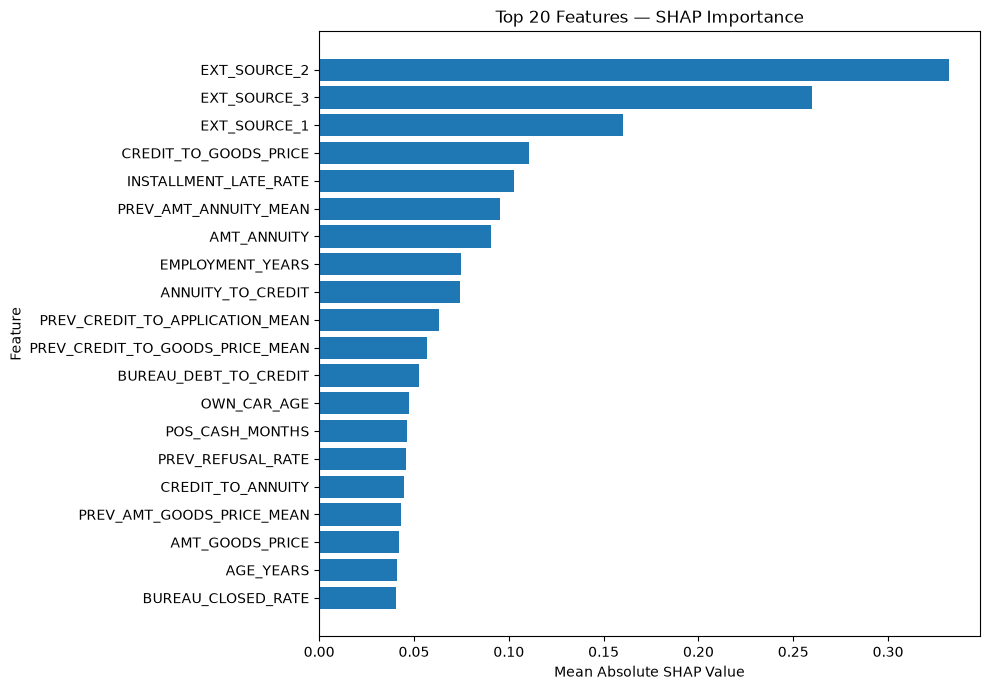


SHAP importance table and figure saved.


In [ ]:
# Phase 9 — SHAP Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Mean absolute SHAP importance
shap_importance = pd.DataFrame({
    "feature": numeric_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print("Top 20 features:")
print(shap_importance.head(20).to_string(index=False))

# Save importance table
shap_importance.to_csv(
    PROCESSED_DIR / "shap_feature_importance.csv",
    index=False
)

# Plot top 20
plt.figure(figsize=(10, 7))

top20 = shap_importance.head(20).sort_values("mean_abs_shap")

plt.barh(
    top20["feature"],
    top20["mean_abs_shap"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 20 Features — SHAP Importance")
plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "figures" / "shap_feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nSHAP importance table and figure saved.")

In [ ]:
# Phase 10.1 — Final Test Evaluation

test_idx = np.load(PROCESSED_DIR / "test_idx.npy")

X_test = train_fe.loc[test_idx, numeric_cols]
y_test = train_fe.loc[test_idx, "TARGET"]

X_test_imp = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imp)

test_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

test_roc_auc = roc_auc_score(y_test, test_prob)
test_pr_auc = average_precision_score(y_test, test_prob)

print("FINAL TEST PERFORMANCE")
print("-----------------------")
print("ROC-AUC:", test_roc_auc)
print("PR-AUC :", test_pr_auc)

print("\nValidation vs Test")
print("------------------")
print("Validation ROC-AUC:", xgb_roc_auc)
print("Test ROC-AUC      :", test_roc_auc)
print("Validation PR-AUC :", xgb_pr_auc)
print("Test PR-AUC       :", test_pr_auc)

del X_test, X_test_imp, X_test_scaled
gc.collect()

FINAL TEST PERFORMANCE
-----------------------
ROC-AUC: 0.7808558095809902
PR-AUC : 0.2743897606600805

Validation vs Test
------------------
Validation ROC-AUC: 0.7792551100327725
Test ROC-AUC      : 0.7808558095809902
Validation PR-AUC : 0.27232599818552
Test PR-AUC       : 0.2743897606600805


4701

Brier Score: 0.06635472178459167

Calibration by decile
Predicted: 0.0110 | Actual: 0.0091
Predicted: 0.0189 | Actual: 0.0165
Predicted: 0.0259 | Actual: 0.0225
Predicted: 0.0338 | Actual: 0.0336
Predicted: 0.0433 | Actual: 0.0423
Predicted: 0.0560 | Actual: 0.0523
Predicted: 0.0731 | Actual: 0.0735
Predicted: 0.0992 | Actual: 0.1058
Predicted: 0.1462 | Actual: 0.1637
Predicted: 0.2968 | Actual: 0.2881


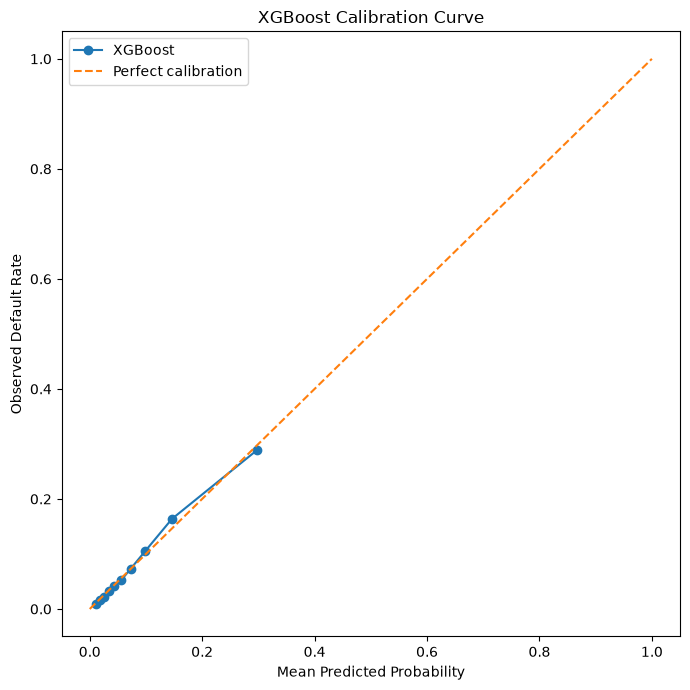


Calibration figure saved.


In [ ]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Brier score
brier = brier_score_loss(y_test, test_prob)

print("Brier Score:", brier)

# Calibration curve
prob_true, prob_pred = calibration_curve(
    y_test,
    test_prob,
    n_bins=10,
    strategy="quantile"
)

print("\nCalibration by decile")
for p, actual in zip(prob_pred, prob_true):
    print(f"Predicted: {p:.4f} | Actual: {actual:.4f}")

# Plot
plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("XGBoost Calibration Curve")
plt.legend()
plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "figures" / "xgboost_calibration_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nCalibration figure saved.")

In [ ]:
# Phase 10.3 — Segment Stability

from sklearn.metrics import roc_auc_score

test_data = train_fe.loc[test_idx].copy()
test_data["PREDICTED_RISK"] = test_prob

# Age segments
test_data["AGE_GROUP"] = pd.cut(
    test_data["AGE_YEARS"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=["<25", "25-35", "35-45", "45-55", "55+"]
)

# Income segments
test_data["INCOME_GROUP"] = pd.qcut(
    test_data["AMT_INCOME_TOTAL"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop"
)

def segment_metrics(df, group_col):
    results = []

    for group, data in df.groupby(group_col, observed=True):
        if data["TARGET"].nunique() < 2:
            continue

        results.append({
            "Segment": group,
            "Applicants": len(data),
            "Default_Rate": data["TARGET"].mean(),
            "ROC_AUC": roc_auc_score(
                data["TARGET"],
                data["PREDICTED_RISK"]
            )
        })

    return pd.DataFrame(results)

age_results = segment_metrics(test_data, "AGE_GROUP")
income_results = segment_metrics(test_data, "INCOME_GROUP")

print("AGE SEGMENTS")
print(age_results.to_string(index=False))

print("\nINCOME SEGMENTS")
print(income_results.to_string(index=False))

# Save results
age_results.to_csv(
    PROCESSED_DIR / "stability_age_segments.csv",
    index=False
)

income_results.to_csv(
    PROCESSED_DIR / "stability_income_segments.csv",
    index=False
)

print("\nSegment stability results saved.")

del test_data
gc.collect()

AGE SEGMENTS
Segment  Applicants  Default_Rate  ROC_AUC
    <25        1795      0.122006 0.734931
  25-35       10873      0.104939 0.773480
  35-45       12599      0.084134 0.783832
  45-55       10518      0.070736 0.784476
    55+       10342      0.054148 0.747554

INCOME SEGMENTS
Segment  Applicants  Default_Rate  ROC_AUC
     Q1       15150      0.082838 0.773704
     Q2        8150      0.081963 0.766045
     Q3       12123      0.086612 0.787009
     Q4       10704      0.070161 0.793747

Segment stability results saved.


2922

In [ ]:
# Phase 10.4 — Overfitting Check

train_prob = xgb_model.predict_proba(X_train_scaled)[:, 1]

train_roc_auc = roc_auc_score(y_train, train_prob)
train_pr_auc = average_precision_score(y_train, train_prob)

performance_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "ROC_AUC": [
        train_roc_auc,
        xgb_roc_auc,
        test_roc_auc
    ],
    "PR_AUC": [
        train_pr_auc,
        xgb_pr_auc,
        test_pr_auc
    ]
})

print(performance_summary.to_string(index=False))

performance_summary.to_csv(
    PROCESSED_DIR / "model_performance_summary.csv",
    index=False
)

print("\nPerformance summary saved.")

   Dataset  ROC_AUC   PR_AUC
     Train 0.840356 0.395029
Validation 0.779255 0.272326
      Test 0.780856 0.274390

Performance summary saved.


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Threshold selected ONLY from validation
selected_threshold = 0.21115996

test_pred = (
    test_prob >= selected_threshold
).astype(int)

precision_test = precision_score(y_test, test_pred)
recall_test = recall_score(y_test, test_pred)
f1_test = f1_score(y_test, test_pred)

cm_test = confusion_matrix(y_test, test_pred)

print("TEST PERFORMANCE AT VALIDATION-SELECTED THRESHOLD")
print("------------------------------------------------")
print("Threshold:", selected_threshold)
print("Precision:", precision_test)
print("Recall   :", recall_test)
print("F1-score :", f1_test)

print("\nConfusion Matrix")
print(cm_test)

# Save threshold result
threshold_result = pd.DataFrame({
    "Threshold": [selected_threshold],
    "Precision": [precision_test],
    "Recall": [recall_test],
    "F1": [f1_test]
})

threshold_result.to_csv(
    PROCESSED_DIR / "threshold_validation_test.csv",
    index=False
)

print("\nThreshold evaluation saved.")

TEST PERFORMANCE AT VALIDATION-SELECTED THRESHOLD
------------------------------------------------
Threshold: 0.21115996
Precision: 0.3148558758314856
Recall   : 0.3050483351235231
F1-score : 0.3098745226404801

Confusion Matrix
[[39931  2472]
 [ 2588  1136]]

Threshold evaluation saved.


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.21116, 0.25, 0.30, 0.40, 0.50]

threshold_rows = []

for threshold in thresholds:
    pred = (xgb_val_prob >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
        "Flagged_Rate": pred.mean()
    })

threshold_table = pd.DataFrame(threshold_rows)

print(threshold_table.to_string(index=False))

threshold_table.to_csv(
    PROCESSED_DIR / "threshold_sensitivity_validation.csv",
    index=False
)

print("\nThreshold sensitivity table saved.")

 Threshold  Precision   Recall       F1  Flagged_Rate
   0.10000   0.203689 0.619764 0.306609      0.245648
   0.15000   0.257965 0.447905 0.327380      0.140178
   0.20000   0.309712 0.326262 0.317772      0.085048
   0.21116   0.317587 0.299678 0.308372      0.076181
   0.25000   0.351243 0.235231 0.281763      0.054068
   0.30000   0.382517 0.165682 0.231216      0.034969
   0.40000   0.478261 0.088614 0.149524      0.014959
   0.50000   0.592593 0.042965 0.080120      0.005853

Threshold sensitivity table saved.


In [ ]:
# Final Model Risk Validation Summary

validation_summary = pd.DataFrame({
    "Metric": [
        "Test ROC-AUC",
        "Test PR-AUC",
        "Brier Score",
        "Validation ROC-AUC",
        "Validation PR-AUC",
        "Train ROC-AUC",
        "Train PR-AUC",
        "Selected Threshold",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Validation Target Recall",
        "Age Minimum ROC-AUC",
        "Age Maximum ROC-AUC",
        "Income Minimum ROC-AUC",
        "Income Maximum ROC-AUC"
    ],
    "Value": [
        test_roc_auc,
        test_pr_auc,
        brier,
        xgb_roc_auc,
        xgb_pr_auc,
        train_roc_auc,
        train_pr_auc,
        selected_threshold,
        precision_test,
        recall_test,
        f1_test,
        0.30,
        age_results["ROC_AUC"].min(),
        age_results["ROC_AUC"].max(),
        income_results["ROC_AUC"].min(),
        income_results["ROC_AUC"].max()
    ]
})

validation_summary.to_csv(
    PROCESSED_DIR / "final_model_validation_summary.csv",
    index=False
)

print(validation_summary.to_string(index=False))
print("\nFinal validation summary saved.")

                  Metric    Value
            Test ROC-AUC 0.780856
             Test PR-AUC 0.274390
             Brier Score 0.066355
      Validation ROC-AUC 0.779255
       Validation PR-AUC 0.272326
           Train ROC-AUC 0.840356
            Train PR-AUC 0.395029
      Selected Threshold 0.211160
          Test Precision 0.314856
             Test Recall 0.305048
                 Test F1 0.309875
Validation Target Recall 0.300000
     Age Minimum ROC-AUC 0.734931
     Age Maximum ROC-AUC 0.784476
  Income Minimum ROC-AUC 0.766045
  Income Maximum ROC-AUC 0.793747

Final validation summary saved.


In [ ]:
# Controlled XGBoost improvement

xgb_tuned = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5,
    reg_alpha=0.1,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    n_jobs=2,
    random_state=42
)

print("Training tuned XGBoost...")

xgb_tuned.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

# Validation
tuned_val_prob = xgb_tuned.predict_proba(
    X_val_scaled
)[:, 1]

tuned_roc_auc = roc_auc_score(
    y_val,
    tuned_val_prob
)

tuned_pr_auc = average_precision_score(
    y_val,
    tuned_val_prob
)

print("\nTuned XGBoost")
print("ROC-AUC:", tuned_roc_auc)
print("PR-AUC :", tuned_pr_auc)

# Compare
print("\nComparison")
print("-----------------------------")
print(f"Original ROC-AUC: {xgb_roc_auc:.6f}")
print(f"Tuned ROC-AUC   : {tuned_roc_auc:.6f}")
print()
print(f"Original PR-AUC : {xgb_pr_auc:.6f}")
print(f"Tuned PR-AUC    : {tuned_pr_auc:.6f}")

Training tuned XGBoost...

Tuned XGBoost
ROC-AUC: 0.7804942083901457
PR-AUC : 0.27423806405816886

Comparison
-----------------------------
Original ROC-AUC: 0.779255
Tuned ROC-AUC   : 0.780494

Original PR-AUC : 0.272326
Tuned PR-AUC    : 0.274238


In [ ]:
# Recreate test data for final tuned-model comparison

X_test = train_fe.loc[test_idx, numeric_cols]
y_test = train_fe.loc[test_idx, "TARGET"]

X_test_imp = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imp)

# Tuned model on untouched test set
tuned_test_prob = xgb_tuned.predict_proba(
    X_test_scaled
)[:, 1]

tuned_test_roc_auc = roc_auc_score(
    y_test,
    tuned_test_prob
)

tuned_test_pr_auc = average_precision_score(
    y_test,
    tuned_test_prob
)

print("TUNED XGBOOST — FINAL TEST")
print("--------------------------")
print("ROC-AUC:", tuned_test_roc_auc)
print("PR-AUC :", tuned_test_pr_auc)

print("\nOriginal vs Tuned")
print("--------------------------")
print(f"Original ROC-AUC: {test_roc_auc:.6f}")
print(f"Tuned ROC-AUC   : {tuned_test_roc_auc:.6f}")
print()
print(f"Original PR-AUC : {test_pr_auc:.6f}")
print(f"Tuned PR-AUC    : {tuned_test_pr_auc:.6f}")

TUNED XGBOOST — FINAL TEST
--------------------------
ROC-AUC: 0.7828670626353802
PR-AUC : 0.2769318684220138

Original vs Tuned
--------------------------
Original ROC-AUC: 0.780856
Tuned ROC-AUC   : 0.782867

Original PR-AUC : 0.274390
Tuned PR-AUC    : 0.276932


TUNED XGBOOST — CALIBRATION
---------------------------
Brier Score: 0.06618522852659225

Calibration by decile
Predicted: 0.0110 | Actual: 0.0091
Predicted: 0.0189 | Actual: 0.0169
Predicted: 0.0260 | Actual: 0.0219
Predicted: 0.0340 | Actual: 0.0351
Predicted: 0.0435 | Actual: 0.0395
Predicted: 0.0560 | Actual: 0.0531
Predicted: 0.0732 | Actual: 0.0689
Predicted: 0.0994 | Actual: 0.1041
Predicted: 0.1462 | Actual: 0.1663
Predicted: 0.2964 | Actual: 0.2924


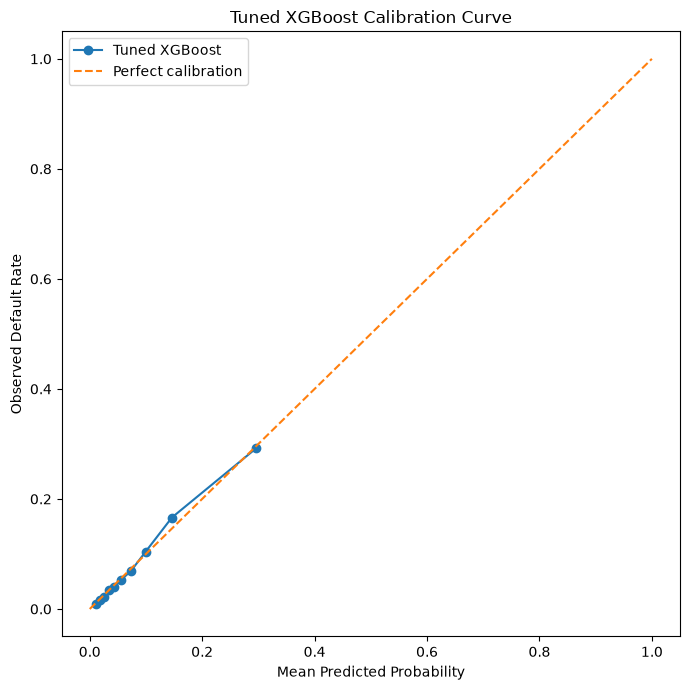


Calibration figure saved.


In [ ]:
# Phase 10.2 — Tuned XGBoost Calibration

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Brier score on untouched test set
tuned_brier = brier_score_loss(
    y_test,
    tuned_test_prob
)

print("TUNED XGBOOST — CALIBRATION")
print("---------------------------")
print("Brier Score:", tuned_brier)

# Calibration curve
tuned_prob_true, tuned_prob_pred = calibration_curve(
    y_test,
    tuned_test_prob,
    n_bins=10,
    strategy="quantile"
)

print("\nCalibration by decile")

for predicted, actual in zip(
    tuned_prob_pred,
    tuned_prob_true
):
    print(
        f"Predicted: {predicted:.4f} | "
        f"Actual: {actual:.4f}"
    )

# Plot
plt.figure(figsize=(7, 7))

plt.plot(
    tuned_prob_pred,
    tuned_prob_true,
    marker="o",
    label="Tuned XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Tuned XGBoost Calibration Curve")
plt.legend()
plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "figures" / "tuned_xgboost_calibration_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nCalibration figure saved.")

In [ ]:
# Tuned XGBoost — threshold selection using validation only

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_val,
    tuned_val_prob
)

target_recall = 0.30

idx = np.argmin(
    np.abs(recall[:-1] - target_recall)
)

tuned_threshold = thresholds[idx]

print("TUNED MODEL — VALIDATION THRESHOLD")
print("----------------------------------")
print("Selected threshold:", tuned_threshold)
print("Precision:", precision[idx])
print("Recall:", recall[idx])

TUNED MODEL — VALIDATION THRESHOLD
----------------------------------
Selected threshold: 0.21340685
Precision: 0.3258459743290548
Recall: 0.29994629430719655


In [ ]:
# Final tuned-model threshold evaluation on untouched test set

tuned_test_pred = (
    tuned_test_prob >= tuned_threshold
).astype(int)

tuned_precision_test = precision_score(
    y_test,
    tuned_test_pred
)

tuned_recall_test = recall_score(
    y_test,
    tuned_test_pred
)

tuned_f1_test = f1_score(
    y_test,
    tuned_test_pred
)

tuned_cm_test = confusion_matrix(
    y_test,
    tuned_test_pred
)

print("TUNED XGBOOST — FINAL THRESHOLD TEST")
print("-------------------------------------")
print("Threshold:", tuned_threshold)
print("Precision:", tuned_precision_test)
print("Recall   :", tuned_recall_test)
print("F1-score :", tuned_f1_test)

print("\nConfusion Matrix")
print(tuned_cm_test)

TUNED XGBOOST — FINAL THRESHOLD TEST
-------------------------------------
Threshold: 0.21340685
Precision: 0.31964892412231033
Recall   : 0.30316863587540277
F1-score : 0.3111907386990077

Confusion Matrix
[[40000  2403]
 [ 2595  1129]]


FINAL MODEL — TOP 20 SHAP FEATURES
                        feature  mean_abs_shap
                   EXT_SOURCE_2       0.330034
                   EXT_SOURCE_3       0.247531
                   EXT_SOURCE_1       0.161721
          CREDIT_TO_GOODS_PRICE       0.111748
                    AMT_ANNUITY       0.107504
          INSTALLMENT_LATE_RATE       0.106766
          PREV_AMT_ANNUITY_MEAN       0.104939
              ANNUITY_TO_CREDIT       0.076663
               EMPLOYMENT_YEARS       0.067906
PREV_CREDIT_TO_APPLICATION_MEAN       0.067546
          BUREAU_DEBT_TO_CREDIT       0.055230
                AMT_GOODS_PRICE       0.054415
PREV_CREDIT_TO_GOODS_PRICE_MEAN       0.054292
                    OWN_CAR_AGE       0.051544
                POS_CASH_MONTHS       0.050014
              PREV_REFUSAL_RATE       0.046504
      PREV_AMT_GOODS_PRICE_MEAN       0.046237
             BUREAU_CLOSED_RATE       0.045648
              CREDIT_TO_ANNUITY       0.044914
                      AGE

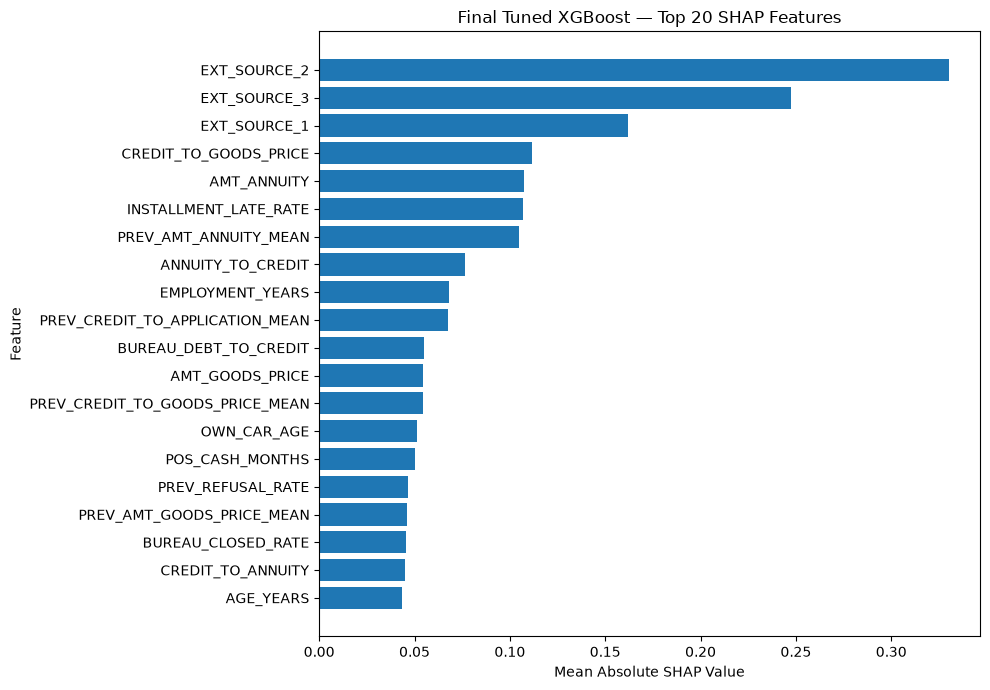


Final SHAP artifacts saved.


In [ ]:
# Final SHAP analysis — Tuned XGBoost

import shap
import pandas as pd
import matplotlib.pyplot as plt

sample_size = 5000

X_shap = X_val_scaled[:sample_size]

explainer_final = shap.TreeExplainer(xgb_tuned)
shap_values_final = explainer_final.shap_values(X_shap)

final_shap_importance = pd.DataFrame({
    "feature": numeric_cols,
    "mean_abs_shap": np.abs(shap_values_final).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print("FINAL MODEL — TOP 20 SHAP FEATURES")
print(
    final_shap_importance.head(20).to_string(index=False)
)

# Save table
final_shap_importance.to_csv(
    PROCESSED_DIR / "final_shap_feature_importance.csv",
    index=False
)

# Plot
plt.figure(figsize=(10, 7))

top20 = final_shap_importance.head(20).sort_values(
    "mean_abs_shap"
)

plt.barh(
    top20["feature"],
    top20["mean_abs_shap"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Final Tuned XGBoost — Top 20 SHAP Features")
plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "figures" / "final_shap_feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFinal SHAP artifacts saved.")

In [6]:
import joblib

joblib.dump(
    xgb_tuned,
    PROJECT_DIR / "models" / "final_tuned_xgboost.pkl"
)

print("Final tuned XGBoost saved.")

NameError: name 'xgb_tuned' is not defined

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import joblib
import gc
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score

PROJECT_DIR = Path("/content/drive/MyDrive/credit-risk-prediction")
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
MODELS_DIR = PROJECT_DIR / "models"

print("Drive connected.")
print("Project:", PROJECT_DIR)

Mounted at /content/drive
Drive connected.
Project: /content/drive/MyDrive/credit-risk-prediction


In [10]:
import pandas as pd

print("MODEL PERFORMANCE")
print(pd.read_csv(PROCESSED_DIR / "model_performance_summary.csv"))

print("\nFINAL VALIDATION")
print(pd.read_csv(PROCESSED_DIR / "final_model_validation_summary.csv"))

print("\nAGE STABILITY")
print(pd.read_csv(PROCESSED_DIR / "stability_age_segments.csv"))

print("\nINCOME STABILITY")
print(pd.read_csv(PROCESSED_DIR / "stability_income_segments.csv"))

MODEL PERFORMANCE
      Dataset   ROC_AUC    PR_AUC
0       Train  0.840356  0.395029
1  Validation  0.779255  0.272326
2        Test  0.780856  0.274390

FINAL VALIDATION
                      Metric     Value
0               Test ROC-AUC  0.780856
1                Test PR-AUC  0.274390
2                Brier Score  0.066355
3         Validation ROC-AUC  0.779255
4          Validation PR-AUC  0.272326
5              Train ROC-AUC  0.840356
6               Train PR-AUC  0.395029
7         Selected Threshold  0.211160
8             Test Precision  0.314856
9                Test Recall  0.305048
10                   Test F1  0.309875
11  Validation Target Recall  0.300000
12       Age Minimum ROC-AUC  0.734931
13       Age Maximum ROC-AUC  0.784476
14    Income Minimum ROC-AUC  0.766045
15    Income Maximum ROC-AUC  0.793747

AGE STABILITY
  Segment  Applicants  Default_Rate   ROC_AUC
0     <25        1795      0.122006  0.734931
1   25-35       10873      0.104939  0.773480
2   35-45   

In [11]:
from pathlib import Path

for f in sorted(MODELS_DIR.iterdir()):
    print(f.name)

baseline_imputer.pkl
baseline_logistic_regression.pkl
baseline_scaler.pkl
final_tuned_xgboost.pkl
xgboost_baseline.pkl


In [12]:
import joblib

final_model = joblib.load(
    MODELS_DIR / "final_tuned_xgboost.pkl"
)

print(final_model)
print("Number of features:", final_model.n_features_in_)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=2, num_parallel_tree=None, ...)
Number of features: 214


In [14]:
from pathlib import Path

RAW_DIR = PROJECT_DIR / "data" / "raw"

for f in sorted(RAW_DIR.iterdir()):
    print(f.name, f.stat().st_size / (1024**2), "MB")

HomeCredit_columns_description.csv 0.035651206970214844 MB
POS_CASH_balance.csv 374.5109157562256 MB
application_test.csv 25.336886405944824 MB
application_train.csv 158.4371280670166 MB
application_train.csv.zip 36.09421634674072 MB
bureau.csv 162.14057636260986 MB
bureau_balance.csv 358.19329166412354 MB
credit_card_balance.csv 404.91352558135986 MB
installments_payments.csv 689.6193971633911 MB
previous_application.csv 386.212628364563 MB
sample_submission.csv 0.5113620758056641 MB


In [15]:
import os

NOTEBOOK_DIR = PROJECT_DIR / "notebooks"

print("Notebook files:")
for f in NOTEBOOK_DIR.iterdir():
    print(f.name)

Notebook files:


In [16]:
final_model = joblib.load(
    MODELS_DIR / "final_tuned_xgboost.pkl"
)

print(final_model.get_booster().feature_names)

None


### Segment Stability

Model discrimination was evaluated across age and income segments
to assess whether performance remained reasonably consistent across
different parts of the population.

The analysis did not show a major performance collapse in the
evaluated segments. Segment-level ROC-AUC was reviewed alongside
segment default rates and applicant counts.

The segment analysis is intended as a stability check rather than
evidence of fairness or absence of bias. Formal fairness and
disparate-impact analysis would require additional investigation.

In [17]:
imputer = joblib.load(
    MODELS_DIR / "baseline_imputer.pkl"
)

print(type(imputer))
print("Features:", len(imputer.feature_names_in_))
print(imputer.feature_names_in_[:20])

<class 'sklearn.impute._base.SimpleImputer'>
Features: 214
['CNT_CHILDREN' 'AMT_INCOME_TOTAL' 'AMT_CREDIT' 'AMT_ANNUITY'
 'AMT_GOODS_PRICE' 'REGION_POPULATION_RELATIVE' 'DAYS_BIRTH'
 'DAYS_EMPLOYED' 'DAYS_REGISTRATION' 'DAYS_ID_PUBLISH' 'OWN_CAR_AGE'
 'FLAG_MOBIL' 'FLAG_EMP_PHONE' 'FLAG_WORK_PHONE' 'FLAG_CONT_MOBILE'
 'FLAG_PHONE' 'FLAG_EMAIL' 'CNT_FAM_MEMBERS' 'REGION_RATING_CLIENT'
 'REGION_RATING_CLIENT_W_CITY']


/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [18]:
feature_names = list(imputer.feature_names_in_)

print("Total features:", len(feature_names))

print("\nEngineered features:")
for f in feature_names:
    if f not in [
        "SK_ID_CURR",
        "TARGET"
    ]:
        pass

# Show features that aren't in the original 122 application columns
app = pd.read_csv(
    RAW_DIR / "application_train.csv",
    nrows=5
)

original_cols = set(app.columns)

engineered_cols = [
    f for f in feature_names
    if f not in original_cols
]

print("Engineered feature count:", len(engineered_cols))
print(engineered_cols)

Total features: 214

Engineered features:
Engineered feature count: 110
['AGE_YEARS', 'EMPLOYMENT_YEARS', 'INCOME_PER_FAMILY_MEMBER', 'CREDIT_TO_INCOME', 'ANNUITY_TO_INCOME', 'CREDIT_TO_ANNUITY', 'EMPLOYMENT_DURATION_MISSING', 'CREDIT_TO_GOODS_PRICE', 'ANNUITY_TO_CREDIT', 'CHILDREN_PER_FAMILY_MEMBER', 'ADULTS_IN_FAMILY', 'EMPLOYMENT_TO_AGE', 'PREV_APP_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT', 'PREV_CANCELED_COUNT', 'PREV_UNUSED_COUNT', 'PREV_APPROVAL_RATE', 'PREV_REFUSAL_RATE', 'PREV_CANCELED_RATE', 'PREV_UNUSED_RATE', 'PREV_AMT_APPLICATION_MEAN', 'PREV_AMT_CREDIT_MEAN', 'PREV_AMT_GOODS_PRICE_MEAN', 'PREV_AMT_ANNUITY_MEAN', 'PREV_CREDIT_TO_APPLICATION_MEAN', 'PREV_CREDIT_TO_GOODS_PRICE_MEAN', 'PREV_DAYS_DECISION_MEAN', 'PREV_DAYS_DECISION_MOST_RECENT', 'PREV_DAYS_DECISION_OLDEST', 'PREV_HISTORY_MISSING', 'BUREAU_CREDIT_COUNT', 'BUREAU_ACTIVE_COUNT', 'BUREAU_CLOSED_COUNT', 'BUREAU_SOLD_COUNT', 'BUREAU_BAD_DEBT_COUNT', 'BUREAU_ACTIVE_RATE', 'BUREAU_CLOSED_RATE', 'BUREAU_CREDIT

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path

# Temporarily make StringDtype accept the older pickle arguments
_original_stringdtype_init = pd.StringDtype.__init__

def _compatible_stringdtype_init(self, *args, **kwargs):
    try:
        _original_stringdtype_init(self, *args, **kwargs)
    except TypeError:
        # Fall back to the default string dtype
        storage = args[0] if args else kwargs.get("storage", "python")
        _original_stringdtype_init(self, storage=storage)

pd.StringDtype.__init__ = _compatible_stringdtype_init

try:
    train_fe = pd.read_pickle(PROCESSED_DIR / "train_fe_final.pkl")
    print("SUCCESS:", train_fe.shape)
except Exception as e:
    print("FAILED:", type(e).__name__, str(e))
finally:
    pd.StringDtype.__init__ = _original_stringdtype_init

SUCCESS: (307511, 232)


In [20]:
parquet_path = PROCESSED_DIR / "train_fe_final.parquet"

train_fe.to_parquet(
    parquet_path,
    index=False
)

print("Saved:", parquet_path)
print("Size:", parquet_path.stat().st_size / (1024**2), "MB")

Saved: /content/drive/MyDrive/credit-risk-prediction/data/processed/train_fe_final.parquet
Size: 69.48039436340332 MB


In [21]:
test_load = pd.read_parquet(parquet_path)

print("Loaded successfully:", test_load.shape)

del test_load

Loaded successfully: (307511, 232)


In [22]:
# Load train/validation/test indices
train_idx = np.load(PROCESSED_DIR / "train_idx.npy")
val_idx = np.load(PROCESSED_DIR / "val_idx.npy")
test_idx = np.load(PROCESSED_DIR / "test_idx.npy")

# Load final tuned model
final_model = joblib.load(
    MODELS_DIR / "final_tuned_xgboost.pkl"
)

# Identify the 214 model features
feature_names = list(imputer.feature_names_in_)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))
print("Model features:", len(feature_names))

Train: 215257
Validation: 46127
Test: 46127
Model features: 214


In [23]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# Load final dataset from the compatible Parquet file
train_fe = pd.read_parquet(
    PROCESSED_DIR / "train_fe_final.parquet"
)

# Prepare test data in the exact feature order
X_test = train_fe.loc[test_idx, feature_names]
y_test = train_fe.loc[test_idx, "TARGET"]

# Apply the saved imputer and scaler
X_test_imp = imputer.transform(X_test)

scaler = joblib.load(
    MODELS_DIR / "baseline_scaler.pkl"
)

X_test_scaled = scaler.transform(X_test_imp)

# Final tuned model predictions
tuned_test_prob = final_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, tuned_test_prob))
print("Test PR-AUC:", average_precision_score(y_test, tuned_test_prob))
print("Brier Score:", brier_score_loss(y_test, tuned_test_prob))

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Test ROC-AUC: 0.7828670626353802
Test PR-AUC: 0.2769318684220138
Brier Score: 0.06618523418942426


In [24]:
# Validation data
X_val = train_fe.loc[val_idx, feature_names]
y_val = train_fe.loc[val_idx, "TARGET"]

# Transform using saved preprocessing
X_val_imp = imputer.transform(X_val)
X_val_scaled = scaler.transform(X_val_imp)

# Final tuned XGBoost predictions
tuned_val_prob = final_model.predict_proba(
    X_val_scaled
)[:, 1]

print("Validation predictions:", len(tuned_val_prob))
print("Test predictions:", len(tuned_test_prob))

Validation predictions: 46127
Test predictions: 46127


In [25]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Training predictions
X_train = train_fe.loc[train_idx, feature_names]
y_train = train_fe.loc[train_idx, "TARGET"]

X_train_imp = imputer.transform(X_train)
X_train_scaled = scaler.transform(X_train_imp)

tuned_train_prob = final_model.predict_proba(
    X_train_scaled
)[:, 1]

# Metrics
results = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "ROC_AUC": [
        roc_auc_score(y_train, tuned_train_prob),
        roc_auc_score(y_val, tuned_val_prob),
        roc_auc_score(y_test, tuned_test_prob)
    ],
    "PR_AUC": [
        average_precision_score(y_train, tuned_train_prob),
        average_precision_score(y_val, tuned_val_prob),
        average_precision_score(y_test, tuned_test_prob)
    ]
})

print(results.to_string(index=False))

results.to_csv(
    PROCESSED_DIR / "final_model_performance_summary.csv",
    index=False
)

   Dataset  ROC_AUC   PR_AUC
     Train 0.822067 0.351700
Validation 0.780494 0.274238
      Test 0.782867 0.276932


In [26]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = [0.10, 0.15, 0.20, 0.2134, 0.25, 0.30, 0.40, 0.50]

threshold_results = []

for threshold in thresholds:
    pred = (tuned_val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "Flagged_Rate": pred.mean()
    })

threshold_results = pd.DataFrame(threshold_results)

print(threshold_results.to_string(index=False))

threshold_results.to_csv(
    PROCESSED_DIR / "final_threshold_sensitivity_validation.csv",
    index=False
)

# Final selected threshold on validation
selected_threshold = 0.21340685

val_pred = (tuned_val_prob >= selected_threshold).astype(int)
test_pred = (tuned_test_prob >= selected_threshold).astype(int)

print("\nFINAL VALIDATION THRESHOLD")
print("Threshold:", selected_threshold)
print("Precision:", precision_score(y_val, val_pred))
print("Recall:", recall_score(y_val, val_pred))
print("F1:", f1_score(y_val, val_pred))

print("\nFINAL TEST CONFUSION MATRIX")
print(confusion_matrix(y_test, test_pred))

 Threshold  Precision   Recall       F1  Flagged_Rate
    0.1000   0.203425 0.625134 0.306962      0.248098
    0.1500   0.259960 0.453813 0.330562      0.140937
    0.2000   0.310301 0.324382 0.317185      0.084397
    0.2134   0.325846 0.299946 0.312360      0.074317
    0.2500   0.362319 0.241676 0.289948      0.053851
    0.3000   0.390921 0.166488 0.233522      0.034383
    0.4000   0.479827 0.089420 0.150747      0.015045
    0.5000   0.595588 0.043502 0.081081      0.005897

FINAL VALIDATION THRESHOLD
Threshold: 0.21340685
Precision: 0.3258459743290548
Recall: 0.29994629430719655
F1: 0.3123601789709172

FINAL TEST CONFUSION MATRIX
[[40000  2403]
 [ 2595  1129]]


In [27]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Create calibration deciles on the untouched test set
calibration_df = pd.DataFrame({
    "TARGET": y_test.values,
    "PRED_PROB": tuned_test_prob
})

calibration_df["DECILE"] = pd.qcut(
    calibration_df["PRED_PROB"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

calibration_results = (
    calibration_df
    .groupby("DECILE")
    .agg(
        Mean_Predicted=("PRED_PROB", "mean"),
        Actual_Default_Rate=("TARGET", "mean"),
        Applicants=("TARGET", "size")
    )
    .reset_index()
)

print(calibration_results.to_string(index=False))

print(
    "\nFinal tuned Brier Score:",
    brier_score_loss(y_test, tuned_test_prob)
)

calibration_results.to_csv(
    PROCESSED_DIR / "final_calibration_deciles.csv",
    index=False
)

 DECILE  Mean_Predicted  Actual_Default_Rate  Applicants
      1        0.010998             0.009105        4613
      2        0.018924             0.016909        4613
      3        0.025984             0.021899        4612
      4        0.033974             0.035118        4613
      5        0.043502             0.039454        4613
      6        0.056008             0.053122        4612
      7        0.073211             0.068936        4613
      8        0.099356             0.104076        4612
      9        0.146183             0.166269        4613
     10        0.296416             0.292434        4613

Final tuned Brier Score: 0.06618523418942426


In [28]:
# Test-set segment stability for final tuned model

stability = train_fe.loc[
    test_idx,
    ["AGE_YEARS", "AMT_INCOME_TOTAL", "TARGET"]
].copy()

stability["PRED_PROB"] = tuned_test_prob

# -------------------------
# AGE SEGMENTS
# -------------------------

stability["AGE_SEGMENT"] = pd.cut(
    stability["AGE_YEARS"],
    bins=[0, 25, 35, 45, 55, np.inf],
    labels=["<25", "25-35", "35-45", "45-55", "55+"],
    right=False
)

age_results = []

for segment, group in stability.groupby(
    "AGE_SEGMENT",
    observed=True
):
    age_results.append({
        "Segment": str(segment),
        "Applicants": len(group),
        "Default_Rate": group["TARGET"].mean(),
        "ROC_AUC": roc_auc_score(
            group["TARGET"],
            group["PRED_PROB"]
        )
    })

age_results = pd.DataFrame(age_results)

print("TUNED MODEL — AGE STABILITY")
print(age_results.to_string(index=False))

age_results.to_csv(
    PROCESSED_DIR / "final_stability_age_segments.csv",
    index=False
)

# -------------------------
# INCOME SEGMENTS
# -------------------------

stability["INCOME_SEGMENT"] = pd.qcut(
    stability["AMT_INCOME_TOTAL"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop"
)

income_results = []

for segment, group in stability.groupby(
    "INCOME_SEGMENT",
    observed=True
):
    income_results.append({
        "Segment": str(segment),
        "Applicants": len(group),
        "Default_Rate": group["TARGET"].mean(),
        "ROC_AUC": roc_auc_score(
            group["TARGET"],
            group["PRED_PROB"]
        )
    })

income_results = pd.DataFrame(income_results)

print("\nTUNED MODEL — INCOME STABILITY")
print(income_results.to_string(index=False))

income_results.to_csv(
    PROCESSED_DIR / "final_stability_income_segments.csv",
    index=False
)

TUNED MODEL — AGE STABILITY
Segment  Applicants  Default_Rate  ROC_AUC
    <25        1795      0.122006 0.737915
  25-35       10873      0.104939 0.774677
  35-45       12599      0.084134 0.786837
  45-55       10518      0.070736 0.786311
    55+       10342      0.054148 0.750020

TUNED MODEL — INCOME STABILITY
Segment  Applicants  Default_Rate  ROC_AUC
     Q1       15150      0.082838 0.776542
     Q2        8150      0.081963 0.768890
     Q3       12123      0.086612 0.788599
     Q4       10704      0.070161 0.794392


In [29]:
final_validation_summary = pd.DataFrame({
    "Metric": [
        "Test ROC-AUC",
        "Test PR-AUC",
        "Brier Score",
        "Validation ROC-AUC",
        "Validation PR-AUC",
        "Train ROC-AUC",
        "Train PR-AUC",
        "Selected Threshold",
        "Validation Precision",
        "Validation Recall",
        "Validation F1",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Validation Target Recall",
        "Age Minimum ROC-AUC",
        "Age Maximum ROC-AUC",
        "Income Minimum ROC-AUC",
        "Income Maximum ROC-AUC"
    ],
    "Value": [
        roc_auc_score(y_test, tuned_test_prob),
        average_precision_score(y_test, tuned_test_prob),
        brier_score_loss(y_test, tuned_test_prob),
        roc_auc_score(y_val, tuned_val_prob),
        average_precision_score(y_val, tuned_val_prob),
        roc_auc_score(y_train, tuned_train_prob),
        average_precision_score(y_train, tuned_train_prob),
        selected_threshold,
        precision_score(y_val, val_pred),
        recall_score(y_val, val_pred),
        f1_score(y_val, val_pred),
        precision_score(y_test, test_pred),
        recall_score(y_test, test_pred),
        f1_score(y_test, test_pred),
        0.30,
        age_results["ROC_AUC"].min(),
        age_results["ROC_AUC"].max(),
        income_results["ROC_AUC"].min(),
        income_results["ROC_AUC"].max()
    ]
})

print(final_validation_summary.to_string(index=False))

final_validation_summary.to_csv(
    PROCESSED_DIR / "final_model_validation_summary.csv",
    index=False
)

print("\nFINAL VALIDATION SUMMARY SAVED.")

                  Metric    Value
            Test ROC-AUC 0.782867
             Test PR-AUC 0.276932
             Brier Score 0.066185
      Validation ROC-AUC 0.780494
       Validation PR-AUC 0.274238
           Train ROC-AUC 0.822067
            Train PR-AUC 0.351700
      Selected Threshold 0.213407
    Validation Precision 0.325846
       Validation Recall 0.299946
           Validation F1 0.312360
          Test Precision 0.319649
             Test Recall 0.303169
                 Test F1 0.311191
Validation Target Recall 0.300000
     Age Minimum ROC-AUC 0.737915
     Age Maximum ROC-AUC 0.786837
  Income Minimum ROC-AUC 0.768890
  Income Maximum ROC-AUC 0.794392

FINAL VALIDATION SUMMARY SAVED.


In [30]:
print("X_train:", X_train_scaled.shape)
print("X_val:", X_val_scaled.shape)
print("X_test:", X_test_scaled.shape)

X_train: (215257, 214)
X_val: (46127, 214)
X_test: (46127, 214)


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import joblib

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=2
)

print("Training Random Forest...")

rf_model.fit(X_train_scaled, y_train)

rf_val_prob = rf_model.predict_proba(X_val_scaled)[:, 1]
rf_test_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\nRandom Forest")
print("Validation ROC-AUC:", roc_auc_score(y_val, rf_val_prob))
print("Validation PR-AUC:", average_precision_score(y_val, rf_val_prob))
print("Test ROC-AUC:", roc_auc_score(y_test, rf_test_prob))
print("Test PR-AUC:", average_precision_score(y_test, rf_test_prob))

joblib.dump(
    rf_model,
    MODELS_DIR / "random_forest_challenger.pkl"
)

Training Random Forest...

Random Forest
Validation ROC-AUC: 0.7511672752416819
Validation PR-AUC: 0.2326751219105709
Test ROC-AUC: 0.7490478679677148
Test PR-AUC: 0.2243520441186077


['/content/drive/MyDrive/credit-risk-prediction/models/random_forest_challenger.pkl']

NameError: name 'FIGURES_DIR' is not defined

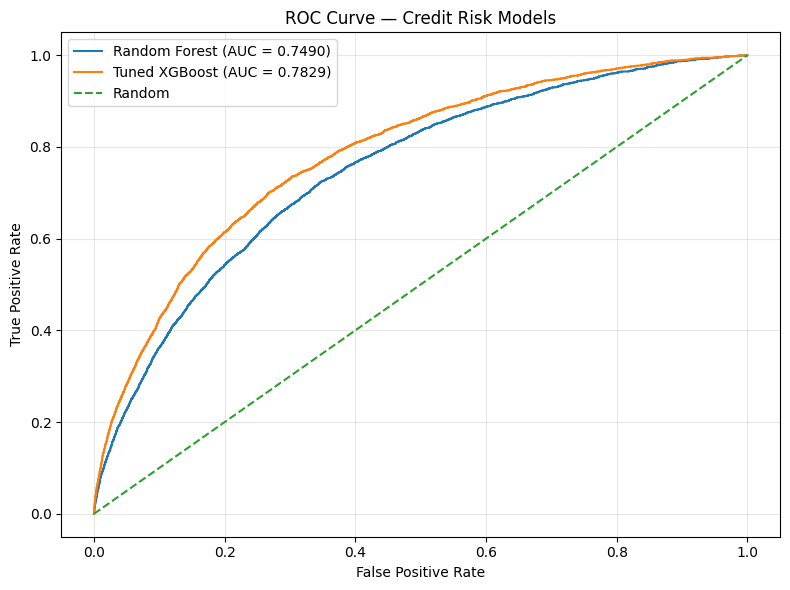

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilities
lr_val_prob = None

# ROC curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_test_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, tuned_test_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf, tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_test_prob):.4f})"
)

plt.plot(
    fpr_xgb, tpr_xgb,
    label=f"Tuned XGBoost (AUC = {roc_auc_score(y_test, tuned_test_prob):.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Credit Risk Models")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "roc_curve_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
from pathlib import Path

FIGURES_DIR = Path("/content/drive/MyDrive/credit-risk-prediction/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    FIGURES_DIR / "roc_curve_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

print("ROC curve saved successfully.")

ROC curve saved successfully.


<Figure size 640x480 with 0 Axes>

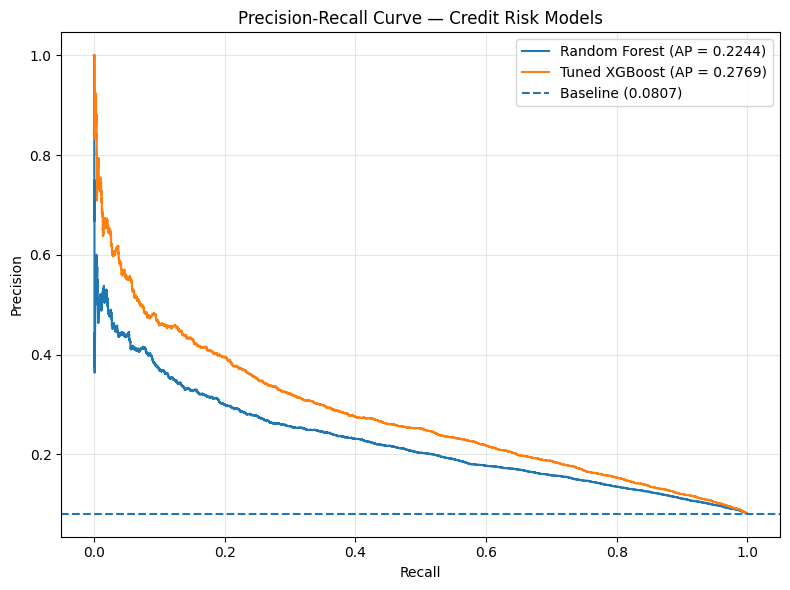

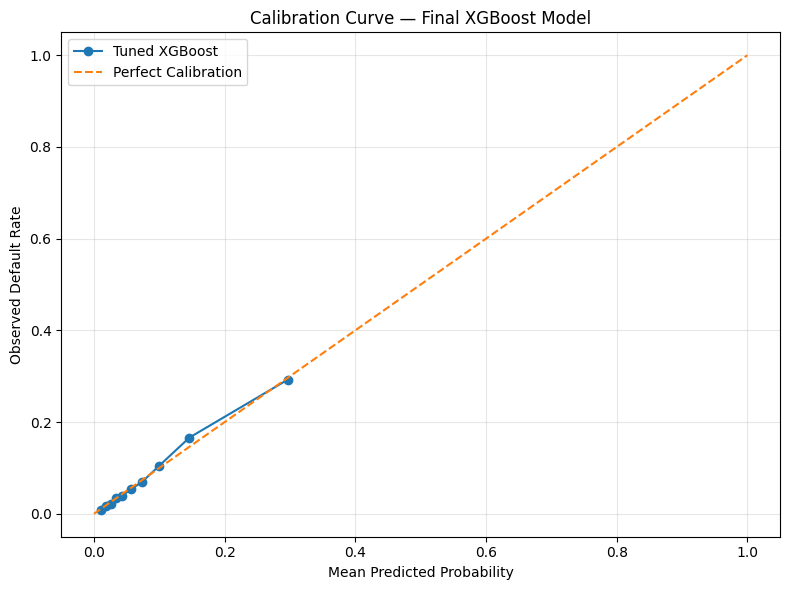

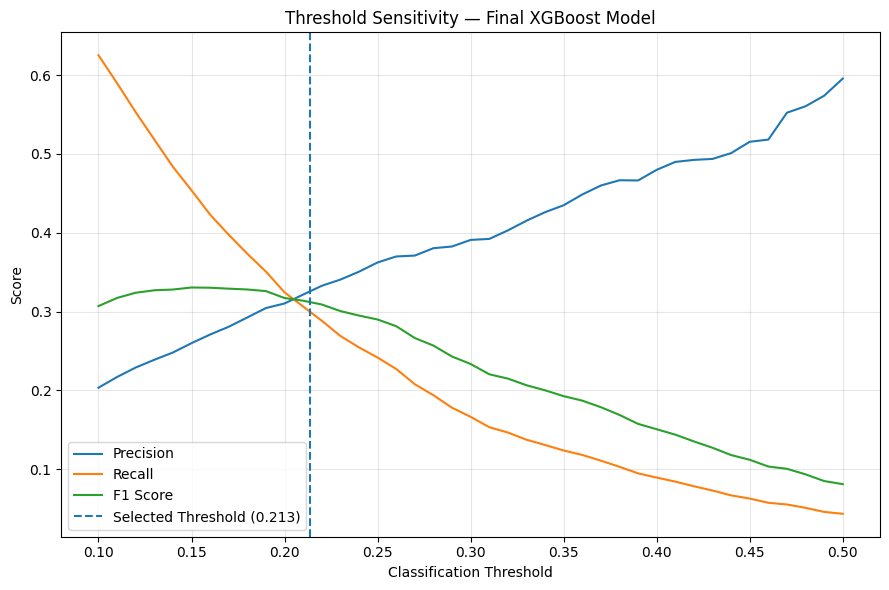

KeyError: 'AGE_SEGMENT'

<Figure size 800x600 with 0 Axes>

In [36]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

# --------------------------------------------------
# Setup
# --------------------------------------------------
FIGURES_DIR = Path("/content/drive/MyDrive/credit-risk-prediction/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# 1. Precision-Recall Curve
# --------------------------------------------------
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_test_prob)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, tuned_test_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (AP = {average_precision_score(y_test, rf_test_prob):.4f})"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"Tuned XGBoost (AP = {average_precision_score(y_test, tuned_test_prob):.4f})"
)

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Baseline ({y_test.mean():.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Credit Risk Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "precision_recall_curve_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# 2. Final Model Calibration Curve
# --------------------------------------------------
prob_true, prob_pred = calibration_curve(
    y_test,
    tuned_test_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Tuned XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve — Final XGBoost Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# 3. Threshold Sensitivity
# --------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.51, 0.01)

precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:

    preds = (tuned_val_prob >= threshold).astype(int)

    precisions.append(
        precision_score(y_val, preds, zero_division=0)
    )

    recalls.append(
        recall_score(y_val, preds, zero_division=0)
    )

    f1_scores.append(
        f1_score(y_val, preds, zero_division=0)
    )

plt.figure(figsize=(9, 6))

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1_scores, label="F1 Score")

plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected Threshold ({selected_threshold:.3f})"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Sensitivity — Final XGBoost Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "threshold_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# 4. Age Segment Stability
# --------------------------------------------------
age_path = Path(
    "/content/drive/MyDrive/credit-risk-prediction/data/processed/"
    "final_stability_age_segments.csv"
)

age_df = __import__("pandas").read_csv(age_path)

plt.figure(figsize=(8, 6))

plt.bar(
    age_df["AGE_SEGMENT"],
    age_df["ROC_AUC"]
)

plt.axhline(
    roc_auc_score(y_test, tuned_test_prob),
    linestyle="--",
    label="Overall Test AUC"
)

plt.xlabel("Age Segment")
plt.ylabel("ROC-AUC")
plt.title("Model Stability Across Age Segments")
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "stability_age_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# 5. Income Segment Stability
# --------------------------------------------------
income_path = Path(
    "/content/drive/MyDrive/credit-risk-prediction/data/processed/"
    "final_stability_income_segments.csv"
)

income_df = __import__("pandas").read_csv(income_path)

plt.figure(figsize=(8, 6))

plt.bar(
    income_df["INCOME_SEGMENT"],
    income_df["ROC_AUC"]
)

plt.axhline(
    roc_auc_score(y_test, tuned_test_prob),
    linestyle="--",
    label="Overall Test AUC"
)

plt.xlabel("Income Segment")
plt.ylabel("ROC-AUC")
plt.title("Model Stability Across Income Segments")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "stability_income_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Final summary
# --------------------------------------------------
print("\n========== FINAL VISUALIZATION SUMMARY ==========")

print(
    f"Test ROC-AUC : "
    f"{roc_auc_score(y_test, tuned_test_prob):.4f}"
)

print(
    f"Test PR-AUC  : "
    f"{average_precision_score(y_test, tuned_test_prob):.4f}"
)

print(
    f"Brier Score  : "
    f"{brier_score_loss(y_test, tuned_test_prob):.4f}"
)

print(
    f"Selected Threshold : "
    f"{selected_threshold:.4f}"
)

print("\nSaved figures:")
for file in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", file.name)

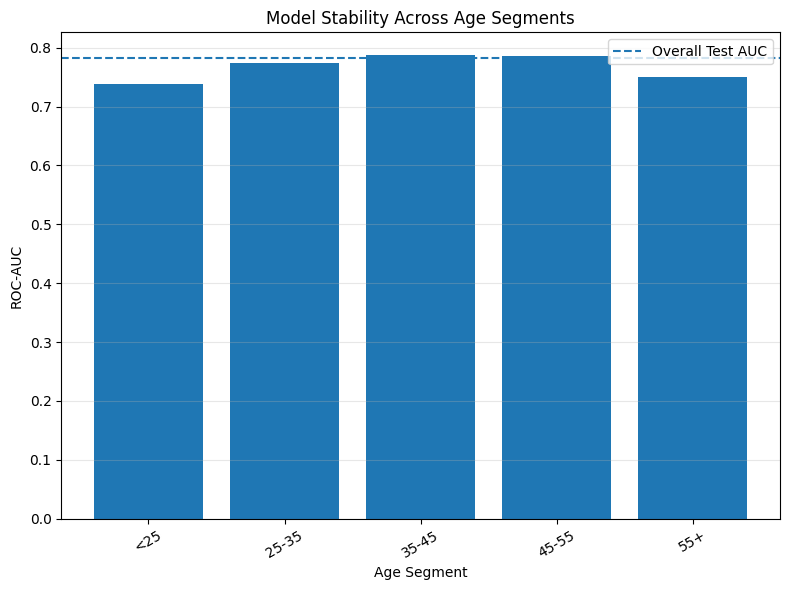

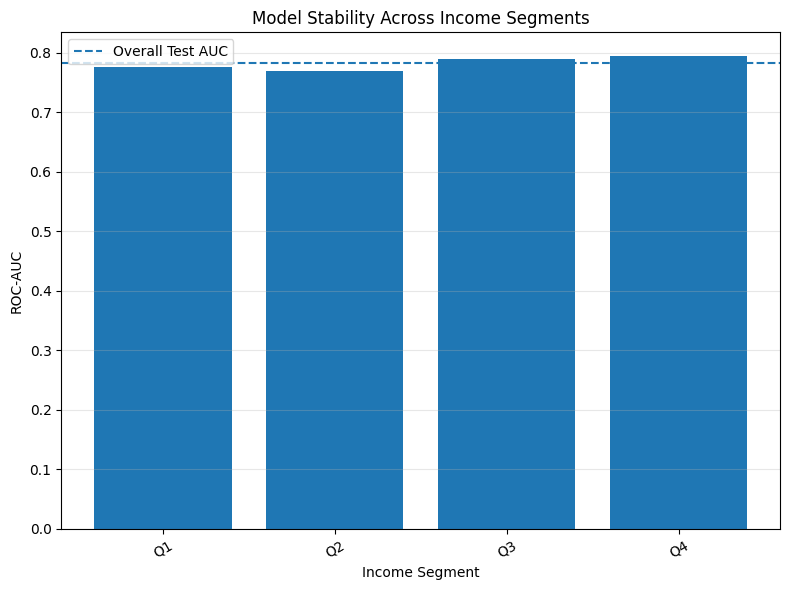

✅ Age stability graph saved.
✅ Income stability graph saved.

Final figures folder:
 - final_calibration_curve.png
 - final_shap_feature_importance.png
 - precision_recall_curve_model_comparison.png
 - roc_curve_model_comparison.png
 - shap_feature_importance.png
 - stability_age_segments.png
 - stability_income_segments.png
 - threshold_sensitivity.png
 - tuned_xgboost_calibration_curve.png
 - xgboost_calibration_curve.png


In [38]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = Path(
    "/content/drive/MyDrive/credit-risk-prediction/data/processed"
)

FIGURES_DIR = Path(
    "/content/drive/MyDrive/credit-risk-prediction/figures"
)

# -----------------------------
# Age stability
# -----------------------------
age_df = pd.read_csv(
    PROCESSED_DIR / "final_stability_age_segments.csv"
)

plt.figure(figsize=(8, 6))

plt.bar(
    age_df["Segment"],
    age_df["ROC_AUC"]
)

plt.axhline(
    roc_auc_score(y_test, tuned_test_prob),
    linestyle="--",
    label="Overall Test AUC"
)

plt.xlabel("Age Segment")
plt.ylabel("ROC-AUC")
plt.title("Model Stability Across Age Segments")
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "stability_age_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# Income stability
# -----------------------------
income_df = pd.read_csv(
    PROCESSED_DIR / "final_stability_income_segments.csv"
)

plt.figure(figsize=(8, 6))

plt.bar(
    income_df["Segment"],
    income_df["ROC_AUC"]
)

plt.axhline(
    roc_auc_score(y_test, tuned_test_prob),
    linestyle="--",
    label="Overall Test AUC"
)

plt.xlabel("Income Segment")
plt.ylabel("ROC-AUC")
plt.title("Model Stability Across Income Segments")
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "stability_income_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Age stability graph saved.")
print("✅ Income stability graph saved.")
print("\nFinal figures folder:")
for f in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", f.name)

In [39]:
from pathlib import Path
import pandas as pd
import joblib

PROJECT_DIR = Path("/content/drive/MyDrive/credit-risk-prediction")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
MODELS_DIR = PROJECT_DIR / "models"
FIGURES_DIR = PROJECT_DIR / "figures"

print("=" * 60)
print("FINAL PROJECT AUDIT")
print("=" * 60)

# -----------------------------
# Final model
# -----------------------------
final_model_path = MODELS_DIR / "final_tuned_xgboost.pkl"

print("\n[1] Final model")
print("Exists:", final_model_path.exists())

if final_model_path.exists():
    model = joblib.load(final_model_path)
    print("Model:", type(model).__name__)

# -----------------------------
# Final validation summary
# -----------------------------
print("\n[2] Final validation summary")

summary_path = PROCESSED_DIR / "final_model_validation_summary.csv"

summary = pd.read_csv(summary_path)

print(summary.to_string(index=False))

# -----------------------------
# Random Forest
# -----------------------------
print("\n[3] Random Forest challenger")

rf_path = MODELS_DIR / "random_forest_challenger.pkl"

print("Saved:", rf_path.exists())

print(f"Validation ROC-AUC: {roc_auc_score(y_val, rf_val_prob):.6f}")
print(f"Validation PR-AUC : {average_precision_score(y_val, rf_val_prob):.6f}")
print(f"Test ROC-AUC      : {roc_auc_score(y_test, rf_test_prob):.6f}")
print(f"Test PR-AUC       : {average_precision_score(y_test, rf_test_prob):.6f}")

# -----------------------------
# Key final metrics
# -----------------------------
print("\n[4] Final test metrics")

print(f"ROC-AUC : {roc_auc_score(y_test, tuned_test_prob):.6f}")
print(f"PR-AUC  : {average_precision_score(y_test, tuned_test_prob):.6f}")
print(f"Brier   : {brier_score_loss(y_test, tuned_test_prob):.6f}")

test_pred_final = (tuned_test_prob >= selected_threshold).astype(int)

print(f"Precision: {precision_score(y_test, test_pred_final):.6f}")
print(f"Recall   : {recall_score(y_test, test_pred_final):.6f}")
print(f"F1       : {f1_score(y_test, test_pred_final):.6f}")

# -----------------------------
# Processed files
# -----------------------------
print("\n[5] Processed artifacts")

for f in sorted(PROCESSED_DIR.iterdir()):
    print(" -", f.name)

# -----------------------------
# Model files
# -----------------------------
print("\n[6] Model artifacts")

for f in sorted(MODELS_DIR.iterdir()):
    print(" -", f.name)

# -----------------------------
# Figures
# -----------------------------
print("\n[7] Figures")

for f in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", f.name)

print("\n" + "=" * 60)
print("AUDIT COMPLETE")
print("=" * 60)

FINAL PROJECT AUDIT

[1] Final model
Exists: True
Model: XGBClassifier

[2] Final validation summary
                  Metric    Value
            Test ROC-AUC 0.782867
             Test PR-AUC 0.276932
             Brier Score 0.066185
      Validation ROC-AUC 0.780494
       Validation PR-AUC 0.274238
           Train ROC-AUC 0.822067
            Train PR-AUC 0.351700
      Selected Threshold 0.213407
    Validation Precision 0.325846
       Validation Recall 0.299946
           Validation F1 0.312360
          Test Precision 0.319649
             Test Recall 0.303169
                 Test F1 0.311191
Validation Target Recall 0.300000
     Age Minimum ROC-AUC 0.737915
     Age Maximum ROC-AUC 0.786837
  Income Minimum ROC-AUC 0.768890
  Income Maximum ROC-AUC 0.794392

[3] Random Forest challenger
Saved: True
Validation ROC-AUC: 0.751167
Validation PR-AUC : 0.232675
Test ROC-AUC      : 0.749048
Test PR-AUC       : 0.224352

[4] Final test metrics
ROC-AUC : 0.782867
PR-AUC  : 0.276932

In [40]:
from pathlib import Path

FIGURES_DIR = Path(
    "/content/drive/MyDrive/credit-risk-prediction/figures"
)

for name in [
    "threshold_sensitivity.png",
    "final_calibration_curve.png",
    "precision_recall_curve_model_comparison.png"
]:
    path = FIGURES_DIR / name
    print(f"{name}: {'✅ EXISTS' if path.exists() else '❌ NOT FOUND'}")

threshold_sensitivity.png: ✅ EXISTS
final_calibration_curve.png: ✅ EXISTS
precision_recall_curve_model_comparison.png: ✅ EXISTS
